# Análisis exploratorio de datos

Este cuaderno caracteriza los datos del Healthy Brain Network publicados en la competencia de Kaggle del Child Mind Institute. Corresponde al objetivo específico 1 del proyecto: describir la disponibilidad, la calidad y la distribución del índice de severidad del deterioro (SII), de los indicadores físicos y demográficos y de las variables complementarias, y definir con base en ello el tratamiento de los datos faltantes y del desbalance entre niveles de severidad.

El análisis sigue el orden de las decisiones que alimenta: primero la integridad y la estructura de los datos, luego la variable objetivo y la población de análisis, después la calidad de los predictores (faltantes, valores inválidos, distribuciones y redundancia) y, por último, la relación descriptiva de cada grupo de variables con el SII.

Dos criterios se aplican en todo el cuaderno. Como los datos corresponden a menores de edad, todas las salidas son agregadas: conteos, porcentajes, estadísticos y gráficas. Además, la relación entre los predictores y el SII se analiza solo de forma descriptiva; la selección de variables que dependa de la variable objetivo ocurre dentro de la validación cruzada, en el cuaderno de modelado.


In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, leaves_list, linkage
from scipy.spatial.distance import squareform
from scipy.stats import chi2_contingency, false_discovery_control, kendalltau
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mutual_info_score

from piu_severity.config import FIGURES_DIR, INTERIM_DATA_DIR, RANDOM_SEED
from piu_severity.data.clean import (
    BLOOD_PRESSURE_COLUMNS,
    POSITIVE_COLUMNS,
    PROTOCOL_MAXIMA,
    VALUE_RANGES,
    cap_protocol_maxima,
    clean_values,
    invalid_value_mask,
)
from piu_severity.data.load import (
    list_actigraphy_ids,
    load_actigraphy,
    load_data_dictionary,
    load_test,
    load_train,
)
from piu_severity.features.actigraphy import (
    ACTIGRAPHY_COLUMNS,
    MIN_WEAR_HOURS_PER_DAY,
    summarize_actigraphy,
)
from piu_severity.features.groups import (
    column_group,
    feature_set_columns,
    is_excluded,
    is_instrument_season,
)
from piu_severity.visualization.figures import save_figure

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(RANDOM_SEED)

FIGURAS_EDA = FIGURES_DIR / "01_eda"

In [3]:
train = load_train()
test = load_test()
data_dictionary = load_data_dictionary()

## 1. Carga y verificación de integridad

Antes de caracterizar las variables se verifica que los archivos cargados correspondan a lo esperado. La verificación cubre cuatro aspectos: las dimensiones de los conjuntos de entrenamiento y prueba y del diccionario de datos; la unicidad del identificador de participante; la relación entre las columnas y los registros de ambos conjuntos; y la correspondencia entre las columnas de entrenamiento y los campos documentados en el diccionario.

Esta verificación sustenta dos decisiones: qué columnas quedan excluidas como predictores por definir la variable objetivo, y qué papel cumple el archivo de prueba en el análisis.


In [4]:
dimensiones = pd.DataFrame(
    {
        "filas": [train.shape[0], test.shape[0], data_dictionary.shape[0]],
        "columnas": [train.shape[1], test.shape[1], data_dictionary.shape[1]],
    },
    index=["train", "test", "diccionario"],
)
dimensiones

,filas,columnas
train,3960,82
test,20,59
diccionario,81,6


In [5]:
data_dictionary.head()

,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN


In [6]:
pd.Series(
    {
        "id duplicados en train": train["id"].duplicated().sum(),
        "id duplicados en test": test["id"].duplicated().sum(),
        "id faltantes en train": train["id"].isna().sum(),
        "id faltantes en test": test["id"].isna().sum(),
    },
    name="conteo",
)

id duplicados en train    0
id duplicados en test     0
id faltantes en train     0
id faltantes en test      0
Name: conteo, dtype: int64

In [7]:
ids_compartidos = test["id"].isin(train["id"])
columnas_comunes = test.columns.drop("id")
filas_test = test.loc[ids_compartidos].set_index("id")[columnas_comunes]
filas_train = train.set_index("id").loc[filas_test.index, columnas_comunes]
coinciden = filas_train.eq(filas_test) | (filas_train.isna() & filas_test.isna())

pd.Series(
    {
        "registros de test": len(test),
        "registros de test con id en train": ids_compartidos.sum(),
        "registros de test idénticos a su fila de train": coinciden.all(
            axis="columns"
        ).sum(),
        "registros compartidos con SII en train": (
            train.set_index("id").loc[filas_test.index, "sii"].notna().sum()
        ),
    },
    name="conteo",
)

registros de test                                 20
registros de test con id en train                 20
registros de test idénticos a su fila de train    20
registros compartidos con SII en train            11
Name: conteo, dtype: int64

In [8]:
columnas_train = set(train.columns)
columnas_test = set(test.columns)
solo_test = columnas_test - columnas_train
solo_train = columnas_train - columnas_test

assert not solo_test
columnas_objetivo = {
    columna for columna in train.columns if columna.startswith("PCIAT-")
} | {"sii"}
assert solo_train == columnas_objetivo

orden_train = train.columns[train.columns.isin(columnas_test)]
orden_test = test.columns[test.columns.isin(columnas_train)]
print(
    "El orden de las columnas comunes es idéntico:",
    orden_train.equals(orden_test),
)

(
    pd.Series(sorted(solo_train))
    .str.split("-", n=1)
    .str[0]
    .value_counts()
    .rename("columnas exclusivas de train")
    .rename_axis("prefijo")
)

El orden de las columnas comunes es idéntico: True


prefijo
PCIAT    22
sii       1
Name: columnas exclusivas de train, dtype: int64

In [9]:
campos = set(data_dictionary["Field"])
sin_documentar = sorted(set(train.columns) - campos)
ausentes = sorted(campos - set(train.columns))

display(
    pd.Series(
        {
            "campos del diccionario": len(data_dictionary),
            "campos duplicados en el diccionario": data_dictionary["Field"]
            .duplicated()
            .sum(),
            "columnas de train sin documentar": len(sin_documentar),
            "campos documentados ausentes en train": len(ausentes),
        },
        name="conteo",
    )
)
print(sin_documentar)
print(ausentes)
data_dictionary.groupby("Instrument", sort=False)["Field"].count().rename("campos")

campos del diccionario                   81
campos duplicados en el diccionario       0
columnas de train sin documentar          1
campos documentados ausentes en train     0
Name: conteo, dtype: int64

['sii']
[]


Instrument
Identifier                                        1
Demographics                                      3
Children's Global Assessment Scale                2
Physical Measures                                 8
FitnessGram Vitals and Treadmill                  4
FitnessGram Child                                15
Bio-electric Impedance Analysis                  17
Physical Activity Questionnaire (Adolescents)     2
Physical Activity Questionnaire (Children)        2
Parent-Child Internet Addiction Test             22
Sleep Disturbance Scale                           3
Internet Use                                      2
Name: campos, dtype: int64

### Conclusión

La verificación confirma la estructura esperada de los datos y sustenta dos decisiones para el resto del análisis.

**Conjunto de entrenamiento.** Contiene 3.960 registros y 82 columnas, sin identificadores faltantes ni duplicados.

**Columnas excluidas como predictores.** Las 23 columnas exclusivas del conjunto de entrenamiento corresponden a:

- los 22 campos del PCIAT: los 20 ítems, el puntaje total y la temporada de aplicación;
- el SII.

Estas columnas definen la variable objetivo, por lo que se excluyen como predictores junto con el identificador del participante. Las 58 columnas restantes, sin contar el identificador, son comunes a ambos conjuntos, conservan el mismo orden y constituyen los predictores candidatos.

**Archivo de prueba.** Sus 20 registros coinciden en todas las columnas con registros del conjunto de entrenamiento, y 11 de ellos tienen el SII registrado. El archivo es la muestra de ejemplo que acompaña a la competencia, cuyo conjunto de prueba real permanece oculto. Como no aporta participantes nuevos, no se utiliza en el resto del análisis ni en el modelado.

**Diccionario de datos.** Documenta 81 campos sin duplicados, agrupados en 11 instrumentos más el identificador, y cubre todas las columnas del conjunto de entrenamiento excepto el SII. La relación entre el SII y el puntaje total del PCIAT se examina en la sección 3.

## 2. Estructura y tipología de las variables

Una vez definidas las columnas excluidas, cada columna restante se asigna a un grupo y a un tipo de variable. Los grupos siguen la formulación del proyecto:

- **Demográfico:** edad, sexo y temporada de inscripción.
- **Físico:** medidas antropométricas y signos vitales, FitnessGram, resistencia cardiorrespiratoria, bioimpedancia y actividad física autorreportada.
- **Complementario:** alteraciones del sueño, funcionamiento global y horas diarias de uso de computador e internet.

Las columnas de temporada de participación de cada instrumento se tratan como una categoría aparte, porque registran cuándo se aplicó la medición y no una característica del participante. Su utilidad se evalúa junto con el patrón de valores faltantes.

El tipo de cada variable se toma del diccionario y se contrasta con los datos. Se verifica que los valores observados en las variables categóricas pertenezcan a los valores documentados y que las variables declaradas como enteras contengan solo valores enteros. A partir de esta clasificación se definen los tres conjuntos de variables del proyecto y la codificación que requiere cada tipo.

In [10]:
GRUPOS_ES = {
    "demographic": "demográfico",
    "physical": "físico",
    "complementary": "complementario",
    "season": "temporada de instrumento",
}

diccionario = data_dictionary.set_index("Field")
columnas_analisis = [c for c in train.columns if not is_excluded(c)]


def tipo_analitico(tipo: str, valores: object) -> str:
    """Clasifica una variable según su tipo y valores documentados."""
    if tipo == "str":
        return "nominal"
    if tipo == "categorical int":
        return "binaria" if len(str(valores).split(",")) == 2 else "ordinal"
    return "numérica"


estructura = pd.DataFrame(
    {
        "instrumento": diccionario.loc[columnas_analisis, "Instrument"].to_numpy(),
        "grupo": [GRUPOS_ES[column_group(c)] for c in columnas_analisis],
        "tipo_diccionario": diccionario.loc[columnas_analisis, "Type"].to_numpy(),
        "tipo_analitico": [
            tipo_analitico(diccionario.at[c, "Type"], diccionario.at[c, "Values"])
            for c in columnas_analisis
        ],
        "dtype": train[columnas_analisis].dtypes.astype(str).to_numpy(),
    },
    index=pd.Index(columnas_analisis, name="columna"),
)

pd.crosstab(
    estructura["grupo"],
    estructura["tipo_analitico"],
    margins=True,
    margins_name="total",
)

tipo_analitico,binaria,nominal,numérica,ordinal,total
grupo,,,,,
complementario,0,0,3,1,4
demográfico,1,1,1,0,3
físico,5,0,33,4,42
temporada de instrumento,0,9,0,0,9
total,6,10,37,5,58


In [11]:
pd.crosstab(
    pd.Categorical(
        estructura["instrumento"],
        categories=estructura["instrumento"].unique(),
        ordered=True,
    ),
    estructura["grupo"],
    rownames=["instrumento"],
    colnames=["grupo"],
    margins=True,
    margins_name="total",
)

grupo,complementario,demográfico,físico,temporada de instrumento,total
instrumento,,,,,
Demographics,0,3,0,0,3
Children's Global Assessment Scale,1,0,0,1,2
Physical Measures,0,0,7,1,8
FitnessGram Vitals and Treadmill,0,0,3,1,4
FitnessGram Child,0,0,14,1,15
Bio-electric Impedance Analysis,0,0,16,1,17
Physical Activity Questionnaire (Adolescents),0,0,1,1,2
Physical Activity Questionnaire (Children),0,0,1,1,2
Sleep Disturbance Scale,2,0,0,1,3


In [12]:
def valores_normalizados(serie: pd.Series) -> set[str]:
    """Devuelve los valores distintos como texto, sin el sufijo decimal .0."""
    return set(serie.dropna().astype(str).str.replace(r"\.0$", "", regex=True))


filas = []
for columna in columnas_analisis:
    valores = diccionario.at[columna, "Values"]
    if pd.isna(valores):
        continue
    documentados = {v.strip() for v in str(valores).split(",")}
    observados = valores_normalizados(train[columna])
    filas.append(
        {
            "columna": columna,
            "valores documentados": len(documentados),
            "valores observados": len(observados),
            "fuera de lo documentado": len(observados - documentados),
        }
    )

pd.DataFrame(filas).set_index("columna")

,valores documentados,valores observados,fuera de lo documentado
columna,,,
Basic_Demos-Enroll_Season,4,4,0
Basic_Demos-Sex,2,2,0
CGAS-Season,4,4,0
Physical-Season,4,4,0
Fitness_Endurance-Season,4,4,0
FGC-Season,4,4,0
FGC-FGC_CU_Zone,2,2,0
FGC-FGC_GSND_Zone,3,3,0
FGC-FGC_GSD_Zone,3,3,0


In [13]:
declaradas_enteras = [
    c for c in columnas_analisis if diccionario.at[c, "Type"] in ("int", "categorical int")
]
no_enteros = pd.Series(
    {c: int((train[c].dropna() % 1 != 0).sum()) for c in declaradas_enteras},
    name="registros con valores no enteros",
)

print(f"Columnas declaradas como enteras: {len(declaradas_enteras)}")
print(f"Columnas con valores no enteros: {(no_enteros > 0).sum()}")
no_enteros[no_enteros > 0]

Columnas declaradas como enteras: 24
Columnas con valores no enteros: 2


Physical-Waist_Circumference     14
FGC-FGC_TL                      189
Name: registros con valores no enteros, dtype: int64

In [14]:
train["Basic_Demos-Age"].agg(["min", "max"]).rename("edad")

min     5
max    22
Name: edad, dtype: int64

In [15]:
CONJUNTOS_ES = {
    "reference": "referencia",
    "main": "principal",
    "complementary": "complementario",
}

conjuntos = {
    nombre_es: feature_set_columns(train.columns, nombre)
    for nombre, nombre_es in CONJUNTOS_ES.items()
}

assert (
    set(conjuntos["referencia"])
    <= set(conjuntos["principal"])
    <= set(conjuntos["complementario"])
)
assert not any(
    is_excluded(c) or is_instrument_season(c)
    for columnas in conjuntos.values()
    for c in columnas
)

tabla_conjuntos = (
    pd.DataFrame(
        {
            nombre: estructura.loc[columnas, "grupo"].value_counts()
            for nombre, columnas in conjuntos.items()
        }
    )
    .reindex(["demográfico", "físico", "complementario"])
    .fillna(0)
    .astype(int)
)
tabla_conjuntos.loc["total"] = tabla_conjuntos.sum()
tabla_conjuntos

,referencia,principal,complementario
grupo,,,
demográfico,3,3,3
físico,0,42,42
complementario,0,0,4
total,3,45,49


### Conclusión

Las 58 columnas que quedan tras la exclusión se distribuyen en 3 demográficas, 42 físicas, 4 complementarias y 9 temporadas de instrumento. A partir de esta clasificación, los conjuntos de variables del proyecto quedan conformados así:

| Conjunto | Demográficas | Físicas | Complementarias | Total |
|---|---|---|---|---|
| Referencia | 3 | 0 | 0 | 3 |
| Principal | 3 | 42 | 0 | 45 |
| Complementario | 3 | 42 | 4 | 49 |

Los tres conjuntos están anidados y no incluyen columnas excluidas ni temporadas de instrumento. Estas últimas quedan fuera de manera provisional, porque su utilidad depende del patrón de valores faltantes que se analiza más adelante.

**Consistencia con el diccionario.** Los valores observados en las 21 columnas categóricas pertenecen a los valores documentados, y la edad de los participantes está entre 5 y 22 años, como se describe en la formulación del proyecto. De las 24 columnas declaradas como enteras, dos contienen valores no enteros: la circunferencia de cintura (14 registros) y el levantamiento de tronco de FitnessGram (189 registros). Ambas son medidas continuas de longitud, por lo que la discrepancia corresponde al tipo declarado en el diccionario y no impide su uso; se tratan como variables numéricas.

**Codificación por tipo de variable.**

- **Numéricas (37):** se conservan en su escala original. Para la regresión logística y las máquinas de soporte vectorial se estandarizan dentro del flujo de procesamiento, con parámetros calculados en cada partición de entrenamiento.
- **Binarias (6):** el sexo y cinco zonas de FitnessGram, ya codificadas como 0 y 1, se usan sin transformación.
- **Ordinales (5):** las dos zonas de fuerza de agarre, el nivel de actividad y la contextura de la bioimpedancia, y las horas diarias de uso de computador e internet se conservan como códigos enteros, de modo que el modelo reciba el orden entre niveles.
- **Nominales (10):** la temporada de inscripción se codifica mediante variables binarias. La codificación de las nueve temporadas de instrumento depende de la decisión sobre su inclusión.

## 3. Variable objetivo y población de análisis

Esta sección caracteriza el SII y define los participantes que entran al análisis. Se revisan cinco aspectos:

- la proporción de participantes con SII registrado y la distribución de los niveles de severidad;
- la consistencia entre el SII y los puntos de corte del puntaje total del PCIAT;
- la completitud de los ítems del PCIAT, ya que un puntaje total calculado con ítems faltantes puede ubicar a un participante en un nivel inferior al que le correspondería;
- las diferencias entre participantes con y sin SII, que indican si restringir el análisis a los etiquetados introduce un sesgo de selección;
- la distribución del SII por sexo y por grupo de edad, con los mismos grupos que se usan en el análisis de errores del modelo: 5 a 12, 13 a 17 y 18 a 22 años.

Con estos resultados se definen la población de análisis, la ponderación de las clases y la viabilidad de la validación cruzada estratificada y del análisis por subgrupos. Las columnas del PCIAT se usan en esta sección únicamente para auditar la variable objetivo, nunca como predictores. Los pesos de clase se calculan aquí sobre todos los participantes etiquetados con fines descriptivos; durante el modelado se recalculan en cada partición de entrenamiento.

In [16]:
NIVELES_SII = {0: "ninguno", 1: "leve", 2: "moderado", 3: "severo"}

etiquetados = train["sii"].notna()

resumen_etiquetas = pd.DataFrame(
    {"participantes": [etiquetados.sum(), (~etiquetados).sum(), len(train)]},
    index=pd.Index(["con SII", "sin SII", "total"], name="estado"),
)
resumen_etiquetas["%"] = (100 * resumen_etiquetas["participantes"] / len(train)).round(1)
display(resumen_etiquetas)

distribucion_sii = (
    train.loc[etiquetados, "sii"]
    .astype(int)
    .map(NIVELES_SII)
    .value_counts()
    .reindex(list(NIVELES_SII.values()))
    .rename_axis("SII")
    .to_frame("participantes")
)
distribucion_sii["%"] = (
    100 * distribucion_sii["participantes"] / distribucion_sii["participantes"].sum()
).round(1)
distribucion_sii

,participantes,%
estado,,
con SII,2736,69.1
sin SII,1224,30.9
total,3960,100.0


,participantes,%
SII,,
ninguno,1594,58.3
leve,730,26.7
moderado,378,13.8
severo,34,1.2


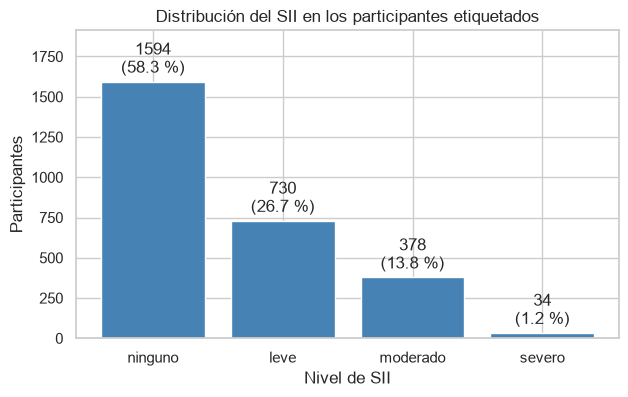

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(distribucion_sii.index, distribucion_sii["participantes"], color="steelblue")
ax.bar_label(
    barras,
    labels=[
        f"{n}\n({p:.1f} %)"
        for n, p in zip(distribucion_sii["participantes"], distribucion_sii["%"])
    ],
    padding=3,
)
ax.set(
    xlabel="Nivel de SII",
    ylabel="Participantes",
    title="Distribución del SII en los participantes etiquetados",
)
ax.margins(y=0.2)
save_figure(fig, "sii_distribucion", FIGURAS_EDA)
plt.show()

In [18]:
CORTES_PCIAT = [-1, 30, 49, 79, 100]

total_pciat = train["PCIAT-PCIAT_Total"]
nivel_por_corte = (
    pd.cut(total_pciat, bins=CORTES_PCIAT, labels=list(NIVELES_SII.values()))
    .cat.add_categories("sin puntaje total")
    .fillna("sin puntaje total")
)
sii_texto = train["sii"].map(NIVELES_SII).fillna("sin SII")

pd.crosstab(
    nivel_por_corte,
    sii_texto,
    rownames=["nivel según el puntaje total"],
    colnames=["SII registrado"],
).reindex(columns=[*NIVELES_SII.values(), "sin SII"], fill_value=0)

SII registrado,ninguno,leve,moderado,severo,sin SII
nivel según el puntaje total,,,,,
ninguno,1594,0,0,0,0
leve,0,730,0,0,0
moderado,0,0,378,0,0
severo,0,0,0,34,0
sin puntaje total,0,0,0,0,1224


In [19]:
items_pciat = [
    c for c in train.columns if c.startswith("PCIAT-PCIAT_") and c != "PCIAT-PCIAT_Total"
]

items_faltantes = train.loc[etiquetados, items_pciat].isna().sum(axis="columns")
display(
    items_faltantes.value_counts()
    .sort_index()
    .rename_axis("ítems faltantes")
    .rename("participantes etiquetados")
)

suma_items = train.loc[etiquetados, items_pciat].sum(axis="columns", min_count=1)
con_faltantes = items_faltantes > 0
total_maximo = (
    total_pciat[etiquetados][con_faltantes] + 5 * items_faltantes[con_faltantes]
).clip(upper=100)
nivel_maximo = pd.cut(total_maximo, bins=CORTES_PCIAT, labels=False)
sii_con_faltantes = train.loc[etiquetados, "sii"][con_faltantes]

pd.Series(
    {
        "puntaje total distinto de la suma de ítems": (
            suma_items != total_pciat[etiquetados]
        ).sum(),
        "etiquetados con ítems faltantes": con_faltantes.sum(),
        "con nivel máximo posible mayor al registrado": (
            nivel_maximo > sii_con_faltantes
        ).sum(),
    },
    name="conteo",
)

ítems faltantes
0     2671
1       52
2        9
3        1
5        1
10       1
20       1
Name: participantes etiquetados, dtype: int64

puntaje total distinto de la suma de ítems       1
etiquetados con ítems faltantes                 65
con nivel máximo posible mayor al registrado    17
Name: conteo, dtype: int64

In [20]:
discrepantes = suma_items.ne(total_pciat[etiquetados]) & items_faltantes.lt(len(items_pciat))
pd.Series(
    {
        "etiquetados sin ninguna respuesta a los ítems": (items_faltantes == len(items_pciat)).sum(),
        "discrepancias con al menos un ítem respondido": discrepantes.sum(),
    },
    name="conteo",
)

etiquetados sin ninguna respuesta a los ítems    1
discrepancias con al menos un ítem respondido    0
Name: conteo, dtype: int64

In [21]:
columnas_medicion = estructura[estructura["grupo"] != "temporada de instrumento"]


def cobertura_por_instrumento(datos: pd.DataFrame) -> pd.Series:
    """Porcentaje de participantes con al menos una medición de cada instrumento."""
    cobertura = {
        instrumento: 100 * datos[columnas.index].notna().any(axis="columns").mean()
        for instrumento, columnas in columnas_medicion.groupby("instrumento", sort=False)
    }
    cobertura["Parent-Child Internet Addiction Test"] = (
        100 * datos[[*items_pciat, "PCIAT-PCIAT_Total"]].notna().any(axis="columns").mean()
    )
    return pd.Series(cobertura).add_prefix("% con ")


comparacion = pd.DataFrame(
    {
        nombre: pd.concat(
            [
                pd.Series(
                    {
                        "participantes": len(datos),
                        "edad media": datos["Basic_Demos-Age"].mean(),
                        "edad mediana": datos["Basic_Demos-Age"].median(),
                        "% mujeres": 100 * datos["Basic_Demos-Sex"].mean(),
                    }
                ),
                cobertura_por_instrumento(datos),
            ]
        )
        for nombre, datos in {
            "con SII": train[etiquetados],
            "sin SII": train[~etiquetados],
        }.items()
    }
).round(1)
comparacion

,con SII,sin SII
participantes,2736.0,1224.0
edad media,10.2,10.9
edad mediana,10.0,10.0
% mujeres,36.4,39.1
% con Demographics,100.0,100.0
% con Children's Global Assessment Scale,85.6,6.5
% con Physical Measures,94.2,41.3
% con FitnessGram Vitals and Treadmill,26.7,1.0
% con FitnessGram Child,70.2,33.3
% con Bio-electric Impedance Analysis,66.3,14.5


In [22]:
SEXO = {0: "masculino", 1: "femenino"}
GRUPOS_EDAD = ["5–12", "13–17", "18–22"]

etiquetados_df = train[etiquetados]
grupo_edad = pd.cut(etiquetados_df["Basic_Demos-Age"], bins=[4, 12, 17, 22], labels=GRUPOS_EDAD)
sexo = etiquetados_df["Basic_Demos-Sex"].map(SEXO)
sii_etiquetados = etiquetados_df["sii"].astype(int).map(NIVELES_SII)
columnas_sii = [*NIVELES_SII.values(), "total"]

display(
    pd.crosstab(
        [sexo, grupo_edad],
        sii_etiquetados,
        rownames=["sexo", "grupo de edad"],
        colnames=["SII"],
        margins=True,
        margins_name="total",
    ).reindex(columns=columnas_sii)
)

display(
    (
        100
        * pd.crosstab(sexo, sii_etiquetados, normalize="index").reindex(
            columns=list(NIVELES_SII.values())
        )
    )
    .round(1)
    .rename_axis(index="sexo", columns="SII (%)")
)

proporciones_edad = (
    100
    * pd.crosstab(grupo_edad, sii_etiquetados, normalize="index").reindex(
        columns=list(NIVELES_SII.values())
    )
).rename_axis(index="grupo de edad", columns="SII (%)")
proporciones_edad.round(1)

SII                      ninguno  leve  moderado  severo  total
sexo      grupo de edad                                        
femenino  5–12               529   151        42       1    723
          13–17               96    86        54       5    241
          18–22               13    12         6       2     33
masculino 5–12               834   347       161       5   1347
          13–17              103   116       103      19    341
          18–22               19    18        12       2     51
total                       1594   730       378      34   2736

SII (%),ninguno,leve,moderado,severo
sexo,,,,
femenino,64.0,25.0,10.2,0.8
masculino,55.0,27.7,15.9,1.5


SII (%),ninguno,leve,moderado,severo
grupo de edad,,,,
5–12,65.8,24.1,9.8,0.3
13–17,34.2,34.7,27.0,4.1
18–22,38.1,35.7,21.4,4.8


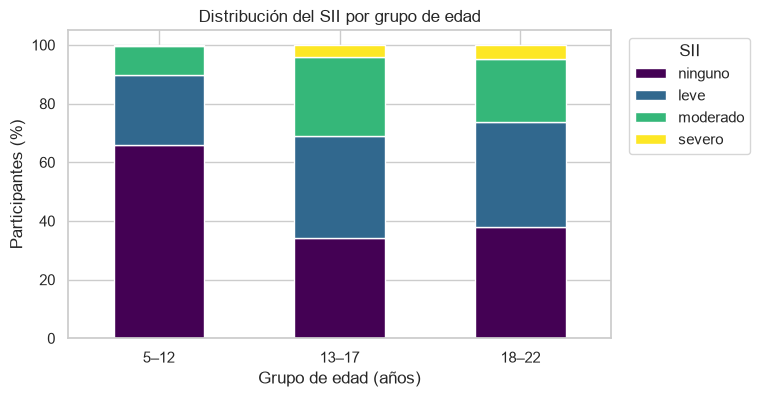

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
proporciones_edad.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", rot=0)
ax.set(
    xlabel="Grupo de edad (años)",
    ylabel="Participantes (%)",
    title="Distribución del SII por grupo de edad",
)
ax.legend(title="SII", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure(fig, "sii_por_grupo_edad", FIGURAS_EDA)
plt.show()

In [24]:
N_PARTICIONES = 5

conteo_clases = train.loc[etiquetados, "sii"].astype(int).value_counts().sort_index()
n_etiquetados = conteo_clases.sum()
n_clases = len(conteo_clases)

pesos_clase = pd.DataFrame(
    {
        "participantes": conteo_clases,
        "peso de clase": (n_etiquetados / (n_clases * conteo_clases)).round(2),
        "casos por partición externa de evaluación": (
            conteo_clases / N_PARTICIONES
        ).round(1),
        "casos por partición interna de evaluación": (
            conteo_clases * (N_PARTICIONES - 1) / N_PARTICIONES**2
        ).round(1),
    }
).rename(index=NIVELES_SII)
pesos_clase.index.name = "SII"
pesos_clase

,participantes,peso de clase,casos por partición externa de evaluación,casos por partición interna de evaluación
SII,,,,
ninguno,1594,0.43,318.8,255.0
leve,730,0.94,146.0,116.8
moderado,378,1.81,75.6,60.5
severo,34,20.12,6.8,5.4


### Conclusión

#### Población de análisis

| | Participantes | % |
|---|---|---|
| Con SII | 2.736 | 69,1 |
| Sin SII | 1.224 | 30,9 |
| Total | 3.960 | 100,0 |

Ninguno de los participantes sin SII tiene respuestas del PCIAT, por lo que su nivel de severidad no puede reconstruirse. Frente a los etiquetados, presentan un perfil demográfico similar, pero una cobertura menor en los instrumentos de evaluación:

| | Con SII | Sin SII |
|---|---|---|
| Edad media (años) | 10,2 | 10,9 |
| Mujeres (%) | 36,4 | 39,1 |
| Con medidas físicas (%) | 94,2 | 41,3 |
| Con escala de sueño (%) | 92,4 | 6,7 |
| Con funcionamiento global (%) | 85,6 | 6,5 |

La ausencia del SII se concentra en participantes que completaron una parte menor de la evaluación, más que en un perfil demográfico distinto. El análisis se restringe a los 2.736 participantes etiquetados, con la salvedad de que representan a quienes completaron una proporción mayor del protocolo del Healthy Brain Network.

#### Calidad de la variable objetivo

- **Consistencia con el PCIAT:** en todos los participantes etiquetados, el SII coincide con el nivel que corresponde al puntaje total según los puntos de corte; es una discretización directa de ese puntaje.
- **Ítems sin responder:** 65 participantes etiquetados (2,4 %) tienen al menos un ítem faltante, y en 52 de ellos falta uno solo. En todos los participantes con al menos un ítem respondido, el puntaje total coincide con la suma de los ítems respondidos, de modo que los ítems faltantes se contabilizan como cero. Un participante tiene registrado el puntaje total sin ninguna respuesta a los ítems, por lo que su puntaje no puede verificarse.
- **Posible subestimación:** en 17 participantes, el nivel podría ser mayor al registrado si los ítems faltantes hubieran recibido la puntuación máxima. Estos casos se conservan con el SII registrado, porque reconstruir las respuestas faltantes requeriría supuestos sin respaldo en los datos; constituyen una fuente de ruido en la variable objetivo que tiende a subestimar la severidad.

#### Distribución por sexo y edad

| Subgrupo | Participantes | Moderado o severo (%) | Casos severos |
|---|---|---|---|
| Mujeres | 997 | 11,0 | 8 |
| Hombres | 1.739 | 17,4 | 26 |
| 5 a 12 años | 2.070 | 10,1 | 6 |
| 13 a 17 años | 582 | 31,1 | 24 |
| 18 a 22 años | 84 | 26,2 | 4 |

- La proporción de PIU moderado o severo es mayor en hombres que en mujeres y aumenta de forma marcada de la infancia a la adolescencia. El grupo de 18 a 22 años muestra una proporción menor que el de 13 a 17, pero con 84 participantes la diferencia no permite afirmar una tendencia en ese tramo.
- La edad y el sexo se asocian de forma descriptiva con el SII, por lo que se espera que el modelo de referencia supere el desempeño por azar. Esto refuerza el diseño de la comparación: el conjunto principal debe aportar información más allá de la que ya contienen la edad y el sexo.
- Al cruzar sexo y grupo de edad, las celdas del nivel severo tienen entre 1 y 19 casos. Por ello, el análisis de errores por subgrupo compara sexos y grupos de edad por separado, y usa la tasa de subestimación de los niveles moderado y severo en conjunto.

#### Desbalance y validación

| SII | Participantes | Peso de clase | Casos por partición externa | Casos por partición interna |
|---|---|---|---|---|
| Ninguno | 1.594 | 0,43 | 318,8 | 255,0 |
| Leve | 730 | 0,94 | 146,0 | 116,8 |
| Moderado | 378 | 1,81 | 75,6 | 60,5 |
| Severo | 34 | 20,12 | 6,8 | 5,4 |

Con cinco particiones estratificadas, las estimaciones de sensibilidad del nivel severo y los umbrales que se optimizan en la validación interna se apoyan en muy pocos casos. Esto justifica repetir la validación cruzada con varias semillas y reportar la variabilidad entre repeticiones.

## 4. Cobertura y patrón de valores faltantes

Cada instrumento se aplica o no a cada participante, por lo que se espera que la ausencia de datos se presente por bloques y no de forma independiente en cada variable. Esta sección verifica esa estructura en los 2.736 participantes etiquetados, que constituyen la población de análisis. Se examinan:

- la cobertura de cada instrumento y la completitud de sus variables entre quienes lo tienen;
- las combinaciones de instrumentos más frecuentes y la co-ocurrencia entre instrumentos;
- la relación de la cobertura con la edad, incluida la aplicación de las dos versiones del cuestionario de actividad física, para adolescentes (PAQ-A) y para niños (PAQ-C);
- la correspondencia entre las columnas de temporada y la presencia de cada instrumento;
- la cobertura por nivel de SII, de forma descriptiva.

Con estos resultados se definen las estrategias candidatas de tratamiento de los faltantes, el uso de indicadores de ausencia, la integración de PAQ-A y PAQ-C, el destino de la resistencia cardiorrespiratoria y la inclusión de las temporadas de instrumento.

In [25]:
NOMBRES_INSTRUMENTO = {
    "Demographics": "Demográficas",
    "Physical Measures": "Medidas físicas",
    "FitnessGram Child": "FitnessGram",
    "FitnessGram Vitals and Treadmill": "Resistencia",
    "Bio-electric Impedance Analysis": "Bioimpedancia",
    "Physical Activity Questionnaire (Adolescents)": "PAQ-A",
    "Physical Activity Questionnaire (Children)": "PAQ-C",
    "Sleep Disturbance Scale": "SDS",
    "Children's Global Assessment Scale": "CGAS",
    "Internet Use": "Horas de internet",
}

medicion = estructura[estructura["grupo"] != "temporada de instrumento"].assign(
    instrumento_corto=lambda d: d["instrumento"].map(NOMBRES_INSTRUMENTO)
)
columnas_por_instrumento = {
    instrumento: list(columnas.index)
    for instrumento, columnas in medicion.groupby("instrumento_corto", sort=False)
}

presencia = pd.DataFrame(
    {
        instrumento: etiquetados_df[columnas].notna().any(axis="columns")
        for instrumento, columnas in columnas_por_instrumento.items()
    }
)
presencia["PAQ-A o PAQ-C"] = presencia["PAQ-A"] | presencia["PAQ-C"]

completitud = (
    pd.DataFrame(
        {
            "columnas": pd.Series(
                {i: len(c) for i, c in columnas_por_instrumento.items()}, dtype="Int64"
            ),
            "% con el instrumento": 100 * presencia.mean(),
            "% completo entre quienes lo tienen": pd.Series(
                {
                    i: 100
                    * etiquetados_df.loc[presencia[i], c].notna().all(axis="columns").mean()
                    for i, c in columnas_por_instrumento.items()
                }
            ),
        }
    )
    .reindex(presencia.columns)
    .round(1)
)
completitud.index.name = "instrumento"
completitud

,columnas,% con el instrumento,% completo entre quienes lo tienen
instrumento,,,
Demográficas,3,100.0,100.0
CGAS,1,85.6,100.0
Medidas físicas,7,94.2,18.0
Resistencia,3,26.7,99.5
FitnessGram,14,70.2,43.8
Bioimpedancia,16,66.3,100.0
PAQ-A,1,13.3,100.0
PAQ-C,1,52.6,100.0
SDS,2,92.4,99.9


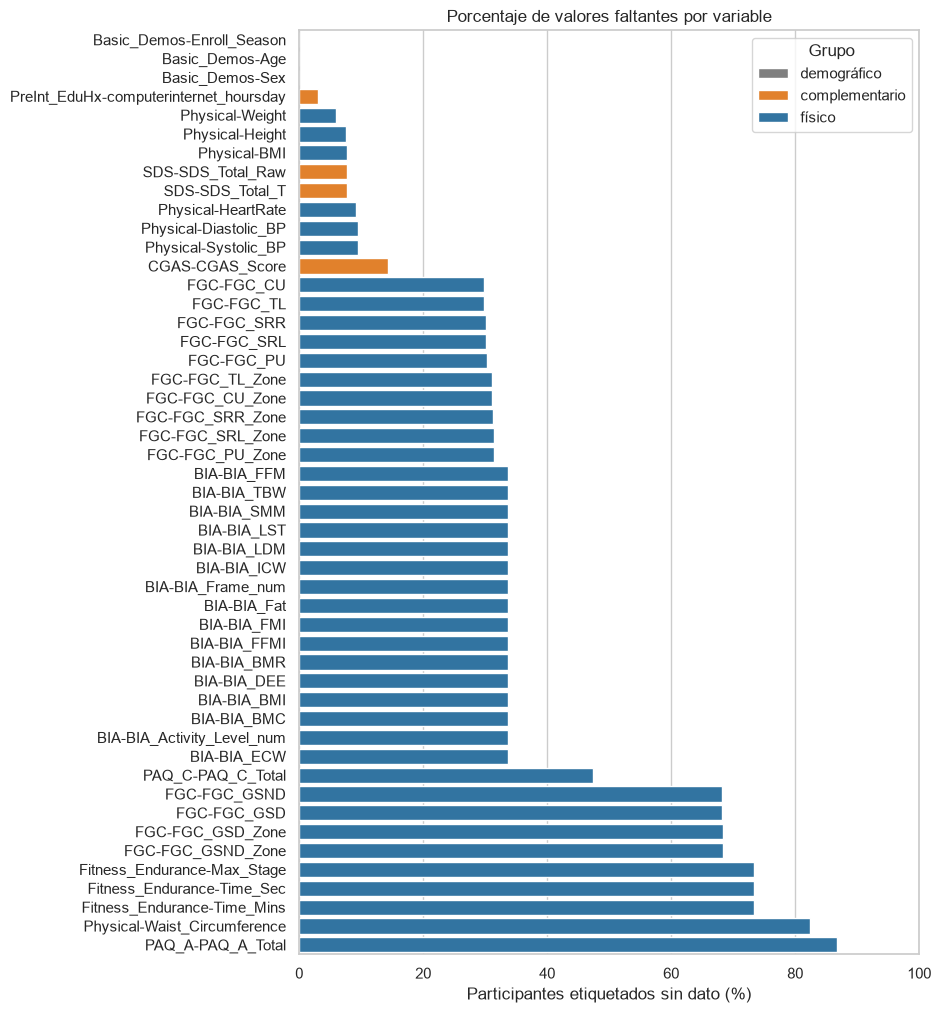

In [26]:
faltantes_variable = (
    (100 * etiquetados_df[medicion.index].isna().mean())
    .rename("% faltante")
    .rename_axis("columna")
    .to_frame()
    .join(medicion[["grupo", "instrumento_corto"]])
    .sort_values("% faltante")
)

fig, ax = plt.subplots(figsize=(8, 12))
sns.barplot(
    data=faltantes_variable.reset_index(),
    x="% faltante",
    y="columna",
    hue="grupo",
    dodge=False,
    palette={"demográfico": "tab:gray", "físico": "tab:blue", "complementario": "tab:orange"},
    ax=ax,
)
ax.set(
    xlabel="Participantes etiquetados sin dato (%)",
    ylabel="",
    title="Porcentaje de valores faltantes por variable",
    xlim=(0, 100),
)
ax.legend(title="Grupo", loc="upper right")
save_figure(fig, "faltantes_por_variable", FIGURAS_EDA)
plt.show()

In [27]:
instrumentos_patron = [
    "Medidas físicas",
    "FitnessGram",
    "Resistencia",
    "Bioimpedancia",
    "PAQ-A o PAQ-C",
    "SDS",
    "CGAS",
    "Horas de internet",
]

conteo_patrones = presencia[instrumentos_patron].value_counts()
tabla_patrones = conteo_patrones.head(10).reset_index(name="participantes")
tabla_patrones[instrumentos_patron] = tabla_patrones[instrumentos_patron].map(
    lambda presente: "✓" if presente else ""
)
tabla_patrones["%"] = (100 * tabla_patrones["participantes"] / len(presencia)).round(1)

print(f"Combinaciones distintas de instrumentos: {len(conteo_patrones)}")
print(
    "Participantes cubiertos por las 10 combinaciones más frecuentes: "
    f"{100 * conteo_patrones.head(10).sum() / len(presencia):.1f} %"
)
display(tabla_patrones)

(
    presencia[instrumentos_patron]
    .sum(axis="columns")
    .value_counts()
    .sort_index()
    .rename_axis("instrumentos disponibles (de 8)")
    .rename("participantes")
)

Combinaciones distintas de instrumentos: 79
Participantes cubiertos por las 10 combinaciones más frecuentes: 71.8 %


,Medidas físicas,FitnessGram,Resistencia,Bioimpedancia,PAQ-A o PAQ-C,SDS,CGAS,Horas de internet,participantes,%
0,✓,✓,,✓,✓,✓,✓,✓,488,17.8
1,✓,✓,✓,✓,✓,✓,✓,✓,345,12.6
2,✓,,,,✓,✓,✓,✓,218,8.0
3,✓,✓,✓,✓,,✓,✓,✓,198,7.2
4,✓,✓,,✓,,✓,✓,✓,157,5.7
5,✓,,,✓,✓,✓,✓,✓,140,5.1
6,✓,✓,,✓,✓,✓,,✓,123,4.5
7,✓,,,,,✓,✓,✓,115,4.2
8,✓,✓,,,✓,✓,✓,✓,95,3.5
9,✓,✓,✓,,✓,✓,✓,✓,85,3.1


instrumentos disponibles (de 8)
0      2
1      7
2     23
3     84
4    312
5    516
6    655
7    792
8    345
Name: participantes, dtype: int64

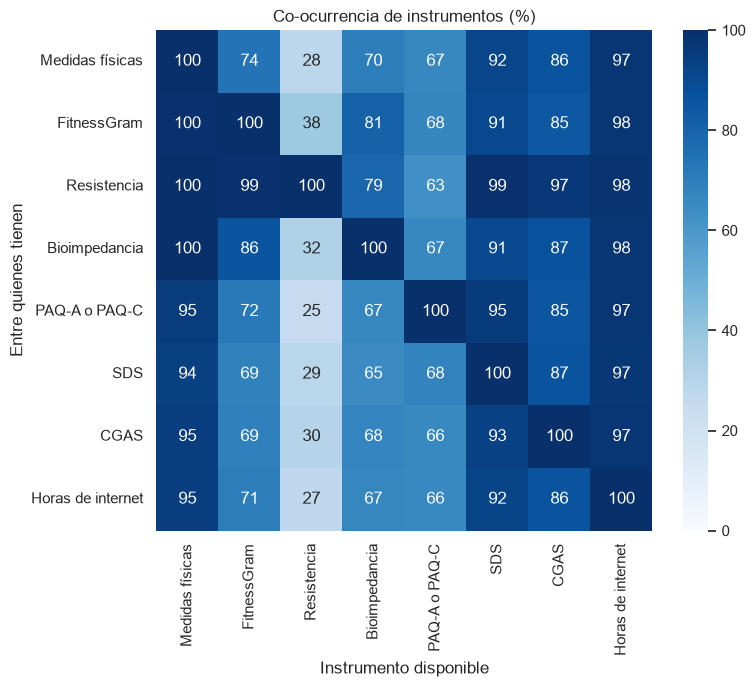

In [28]:
presencia_entera = presencia[instrumentos_patron].astype(int)
coocurrencia = (100 * (presencia_entera.T @ presencia_entera)).div(
    presencia_entera.sum(), axis="index"
)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(coocurrencia, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, ax=ax)
ax.set(
    xlabel="Instrumento disponible",
    ylabel="Entre quienes tienen",
    title="Co-ocurrencia de instrumentos (%)",
)
save_figure(fig, "coocurrencia_instrumentos", FIGURAS_EDA)
plt.show()

,Medidas físicas,FitnessGram,Resistencia,Bioimpedancia,PAQ-A o PAQ-C,SDS,CGAS,Horas de internet,PAQ-A,PAQ-C,participantes
grupo de edad,,,,,,,,,,,
5–12,94.3,70.7,35.3,66.1,58.8,95.2,86.5,97.6,0.0,58.8,2070
13–17,94.7,75.3,0.0,67.4,96.0,87.3,83.0,95.7,57.9,38.3,582
18–22,90.5,22.6,0.0,63.1,31.0,58.3,82.1,90.5,31.0,0.0,84


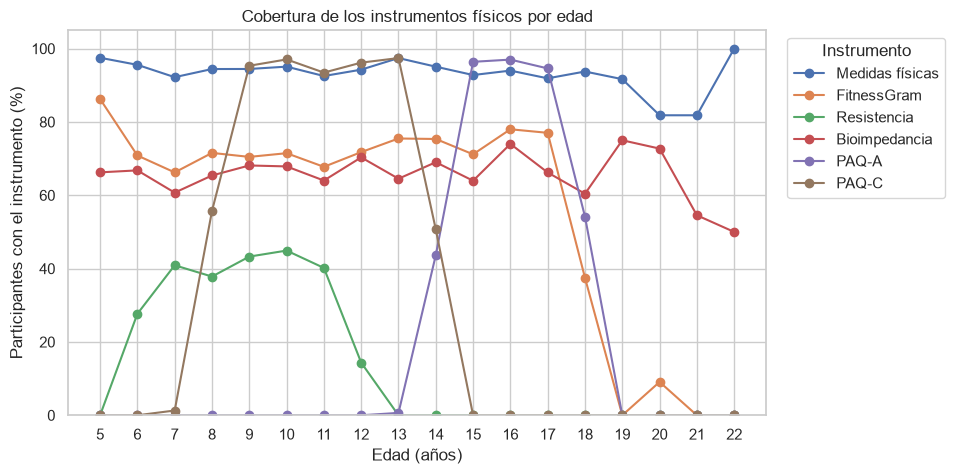

edad,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
participantes,80,271,308,341,342,305,214,209,155,142,111,100,74,48,12,11,11,2


In [29]:
instrumentos_edad = [*instrumentos_patron, "PAQ-A", "PAQ-C"]

display(
    (100 * presencia[instrumentos_edad].groupby(grupo_edad, observed=True).mean())
    .round(1)
    .assign(participantes=grupo_edad.value_counts())
    .rename_axis("grupo de edad")
)

cobertura_edad = 100 * presencia[instrumentos_edad].groupby(
    etiquetados_df["Basic_Demos-Age"]
).mean()

fig, ax = plt.subplots(figsize=(9, 5))
cobertura_edad[
    ["Medidas físicas", "FitnessGram", "Resistencia", "Bioimpedancia", "PAQ-A", "PAQ-C"]
].plot(marker="o", ax=ax)
ax.set_xticks(cobertura_edad.index)
ax.set(
    xlabel="Edad (años)",
    ylabel="Participantes con el instrumento (%)",
    title="Cobertura de los instrumentos físicos por edad",
    ylim=(0, 105),
)
ax.legend(title="Instrumento", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure(fig, "cobertura_por_edad", FIGURAS_EDA)
plt.show()

etiquetados_df["Basic_Demos-Age"].value_counts().sort_index().rename_axis("edad").rename(
    "participantes"
).to_frame().T

In [30]:
variables_parciales = {
    "FitnessGram": ["FGC-FGC_GSD", "FGC-FGC_GSND"],
    "Medidas físicas": ["Physical-Waist_Circumference"],
}

disponibilidad_edad = pd.DataFrame(
    {
        columna: 100
        * etiquetados_df.loc[presencia[instrumento], columna]
        .notna()
        .groupby(etiquetados_df.loc[presencia[instrumento], "Basic_Demos-Age"])
        .mean()
        for instrumento, columnas in variables_parciales.items()
        for columna in columnas
    }
).round(0)
disponibilidad_edad.index.name = "edad"
disponibilidad_edad.T.rename_axis(
    "variable (% disponible entre quienes tienen el instrumento)"
)

edad,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
variable (% disponible entre quienes tienen el instrumento),,,,,,,,,,,,,,,,,,
FGC-FGC_GSD,0.0,0.0,0.0,0.0,0.0,57.0,98.0,99.0,99.0,99.0,100.0,100.0,100.0,100.0,NaN,100.0,NaN,NaN
FGC-FGC_GSND,0.0,0.0,0.0,0.0,0.0,57.0,98.0,99.0,99.0,100.0,100.0,100.0,100.0,100.0,NaN,100.0,NaN,NaN
Physical-Waist_Circumference,32.0,22.0,16.0,20.0,15.0,14.0,18.0,15.0,19.0,23.0,21.0,30.0,18.0,18.0,9.0,11.0,0.0,0.0


In [31]:
display(
    pd.crosstab(
        presencia["PAQ-A"],
        presencia["PAQ-C"],
        rownames=["con PAQ-A"],
        colnames=["con PAQ-C"],
        margins=True,
        margins_name="total",
    )
)

version_paq = pd.Series(
    np.select(
        [
            presencia["PAQ-A"] & presencia["PAQ-C"],
            presencia["PAQ-A"],
            presencia["PAQ-C"],
        ],
        ["ambos", "solo PAQ-A", "solo PAQ-C"],
        default="ninguno",
    ),
    index=presencia.index,
    name="versión del PAQ",
)
display(
    etiquetados_df.groupby(version_paq)["Basic_Demos-Age"]
    .agg(["count", "min", "median", "max"])
    .rename(columns={"count": "participantes"})
)

etiquetados_df[["PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total"]].describe().round(2)

con PAQ-C,False,True,total
con PAQ-A,,,
False,934,1439,2373
True,362,1,363
total,1296,1440,2736


,participantes,min,median,max
versión del PAQ,,,,
ambos,1,13,13.0,13
ninguno,934,5,7.0,22
solo PAQ-A,362,14,16.0,18
solo PAQ-C,1439,7,10.0,14


,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total
count,363.00,1440.00
mean,2.19,2.59
std,0.82,0.79
min,0.66,0.58
25%,1.52,2.02
50%,2.08,2.55
75%,2.78,3.16
max,4.54,4.79


In [32]:
temporadas_instrumento = estructura[estructura["grupo"] == "temporada de instrumento"]

filas = []
for columna_temporada, instrumento in temporadas_instrumento["instrumento"].items():
    tiene_temporada = etiquetados_df[columna_temporada].notna()
    tiene_medicion = presencia[NOMBRES_INSTRUMENTO[instrumento]]
    filas.append(
        {
            "instrumento": NOMBRES_INSTRUMENTO[instrumento],
            "temporada y medición": (tiene_temporada & tiene_medicion).sum(),
            "solo temporada": (tiene_temporada & ~tiene_medicion).sum(),
            "solo medición": (~tiene_temporada & tiene_medicion).sum(),
            "ninguna": (~tiene_temporada & ~tiene_medicion).sum(),
        }
    )

pd.DataFrame(filas).set_index("instrumento")

,temporada y medición,solo temporada,solo medición,ninguna
instrumento,,,,
CGAS,2342,0,0,394
Medidas físicas,2578,17,0,141
Resistencia,731,529,0,1476
FitnessGram,1920,727,0,89
Bioimpedancia,1813,31,0,892
PAQ-A,363,0,0,2373
PAQ-C,1440,0,0,1296
SDS,2527,0,0,209
Horas de internet,2654,65,0,17


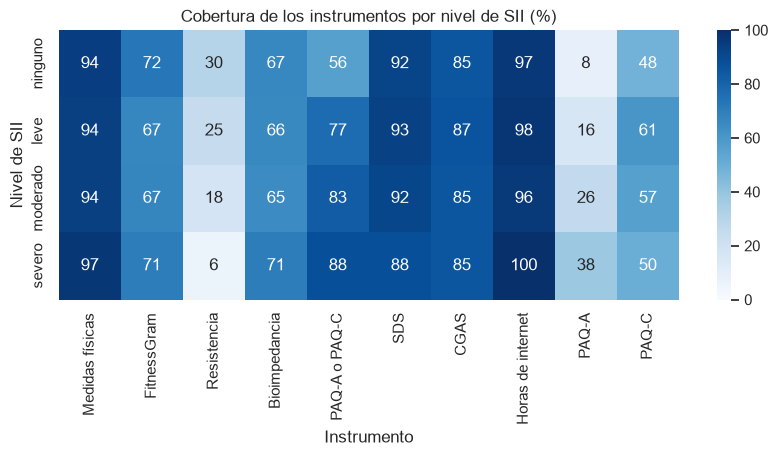

,Medidas físicas,FitnessGram,Resistencia,Bioimpedancia,PAQ-A o PAQ-C,SDS,CGAS,Horas de internet,PAQ-A,PAQ-C,participantes
SII,,,,,,,,,,,
ninguno,94.3,72.4,30.2,66.8,56.3,92.3,85.3,96.7,8.2,48.1,1594
leve,94.1,66.8,24.7,65.8,76.7,93.2,86.6,97.9,16.3,60.5,730
moderado,93.9,67.2,17.7,64.8,83.1,91.5,85.2,96.0,26.5,56.6,378
severo,97.1,70.6,5.9,70.6,88.2,88.2,85.3,100.0,38.2,50.0,34


In [33]:
cobertura_sii = (
    100 * presencia[instrumentos_edad].groupby(sii_etiquetados).mean()
).reindex(list(NIVELES_SII.values()))
cobertura_sii.index.name = "SII"

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(cobertura_sii, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, ax=ax)
ax.set(
    xlabel="Instrumento",
    ylabel="Nivel de SII",
    title="Cobertura de los instrumentos por nivel de SII (%)",
)
save_figure(fig, "cobertura_por_sii", FIGURAS_EDA)
plt.show()

cobertura_sii.round(1).assign(participantes=sii_etiquetados.value_counts())

### Conclusión

#### Cobertura y completitud por instrumento

Se usan dos medidas. La **cobertura** es el porcentaje de participantes que tienen al menos un dato del instrumento. La **completitud** es, entre esos participantes, el porcentaje que tiene todas las variables del instrumento registradas.

| Instrumento | Participantes con al menos un dato del instrumento (%) | De ellos, con todas sus variables registradas (%) |
|---|---|---|
| Medidas físicas | 94,2 | 18,0 |
| FitnessGram | 70,2 | 43,8 |
| Resistencia | 26,7 | 99,5 |
| Bioimpedancia | 66,3 | 100,0 |
| PAQ (A o C) | 65,9 | No aplica: una sola variable por versión |
| SDS | 92,4 | 99,9 |
| CGAS | 85,6 | 100,0 |
| Horas de internet | 97,0 | 100,0 |

La cobertura coincide con la reportada en la formulación del proyecto. En casi todos los instrumentos, quien tiene un dato tiene todos: la completitud es igual o cercana al 100 %. Las dos excepciones se deben a una variable concreta en cada caso:

- **Medidas físicas (18,0 %):** la circunferencia de cintura falta en el 82,3 % de los participantes, mientras que las demás medidas faltan en menos del 10 %. Su disponibilidad varía entre el 0 % y el 32 % según la edad, sin un patrón claro.
- **FitnessGram (43,8 %):** la fuerza de agarre falta en cerca del 68 % de los participantes, frente a cerca del 30 % de las demás pruebas. Esta prueba no se aplica antes de los 10 años. A los 10 años está disponible en el 57 % de quienes tienen FitnessGram, y desde los 11 en el 98 % o más.

#### Cómo se combinan los instrumentos

- **Variedad de combinaciones:** hay 79 combinaciones distintas de instrumentos entre los participantes. Las 10 más frecuentes agrupan al 71,8 %.
- **Combinaciones más comunes:** la más frecuente, con el 17,8 % de los participantes, incluye todos los instrumentos excepto la resistencia. El 12,6 % tiene los ocho instrumentos, el 65,5 % tiene al menos seis y 2 participantes no tienen ninguno.
- **Dependencia entre instrumentos:** todos los participantes con FitnessGram, resistencia o bioimpedancia tienen también medidas físicas. Es decir, las medidas físicas se toman primero y las demás pruebas se agregan sobre ellas. Además, el 99 % de quienes tienen resistencia tienen FitnessGram.
- **Columnas de temporada:** ningún participante tiene datos de un instrumento sin su temporada. En cambio, algunos tienen la temporada pero no los datos; por ejemplo, 727 participantes en FitnessGram y 529 en resistencia. La temporada indica, en la práctica, si el instrumento estaba programado, que es la misma información que aporta saber si sus datos faltan.

#### Instrumentos que dependen de la edad

Varios instrumentos solo se aplican en ciertas edades. En esos casos, el dato falta porque el protocolo no contempla la prueba a esa edad, no por un problema en la recolección.

| Instrumento o variable | Edades en las que hay datos |
|---|---|
| Resistencia | De 6 a 12 años, con un máximo del 45 % de cobertura; ninguno desde los 13 |
| PAQ-C (versión para niños) | De 7 a 14 años |
| PAQ-A (versión para adolescentes) | De 13 a 18 años |
| Fuerza de agarre | Desde los 10 años |
| FitnessGram | Hasta los 18 años; casi ninguno después |
| SDS | Menor cobertura entre 18 y 22 años (58,3 %, frente a 87–95 % en los grupos menores) |

Las medidas físicas y la bioimpedancia tienen una cobertura similar en todas las edades. Entre los 19 y los 22 años hay solo 36 participantes, por lo que los porcentajes de ese tramo son poco estables.

Como la ausencia depende de la edad, que es una variable conocida, los faltantes no son completamente aleatorios. Esto tiene dos consecuencias para el modelado:

- **Imputación:** la imputación simple asigna el mismo valor a todos los participantes, sin importar su edad; por ejemplo, imputaría a un adolescente un valor de resistencia calculado con niños. La imputación multivariada puede tener en cuenta la edad. La elección entre estrategias se hace en la validación interna.
- **Indicadores de ausencia:** un indicador que marque "no tiene PAQ-C" o "no tiene resistencia" refleja en buena parte la edad del participante, que ya está en todos los conjuntos de variables. Su aporte en los modelos debe interpretarse con cautela.

#### PAQ-A y PAQ-C

Las dos versiones casi nunca coinciden: 362 participantes tienen solo PAQ-A, 1.439 solo PAQ-C y uno, de 13 años, tiene ambas. Las dos miden la actividad física en la misma escala de 1 a 5, con distribuciones similares (medias de 2,19 y 2,59). Por eso se fusionan en una sola variable de actividad física autorreportada, con una cobertura del 65,9 %. Para el participante con ambas versiones se usa el promedio.

#### Cobertura por nivel de SII

Las medidas físicas, la bioimpedancia, el SDS, el CGAS y las horas de internet tienen una cobertura similar en los cuatro niveles de SII. Las diferencias aparecen solo en los instrumentos que dependen de la edad: la cobertura de la resistencia baja de 30,2 % en el nivel ninguno a 5,9 % en el severo, y la del PAQ sube de 56,3 % a 88,2 %. Como el SII es mayor en adolescentes que en niños, estas diferencias son coherentes con lo observado por edad. El nivel severo tiene solo 34 participantes, por lo que sus porcentajes son poco estables. Este análisis es descriptivo y no se usa para seleccionar variables.

#### Decisiones

| Decisión | Motivo |
|---|---|
| Excluir la resistencia cardiorrespiratoria (3 variables) | Solo se aplica entre 6 y 12 años, y aun en esas edades su cobertura no supera el 45 % |
| Excluir la circunferencia de cintura | Falta en el 82,3 % de los participantes y su ausencia no se explica por la edad |
| Conservar la fuerza de agarre | Falta por edad (no se aplica antes de los 10 años), pero está casi completa desde los 11 |
| Fusionar PAQ-A y PAQ-C en una variable | Son dos versiones del mismo cuestionario, para edades distintas y en la misma escala |
| Excluir las temporadas de instrumento | Solo indican si el instrumento estaba programado, información que ya aportan los indicadores de ausencia |
| Usar un indicador de ausencia por instrumento, no por variable | Las variables de un mismo instrumento faltan juntas, así que un indicador por instrumento basta |
| Mantener las tres estrategias de imputación candidatas | La validación interna decide entre manejo nativo, imputación simple con indicadores e imputación multivariada |

Con estas decisiones, el conjunto principal queda en 40 columnas (3 demográficas y 37 físicas) y el complementario en 44.

## 5. Valores inválidos y atípicos

Esta sección distingue tres situaciones:

- **Valores inválidos:** imposibles por definición del instrumento o por fisiología, como una grasa corporal negativa o una presión diastólica mayor que la sistólica. Se tratan como faltantes.
- **Valores por encima del máximo del protocolo:** el protocolo de FitnessGram registra algunas pruebas solo hasta un máximo: 75 repeticiones en abdominales y flexiones de brazos, y 12 pulgadas en flexibilidad y levantamiento de tronco [1]. Un valor superior no es imposible, sino que excede el tope de registro, por lo que se recorta al máximo y queda en la misma escala que los demás participantes.
- **Valores atípicos:** posibles, aunque poco frecuentes. Se conservan.

Las reglas se basan en criterios externos a los datos, sin usar su distribución ni el SII: el rango de la escala del instrumento, el máximo del protocolo de la prueba y límites fisiológicos amplios para participantes de 5 a 22 años. Las unidades son las del diccionario de datos: pulgadas para la estatura y libras para el peso. El diccionario no indica la unidad de la fuerza de agarre ni de las masas de bioimpedancia; sus valores son coherentes con kilogramos para la fuerza de agarre y con libras para las masas.

| Variable | Regla | Criterio |
|---|---|---|
| Estatura | Entre 30 y 84 pulgadas (76 a 213 cm) | Límite fisiológico amplio |
| Peso | Entre 20 y 400 libras (9 a 181 kg) | Límite fisiológico amplio |
| IMC (medidas físicas y bioimpedancia) | Entre 10 y 70 | Límite fisiológico amplio |
| Presión diastólica | Entre 30 y 130 mmHg | Límite fisiológico amplio |
| Presión sistólica | Entre 60 y 220 mmHg | Límite fisiológico amplio |
| Presión arterial | La diastólica debe ser menor que la sistólica; si no, ambas se marcan | Definición fisiológica |
| Frecuencia cardiaca | Entre 40 y 200 latidos por minuto | Límite fisiológico amplio |
| Abdominales y flexiones de brazos | No negativas; se recortan a 75 repeticiones | Máximo del protocolo FitnessGram [1] |
| Flexibilidad y levantamiento de tronco | No negativos; se recortan a 12 pulgadas | Máximo del protocolo FitnessGram [1] |
| Fuerza de agarre | Mayor que 0 y hasta 100 kg | Límite fisiológico amplio |
| Contenido mineral óseo | Mayor que 0 y hasta 20 libras | Límite fisiológico amplio |
| Demás masas, agua corporal e índices de bioimpedancia | Mayores que 0 | Definición de la medida |
| Grasa corporal | Mayor que 0 % y hasta 60 % | Límite fisiológico |
| Tasa metabólica basal | Entre 500 y 4.000 kcal por día | Límite fisiológico amplio |
| Gasto energético diario | Entre 500 y 8.000 kcal por día | Límite fisiológico amplio |
| Registro de bioimpedancia | Si una de sus variables es inválida, se anulan todas las variables del registro | Todas provienen de una misma medición del equipo y varias se calculan a partir de otras |
| CGAS | Entre 1 y 100 | Rango de la escala |
| SDS (puntaje bruto) | Entre 26 y 130 | 26 ítems calificados de 1 a 5 |
| PAQ-A y PAQ-C | Entre 1 y 5 | Rango de la escala |

La regla por registro se limita a la bioimpedancia. En las medidas físicas y en FitnessGram, cada variable proviene de una medición o prueba independiente, por lo que un valor inválido no compromete a las demás.

Las reglas se implementan en el paquete del proyecto, de modo que el cuaderno de modelado aplique exactamente los mismos criterios. Como no se ajustan con los datos, aplicarlas antes de la validación cruzada no introduce fuga de información. Además de cuantificar los valores inválidos y los recortados, la sección verifica la consistencia del IMC registrado con la estatura y el peso, y cuantifica los valores atípicos que se conservan.

**Referencia**

[1] The Cooper Institute, *FitnessGram Administration Manual: The Journey to MyHealthyZone*, 5.ª ed. Champaign, IL, EE. UU.: Human Kinetics, 2017.

In [34]:
diastolica, sistolica = BLOOD_PRESSURE_COLUMNS
columnas_regla = [
    c
    for c in dict.fromkeys([*POSITIVE_COLUMNS, *VALUE_RANGES, *BLOOD_PRESSURE_COLUMNS])
    if c in etiquetados_df.columns
]

mascara_invalidos = invalid_value_mask(etiquetados_df)

resumen_invalidos = pd.DataFrame(
    {
        "registros con dato": etiquetados_df[columnas_regla].notna().sum(),
        "valores inválidos": mascara_invalidos[columnas_regla].sum(),
    }
)
resumen_invalidos["% de los registrados"] = (
    100 * resumen_invalidos["valores inválidos"] / resumen_invalidos["registros con dato"]
).round(2)
resumen_invalidos.index.name = "columna"

recortados = pd.DataFrame(
    {
        "máximo del protocolo": pd.Series(PROTOCOL_MAXIMA),
        "registros con dato": etiquetados_df[list(PROTOCOL_MAXIMA)].notna().sum(),
        "valores recortados": pd.Series(
            {c: (etiquetados_df[c] > m).sum() for c, m in PROTOCOL_MAXIMA.items()}
        ),
    }
)
recortados["% de los registrados"] = (
    100 * recortados["valores recortados"] / recortados["registros con dato"]
).round(2)
recortados.index.name = "columna"

print(f"Columnas con regla de invalidez: {len(columnas_regla)}")
print(f"Valores inválidos en total: {mascara_invalidos.to_numpy().sum()}")
print(f"Participantes con al menos un valor inválido: {mascara_invalidos.any(axis='columns').sum()}")
print(
    "Participantes con presión diastólica mayor o igual que la sistólica: "
    f"{(etiquetados_df[diastolica] >= etiquetados_df[sistolica]).sum()}"
)
print(f"Valores recortados al máximo del protocolo: {recortados['valores recortados'].sum()}")

display(recortados)
resumen_invalidos[resumen_invalidos["valores inválidos"] > 0].sort_values(
    "valores inválidos", ascending=False
)

Columnas con regla de invalidez: 31
Valores inválidos en total: 2763
Participantes con al menos un valor inválido: 257
Participantes con presión diastólica mayor o igual que la sistólica: 2
Valores recortados al máximo del protocolo: 584


,máximo del protocolo,registros con dato,valores recortados,% de los registrados
columna,,,,
FGC-FGC_CU,75,1919,6,0.31
FGC-FGC_PU,75,1909,0,0.00
FGC-FGC_SRL,12,1911,207,10.83
FGC-FGC_SRR,12,1913,227,11.87
FGC-FGC_TL,12,1919,144,7.50


,registros con dato,valores inválidos,% de los registrados
columna,,,
BIA-BIA_Fat,1813,166,9.16
BIA-BIA_LDM,1813,166,9.16
BIA-BIA_TBW,1813,166,9.16
BIA-BIA_SMM,1813,166,9.16
BIA-BIA_BMC,1813,166,9.16
BIA-BIA_BMI,1813,166,9.16
BIA-BIA_BMR,1813,166,9.16
BIA-BIA_DEE,1813,166,9.16
BIA-BIA_ECW,1813,166,9.16


In [35]:
(
    mascara_invalidos[columnas_regla]
    .T.groupby(estructura.loc[columnas_regla, "instrumento"].map(NOMBRES_INSTRUMENTO))
    .any()
    .T.sum()
    .rename("participantes con al menos un valor inválido")
    .rename_axis("instrumento")
    .sort_values(ascending=False)
)

instrumento
Bioimpedancia      166
Medidas físicas     72
PAQ-C               10
PAQ-A                6
FitnessGram          4
SDS                  4
CGAS                 0
Name: participantes con al menos un valor inválido, dtype: int64

In [36]:
columnas_bia = [c for c in etiquetados_df.columns if c.startswith("BIA-") and c != "BIA-Season"]
mascara_por_valor = invalid_value_mask(etiquetados_df, propagate_records=False)

con_bia = etiquetados_df[columnas_bia].notna().any(axis="columns")
registro_bia_anulado = mascara_por_valor[columnas_bia].any(axis="columns")

display(
    pd.DataFrame(
        {
            "participantes": [
                con_bia.sum(),
                registro_bia_anulado.sum(),
                (con_bia & ~registro_bia_anulado).sum(),
            ],
            "% de los etiquetados": [
                round(100 * con_bia.mean(), 1),
                round(100 * registro_bia_anulado.mean(), 1),
                round(100 * (con_bia & ~registro_bia_anulado).mean(), 1),
            ],
        },
        index=pd.Index(
            [
                "con bioimpedancia",
                "con el registro anulado por al menos un valor inválido",
                "con bioimpedancia válida",
            ],
            name="bioimpedancia",
        ),
    )
)


def resumen_bioimpedancia(datos: pd.DataFrame) -> pd.Series:
    """Resume indicadores de consistencia de la bioimpedancia frente al peso corporal."""
    pares = datos[["BIA-BIA_FFM", "Physical-Weight"]].dropna()
    return pd.Series(
        {
            "masa libre de grasa mayor que el peso (participantes)": (
                pares["BIA-BIA_FFM"] > pares["Physical-Weight"]
            ).sum(),
            "masa libre de grasa máxima (libras)": datos["BIA-BIA_FFM"].max(),
            "agua corporal total máxima (libras)": datos["BIA-BIA_TBW"].max(),
            "tasa metabólica basal máxima (kcal por día)": datos["BIA-BIA_BMR"].max(),
        }
    )


pd.DataFrame(
    {
        "depuración valor por valor": resumen_bioimpedancia(
            cap_protocol_maxima(etiquetados_df).mask(mascara_por_valor)
        ),
        "depuración por registro": resumen_bioimpedancia(clean_values(etiquetados_df)),
    }
).round(2)

,participantes,% de los etiquetados
bioimpedancia,,
con bioimpedancia,1813,66.3
con el registro anulado por al menos un valor inválido,166,6.1
con bioimpedancia válida,1647,60.2


,depuración valor por valor,depuración por registro
masa libre de grasa mayor que el peso (participantes),31.00,0.00
masa libre de grasa máxima (libras),8799.08,186.29
agua corporal total máxima (libras),5690.91,138.46
tasa metabólica basal máxima (kcal por día),3987.68,2291.06


In [37]:
depurado = clean_values(etiquetados_df)
columnas_afectadas = list(
    dict.fromkeys(
        [
            *resumen_invalidos.index[resumen_invalidos["valores inválidos"] > 0],
            *recortados.index[recortados["valores recortados"] > 0],
        ]
    )
)


def resumen_distribucion(datos: pd.DataFrame) -> pd.DataFrame:
    """Resume cada columna con el mínimo, los percentiles 1, 50 y 99 y el máximo."""
    return datos.describe(percentiles=[0.01, 0.5, 0.99]).T[["min", "1%", "50%", "99%", "max"]]


pd.concat(
    {
        "original": resumen_distribucion(etiquetados_df[columnas_afectadas]),
        "depurado": resumen_distribucion(depurado[columnas_afectadas]),
    },
    axis="columns",
).round(2)

original                                       depurado  \
                           min       1%      50%      99%        max      min   
Physical-Weight           0.00     0.00    75.80   228.35     315.00    32.80   
Physical-BMI              0.00    12.86    17.82    35.68      46.10    10.28   
FGC-FGC_GSD               0.00     8.44    20.80    53.72     123.80     5.10   
FGC-FGC_GSND              0.00     8.67    19.40    50.77     124.00     6.10   
BIA-BIA_BMC              -7.79    -0.82     3.94    12.10    4115.36     0.01   
BIA-BIA_BMI               0.05    13.03    17.85    35.89      48.38    11.93   
BIA-BIA_BMR             813.40   870.93  1113.04  2162.98   83152.20   813.40   
BIA-BIA_DEE            1073.45  1177.26  1862.15  3911.76  124728.00  1073.45   
BIA-BIA_ECW               1.79     4.34    15.73    55.59    3233.00     1.79   
BIA-BIA_FFM              28.90    35.03    60.82   172.65    8799.08    28.90   
BIA-BIA_FFMI              7.86    12.43    14.06    23.97     217.77    11.44   
BIA-BIA_FMI            -194.16    -0.71     3.64    17.01      28.25     0.07   
BIA-BIA_Fat           -8745.08    -3.43    15.77   100.81     129.23     0.39   
BIA-BIA_ICW              17.84    19.07    28.77    71.98    2457.91    17.84   
BIA-BIA_LDM               4.64     7.52    16.28    45.40    3108.17     5.47   
BIA-BIA_LST              23.62    28.48    56.43   164.59    4683.71    23.62   
BIA-BIA_SMM              11.38    13.85    27.19    94.61    3607.69    11.38   
BIA-BIA_TBW              20.59    24.79    44.72   125.70    5690.91    20.59   
Physical-Diastolic_BP    11.00    44.00    68.00   114.23     179.00    32.00   
Physical-Systolic_BP     49.00    83.77   114.00   174.00     203.00    62.00   
Physical-HeartRate       27.00    52.00    81.00   117.00     138.00    45.00   
SDS-SDS_Total_Raw        17.00    26.00    39.00    72.00      96.00    26.00   
PAQ_A-PAQ_A_Total         0.66     0.99     2.08     4.30       4.54     1.00   
PAQ_C-PAQ_C_Total         0.58     1.04     2.55     4.40       4.79     1.00   
FGC-FGC_CU                0.00     0.00    10.00    50.00     115.00     0.00   
FGC-FGC_SRL               0.00     0.00     9.00    16.00      21.70     0.00   
FGC-FGC_SRR               0.00     0.00     9.00    16.94      21.00     0.00   
FGC-FGC_TL                0.00     2.00     9.00    15.00      21.00     0.00   

                                                           
                            1%      50%      99%      max  
Physical-Weight          38.04    76.90   228.97   315.00  
Physical-BMI             13.16    17.84    35.69    46.10  
FGC-FGC_GSD               8.91    20.80    53.60    88.80  
FGC-FGC_GSND              8.70    19.40    49.80    81.80  
BIA-BIA_BMC               0.74     3.84    11.44    17.57  
BIA-BIA_BMI              13.50    17.57    28.22    34.52  
BIA-BIA_BMR             871.24  1090.26  1751.10  2291.06  
BIA-BIA_DEE            1178.66  1822.77  3539.51  4517.13  
BIA-BIA_ECW               4.27    15.03    40.87    57.50  
BIA-BIA_FFM              35.06    58.39   128.78   186.29  
BIA-BIA_FFMI             12.47    13.95    19.58    26.73  
BIA-BIA_FMI               0.42     3.49    10.86    17.16  
BIA-BIA_Fat               1.42    14.90    56.88    59.92  
BIA-BIA_ICW              19.13    28.08    55.70    80.96  
BIA-BIA_LDM               7.40    15.76    34.58    47.83  
BIA-BIA_LST              28.45    54.12   122.26   177.75  
BIA-BIA_SMM              13.88    26.13    67.98   119.08  
BIA-BIA_TBW              24.62    42.91    96.45   138.46  
Physical-Diastolic_BP    44.00    68.00   111.00   130.00  
Physical-Systolic_BP     84.73   114.00   174.00   203.00  
Physical-HeartRate       53.00    81.00   117.00   138.00  
SDS-SDS_Total_Raw        26.00    39.00    72.00    96.00  
PAQ_A-PAQ_A_Total         1.02     2.08     4.30     4.54  
PAQ_C-PAQ_C_Total         1.10     2.56     4.40     4.79  
FGC-FGC_CU                0.00 

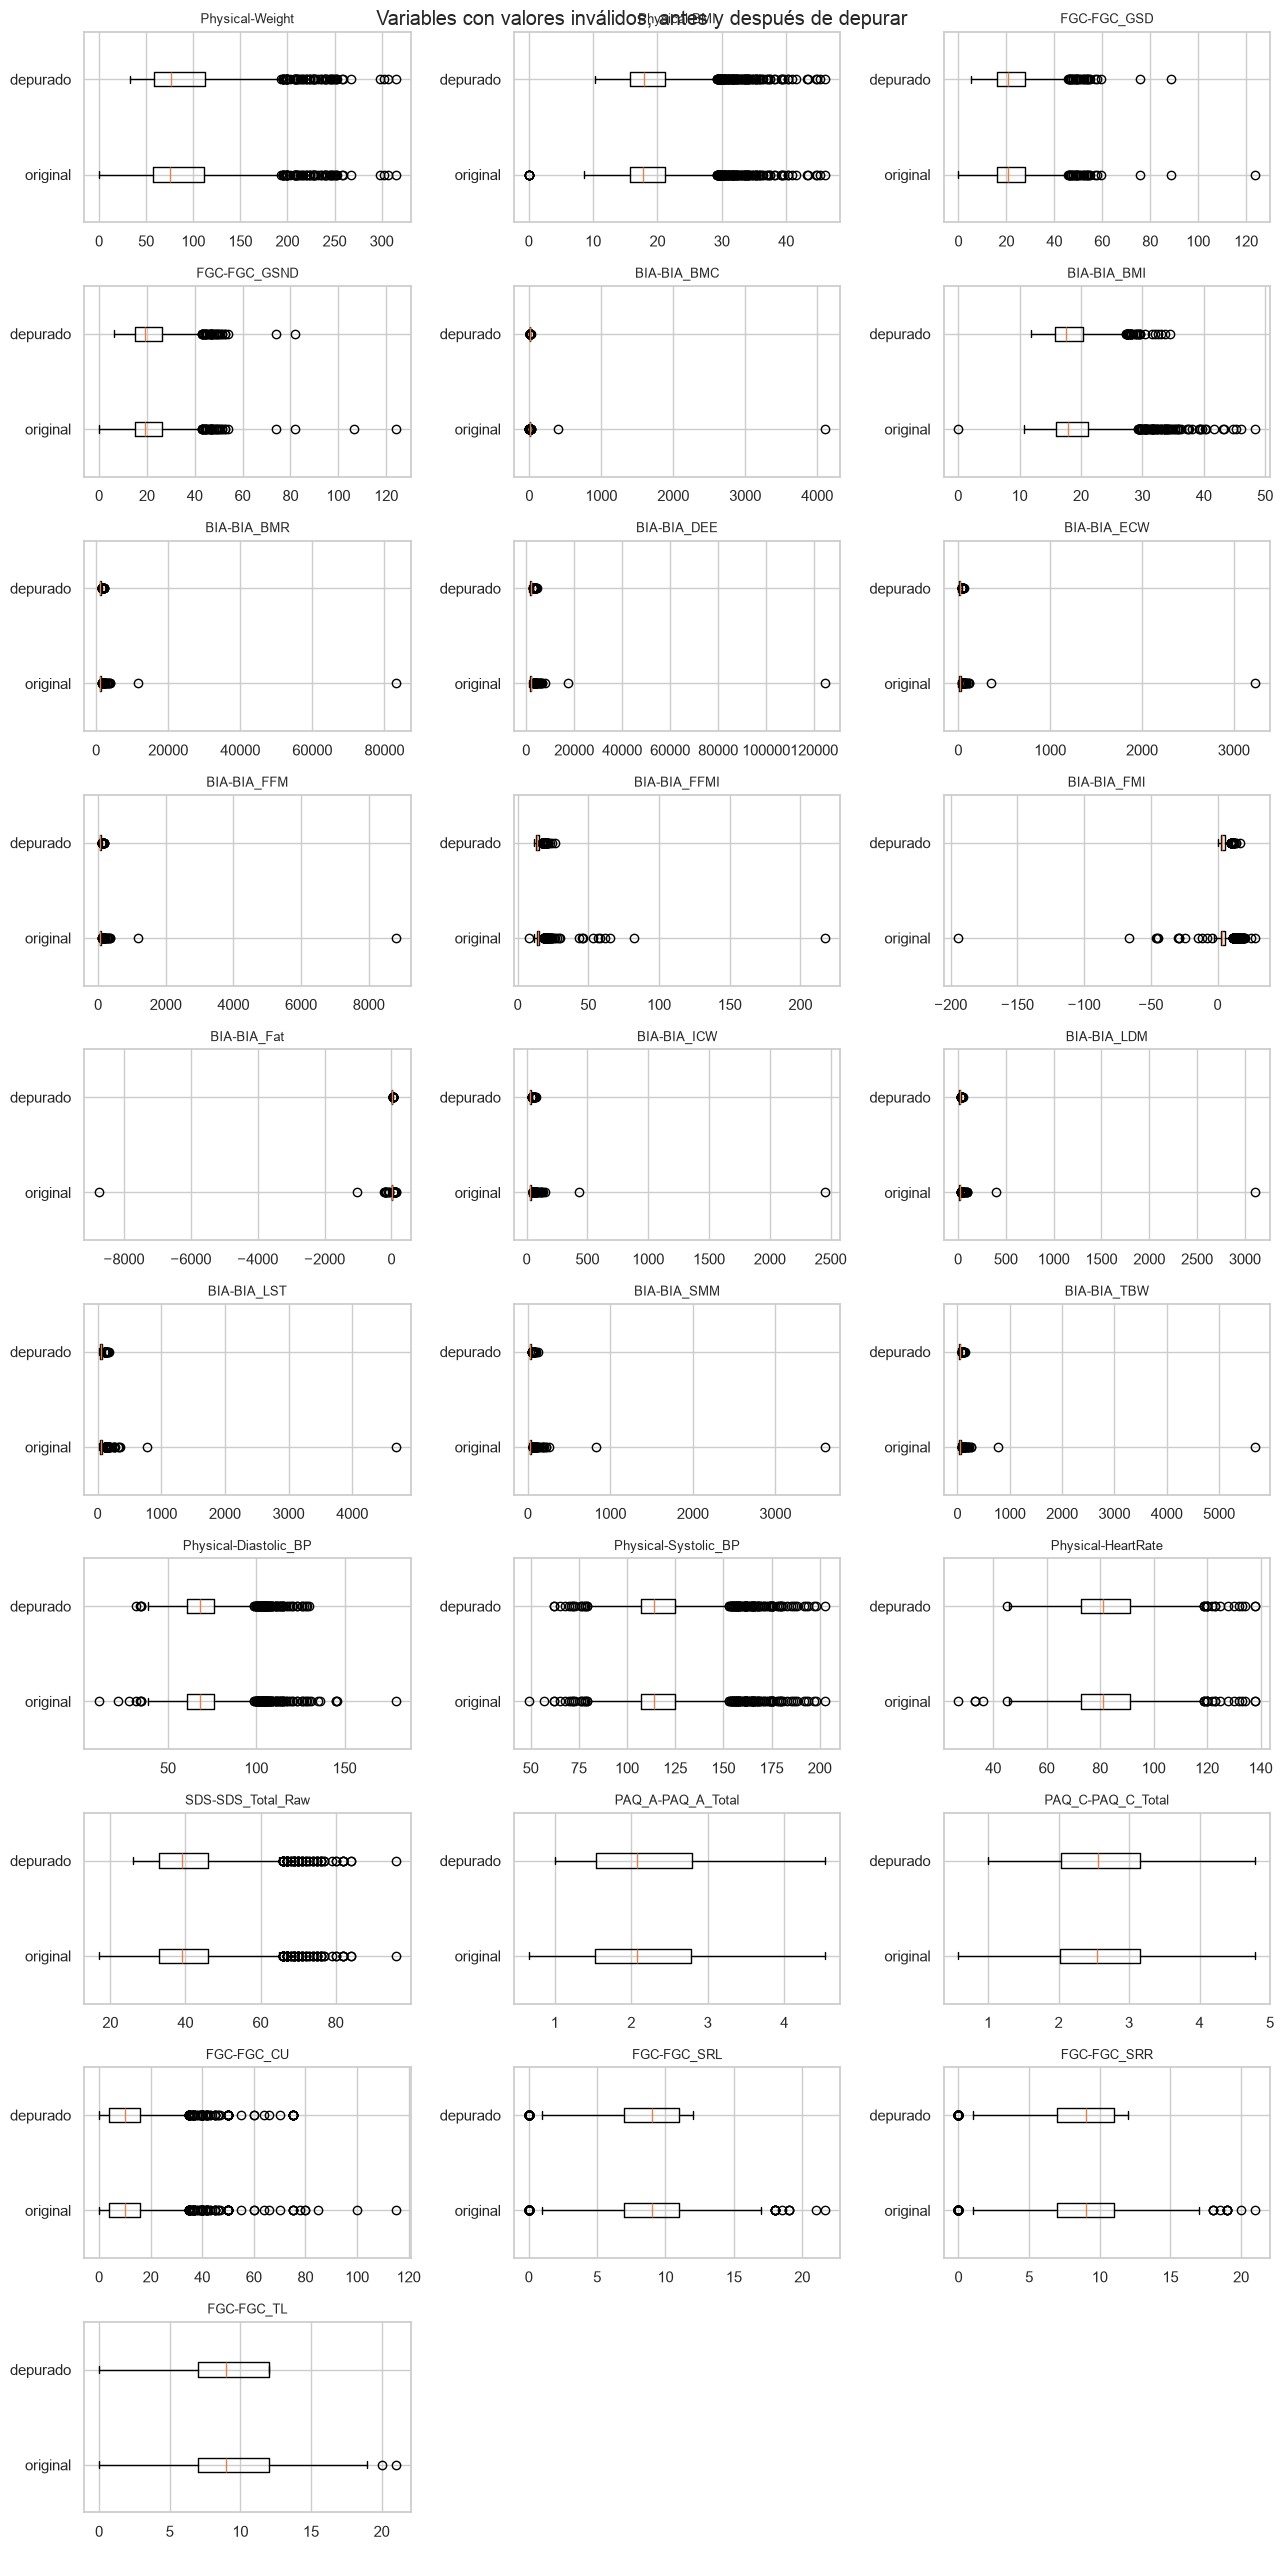

In [38]:
n_columnas_figura = 3
n_filas_figura = -(-len(columnas_afectadas) // n_columnas_figura)

fig, axes = plt.subplots(
    n_filas_figura,
    n_columnas_figura,
    figsize=(13, 2.6 * n_filas_figura),
    squeeze=False,
)
for ax, columna in zip(axes.flat, columnas_afectadas):
    ax.boxplot(
        [etiquetados_df[columna].dropna(), depurado[columna].dropna()],
        tick_labels=["original", "depurado"],
        orientation="horizontal",
    )
    ax.set_title(columna, fontsize=9)
for ax in axes.flat[len(columnas_afectadas) :]:
    ax.set_visible(False)

fig.suptitle("Variables con valores inválidos, antes y después de depurar")
fig.tight_layout()
save_figure(fig, "valores_invalidos_antes_despues", FIGURAS_EDA)
plt.show()

In [39]:
medidas_imc = depurado[["Physical-Height", "Physical-Weight", "Physical-BMI"]].dropna()
imc_calculado = 703 * medidas_imc["Physical-Weight"] / medidas_imc["Physical-Height"] ** 2
diferencia_imc = (medidas_imc["Physical-BMI"] - imc_calculado).abs()

pd.Series(
    {
        "participantes con estatura, peso e IMC": len(medidas_imc),
        "diferencia mayor a 0,5": (diferencia_imc > 0.5).sum(),
        "diferencia mayor a 2": (diferencia_imc > 2).sum(),
        "diferencia máxima": round(diferencia_imc.max(), 2),
    },
    name="IMC registrado frente a IMC calculado",
)

participantes con estatura, peso e IMC    2517.0
diferencia mayor a 0,5                       0.0
diferencia mayor a 2                         0.0
diferencia máxima                            0.0
Name: IMC registrado frente a IMC calculado, dtype: float64

In [40]:
columnas_numericas = estructura.index[estructura["tipo_analitico"] == "numérica"]

cuartil_1 = depurado[columnas_numericas].quantile(0.25)
cuartil_3 = depurado[columnas_numericas].quantile(0.75)
rango_intercuartil = cuartil_3 - cuartil_1
atipicos = (depurado[columnas_numericas] < cuartil_1 - 3 * rango_intercuartil) | (
    depurado[columnas_numericas] > cuartil_3 + 3 * rango_intercuartil
)

tabla_atipicos = pd.DataFrame(
    {
        "registros con dato": depurado[columnas_numericas].notna().sum(),
        "atípicos extremos": atipicos.sum(),
    }
)
tabla_atipicos["%"] = (
    100 * tabla_atipicos["atípicos extremos"] / tabla_atipicos["registros con dato"]
).round(2)
tabla_atipicos.index.name = "columna"

print(f"Columnas numéricas con al menos un atípico extremo: {(tabla_atipicos['atípicos extremos'] > 0).sum()}")
tabla_atipicos[tabla_atipicos["atípicos extremos"] > 0].sort_values("%", ascending=False)

Columnas numéricas con al menos un atípico extremo: 25


,registros con dato,atípicos extremos,%
columna,,,
FGC-FGC_CU,1919,16,0.83
Physical-BMI,2517,18,0.72
Fitness_Endurance-Time_Mins,728,5,0.69
BIA-BIA_FFMI,1647,11,0.67
FGC-FGC_PU,1909,12,0.63
Physical-Systolic_BP,2474,15,0.61
BIA-BIA_BMC,1647,9,0.55
BIA-BIA_SMM,1647,9,0.55
Physical-Waist_Circumference,483,2,0.41


### Conclusión

#### Resultado de la depuración

| | Valores | Participantes |
|---|---|---|
| Valores tratados como faltantes | 2.763 | 257 |
| Valores sobre el máximo del protocolo, recortados | 584 | — |

La mayoría de los valores tratados como faltantes provienen de la anulación de registros completos de bioimpedancia. Fuera de ese instrumento, los valores inválidos son pocos:

| Instrumento | Participantes con al menos un valor inválido | Detalle |
|---|---|---|
| Bioimpedancia | 166 | Registro completo anulado; ver el apartado siguiente |
| Medidas físicas | 72 | Peso (52 valores), presión diastólica (11), IMC (10), presión sistólica (4) y frecuencia cardiaca (4) |
| PAQ-C y PAQ-A | 16 | Puntajes menores que 1, fuera de la escala del cuestionario |
| FitnessGram | 4 | Fuerza de agarre igual a 0 o mayor que 100 kg |
| SDS | 4 | Puntajes brutos menores que 26 |
| CGAS | 0 | — |

Los valores eliminados son claramente imposibles, como pesos iguales a cero o una presión diastólica de 11 mmHg. Solo 2 participantes tienen la presión diastólica mayor o igual que la sistólica.

#### Registros de bioimpedancia

En la bioimpedancia, un valor imposible indica que falló la medición completa, no solo esa variable. Al depurar valor por valor quedaban masas libres de grasa de hasta 8.799 libras, agua corporal de hasta 5.691 libras y 31 participantes con una masa libre de grasa mayor que su propio peso. Al anular el registro completo, estas inconsistencias desaparecen:

| Indicador | Depuración valor por valor | Depuración por registro |
|---|---|---|
| Participantes con masa libre de grasa mayor que el peso | 31 | 0 |
| Masa libre de grasa máxima (libras) | 8.799 | 186 |
| Agua corporal total máxima (libras) | 5.691 | 138 |
| Tasa metabólica basal máxima (kcal por día) | 3.988 | 2.291 |

Se anulan 166 de los 1.813 registros de bioimpedancia (9,2 %), por lo que la cobertura efectiva del instrumento baja del 66,3 % al 60,2 % de los participantes etiquetados.

Los límites superiores del contenido mineral óseo y de la fuerza de agarre, y la anulación por registro de la bioimpedancia, se incorporaron después de una primera revisión, al encontrar valores imposibles que las reglas iniciales no cubrían. Todos se fijaron con criterios fisiológicos o de consistencia de la medición, no según la distribución de los datos ni el SII.

#### Máximos del protocolo de FitnessGram

| Prueba | Máximo | Valores recortados | % de los registrados |
|---|---|---|---|
| Flexibilidad derecha | 12 pulgadas | 227 | 11,9 |
| Flexibilidad izquierda | 12 pulgadas | 207 | 10,8 |
| Levantamiento de tronco | 12 pulgadas | 144 | 7,5 |
| Abdominales | 75 repeticiones | 6 | 0,3 |
| Flexiones de brazos | 75 repeticiones | 0 | 0,0 |

Entre el 7,5 % y el 11,9 % de las mediciones de flexibilidad y levantamiento de tronco superan el tope del protocolo. Tratarlas como inválidas habría eliminado más de 200 mediciones reales por prueba; al recortarlas, quedan en la escala que define el protocolo.

#### Consistencia del IMC

En los 2.517 participantes con estatura, peso e IMC, el IMC registrado coincide exactamente con el calculado a partir de la estatura y el peso. Es, por tanto, una variable derivada de las otras dos, lo que se tiene en cuenta en el análisis de redundancia.

#### Valores atípicos

Después de depurar, 25 variables numéricas tienen valores a más de tres rangos intercuartílicos de los cuartiles, incluidas las de resistencia y la circunferencia de cintura, ya excluidas en la sección anterior. En ninguna variable superan el 0,83 % de los registros. Entre las variables que se conservan, los porcentajes más altos corresponden a abdominales (0,83 %), IMC (0,72 %) e índice de masa libre de grasa (0,67 %). Estos valores se conservan: los modelos de ensamble basados en árboles son poco sensibles a ellos, y su efecto en la regresión logística y las máquinas de soporte vectorial se considera al definir las transformaciones de las variables.

#### Decisiones

| Decisión | Motivo |
|---|---|
| Tratar como faltantes los valores inválidos | Son imposibles por definición del instrumento o por fisiología |
| Anular el registro completo de bioimpedancia cuando alguna de sus variables es inválida | Todas provienen de una misma medición; un valor imposible indica que falló la medición completa |
| Recortar al máximo del protocolo las pruebas de FitnessGram | El protocolo registra esas pruebas solo hasta un tope; los valores superiores son reales, pero exceden la escala de registro |
| Conservar los valores atípicos | Son posibles y su efecto depende del modelo |
| Aplicar las reglas con el módulo del paquete, antes de la validación cruzada | Las reglas no se ajustan con los datos, por lo que no introducen fuga de información |

## 6. Distribuciones de los predictores

Esta sección describe la forma de cada predictor que se conserva tras las secciones anteriores: los conjuntos de variables sin la resistencia cardiorrespiratoria ni la circunferencia de cintura, con PAQ-A y PAQ-C fusionados en una sola variable de actividad física autorreportada y con los valores ya depurados. La fusión toma el puntaje disponible de cada participante y, si tiene ambas versiones, su promedio.

Para las variables numéricas se examinan:

- las escalas y estadísticos descriptivos;
- la asimetría, y si una transformación logarítmica la reduce;
- la concentración de valores en el mínimo o en el máximo (efectos de piso y de techo), incluidos los que produce el recorte al máximo del protocolo de FitnessGram.

Para las variables binarias, ordinales y nominales se examina la frecuencia de cada categoría, con atención a las categorías poco frecuentes.

Estos resultados definen las transformaciones que requieren los modelos sensibles a la escala, como la regresión logística y las máquinas de soporte vectorial. Los modelos de ensamble basados en árboles no dependen de la escala ni de la forma de la distribución.

In [41]:
COLUMNAS_SIN_COBERTURA = [
    "Fitness_Endurance-Max_Stage",
    "Fitness_Endurance-Time_Mins",
    "Fitness_Endurance-Time_Sec",
    "Physical-Waist_Circumference",
]
COLUMNAS_PAQ = ["PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total"]
PAQ_FUSIONADO = "PAQ-PAQ_Total"

analisis = depurado.copy()
analisis[PAQ_FUSIONADO] = analisis[COLUMNAS_PAQ].mean(axis="columns")

predictores = [
    c for c in conjuntos["complementario"] if c not in [*COLUMNAS_SIN_COBERTURA, *COLUMNAS_PAQ]
] + [PAQ_FUSIONADO]

tipo_predictor = {**estructura["tipo_analitico"].to_dict(), PAQ_FUSIONADO: "numérica"}
grupo_predictor = {**estructura["grupo"].to_dict(), PAQ_FUSIONADO: "físico"}

numericas = [c for c in predictores if tipo_predictor[c] == "numérica"]
categoricas = [c for c in predictores if tipo_predictor[c] != "numérica"]

pd.crosstab(
    pd.Series([grupo_predictor[c] for c in predictores], name="grupo"),
    pd.Series([tipo_predictor[c] for c in predictores], name="tipo"),
    margins=True,
    margins_name="total",
)

tipo,binaria,nominal,numérica,ordinal,total
grupo,,,,,
complementario,0,0,3,1,4
demográfico,1,1,1,0,3
físico,5,0,28,4,37
total,6,1,32,5,44


In [42]:
resumen_numericas = analisis[numericas].agg(
    ["count", "mean", "std", "min", "median", "max", "skew"]
).T
resumen_numericas.insert(0, "grupo", [grupo_predictor[c] for c in numericas])
resumen_numericas = resumen_numericas.rename(
    columns={
        "count": "registros",
        "mean": "media",
        "std": "desviación",
        "min": "mínimo",
        "median": "mediana",
        "max": "máximo",
        "skew": "asimetría",
    }
)
resumen_numericas.index.name = "variable"
resumen_numericas.round(2).sort_values("asimetría", key=abs, ascending=False)

,grupo,registros,media,desviación,mínimo,mediana,máximo,asimetría
variable,,,,,,,,
FGC-FGC_PU,físico,1909.0,5.78,7.44,0.00,3.00,51.00,1.99
FGC-FGC_CU,físico,1919.0,11.87,11.68,0.00,10.00,75.00,1.90
BIA-BIA_FFMI,físico,1647.0,14.38,1.52,11.44,13.95,26.73,1.88
Physical-BMI,físico,2517.0,19.19,4.80,10.28,17.84,46.10,1.65
BIA-BIA_SMM,físico,1647.0,29.25,12.04,11.38,26.13,119.08,1.65
BIA-BIA_ICW,físico,1647.0,29.93,8.18,17.84,28.08,80.96,1.50
BIA-BIA_BMC,físico,1647.0,4.42,2.14,0.01,3.84,17.57,1.48
FGC-FGC_GSD,físico,869.0,22.99,9.93,5.10,20.80,88.80,1.44
FGC-FGC_GSND,físico,868.0,21.91,9.44,6.10,19.40,81.80,1.41


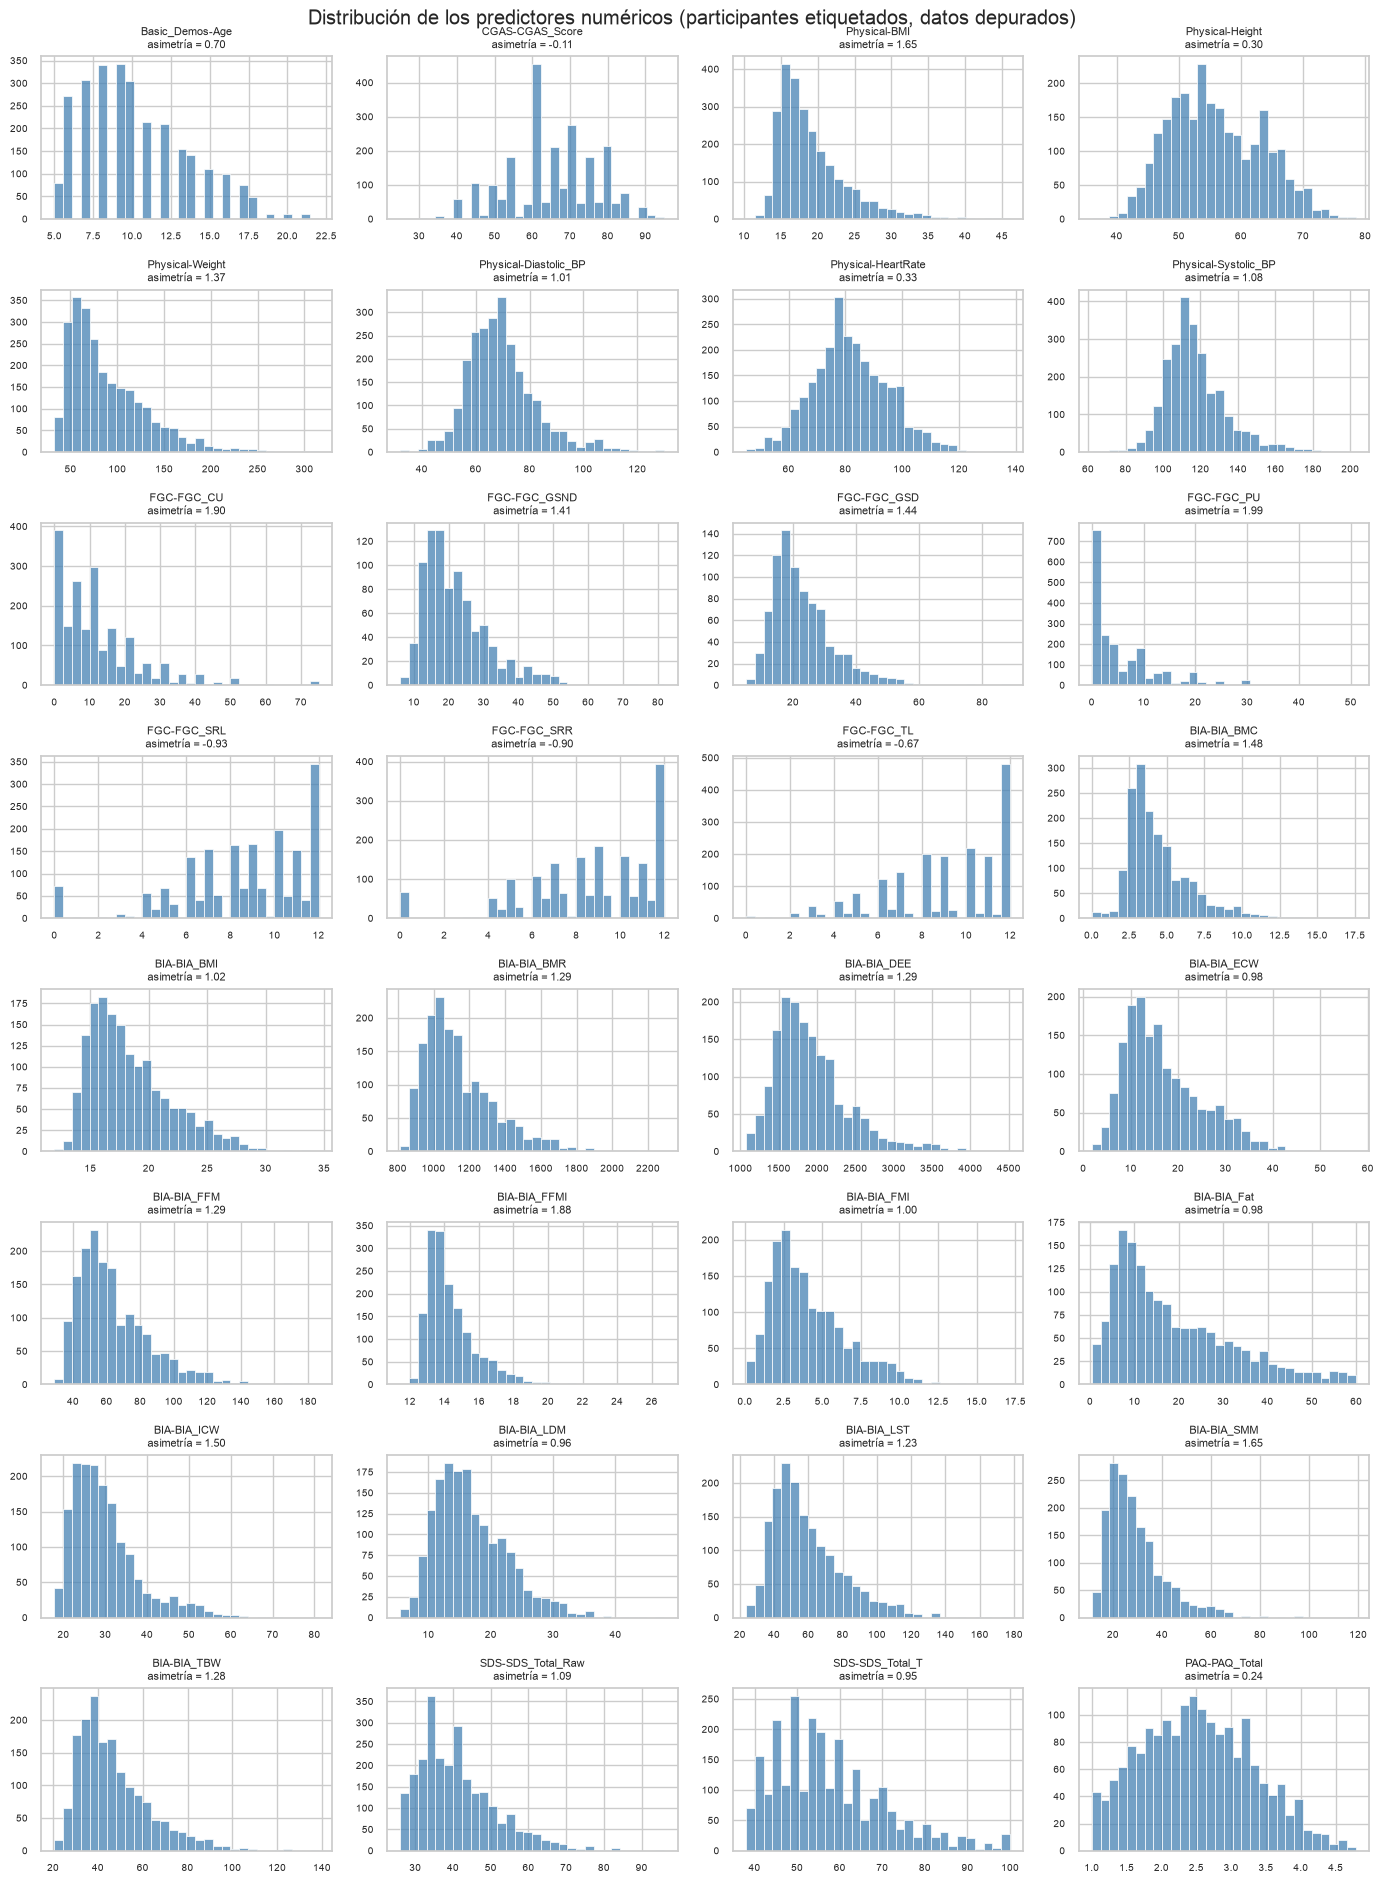

In [43]:
n_columnas_figura = 4
n_filas_figura = -(-len(numericas) // n_columnas_figura)

fig, axes = plt.subplots(
    n_filas_figura,
    n_columnas_figura,
    figsize=(14, 2.4 * n_filas_figura),
    squeeze=False,
)
for ax, columna in zip(axes.flat, numericas):
    sns.histplot(analisis[columna].dropna(), bins=30, color="steelblue", ax=ax)
    ax.set_title(
        f"{columna}\nasimetría = {resumen_numericas.at[columna, 'asimetría']:.2f}",
        fontsize=8,
    )
    ax.set(xlabel="", ylabel="")
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(numericas) :]:
    ax.set_visible(False)

fig.suptitle("Distribución de los predictores numéricos (participantes etiquetados, datos depurados)")
fig.tight_layout()
save_figure(fig, "distribuciones_numericas", FIGURAS_EDA)
plt.show()

In [44]:
no_negativas = [c for c in numericas if (analisis[c].dropna() >= 0).all()]

comparacion_asimetria = pd.DataFrame(
    {
        "asimetría original": analisis[numericas].skew(),
        "asimetría con log(1 + x)": np.log1p(analisis[no_negativas]).skew(),
    }
)
comparacion_asimetria.index.name = "variable"

print(f"Variables con |asimetría| > 1: {(comparacion_asimetria['asimetría original'].abs() > 1).sum()}")
print(
    "Variables con |asimetría| > 1 tras log(1 + x): "
    f"{(comparacion_asimetria['asimetría con log(1 + x)'].abs() > 1).sum()}"
)

comparacion_asimetria[comparacion_asimetria["asimetría original"].abs() > 0.5].round(2).sort_values(
    "asimetría original", key=abs, ascending=False
)

Variables con |asimetría| > 1: 19
Variables con |asimetría| > 1 tras log(1 + x): 4


,asimetría original,asimetría con log(1 + x)
variable,,
FGC-FGC_PU,1.99,0.12
FGC-FGC_CU,1.90,-0.64
BIA-BIA_FFMI,1.88,1.40
BIA-BIA_SMM,1.65,0.51
Physical-BMI,1.65,0.94
BIA-BIA_ICW,1.50,0.75
BIA-BIA_BMC,1.48,0.01
FGC-FGC_GSD,1.44,0.15
FGC-FGC_GSND,1.41,0.29


In [45]:
registros_numericas = analisis[numericas].notna().sum()

piso_techo = pd.DataFrame(
    {
        "registros": registros_numericas,
        "valor mínimo": analisis[numericas].min(),
        "% en el mínimo": 100 * analisis[numericas].eq(analisis[numericas].min()).sum() / registros_numericas,
        "valor máximo": analisis[numericas].max(),
        "% en el máximo": 100 * analisis[numericas].eq(analisis[numericas].max()).sum() / registros_numericas,
    }
).round(2)
piso_techo.index.name = "variable"

piso_techo[(piso_techo["% en el mínimo"] > 5) | (piso_techo["% en el máximo"] > 5)].sort_values(
    "% en el mínimo", ascending=False
)

,registros,valor mínimo,% en el mínimo,valor máximo,% en el máximo
variable,,,,,
FGC-FGC_PU,1909,0.0,32.79,51.0,0.05
FGC-FGC_CU,1919,0.0,14.85,75.0,0.52
FGC-FGC_SRL,1911,0.0,3.77,12.0,18.00
FGC-FGC_SRR,1913,0.0,3.55,12.0,20.65
FGC-FGC_TL,1919,0.0,0.31,12.0,25.12


In [46]:
def etiqueta_categoria(valor: object) -> str:
    """Convierte códigos numéricos como 1.0 en texto entero y deja los demás como texto."""
    return str(int(valor)) if isinstance(valor, float) and valor.is_integer() else str(valor)


filas = []
for columna in categoricas:
    frecuencias = analisis[columna].value_counts(normalize=True)
    filas.append(
        {
            "variable": columna,
            "tipo": tipo_predictor[columna],
            "categorías observadas": analisis[columna].nunique(),
            "categoría más frecuente": etiqueta_categoria(frecuencias.index[0]),
            "% de la más frecuente": round(100 * frecuencias.iloc[0], 1),
            "% de la menos frecuente": round(100 * frecuencias.iloc[-1], 1),
            "% faltante": round(100 * analisis[columna].isna().mean(), 1),
        }
    )

pd.DataFrame(filas).set_index("variable")

,tipo,categorías observadas,categoría más frecuente,% de la más frecuente,% de la menos frecuente,% faltante
variable,,,,,,
Basic_Demos-Enroll_Season,nominal,4,Spring,26.8,23.8,0.0
Basic_Demos-Sex,binaria,2,0,63.6,36.4,0.0
FGC-FGC_CU_Zone,binaria,2,1,52.5,47.5,31.1
FGC-FGC_GSND_Zone,ordinal,3,2,59.1,11.5,68.4
FGC-FGC_GSD_Zone,ordinal,3,2,60.8,14.0,68.4
FGC-FGC_PU_Zone,binaria,2,0,65.3,34.7,31.5
FGC-FGC_SRL_Zone,binaria,2,1,63.7,36.3,31.4
FGC-FGC_SRR_Zone,binaria,2,1,63.4,36.6,31.3
FGC-FGC_TL_Zone,binaria,2,1,77.3,22.7,31.1


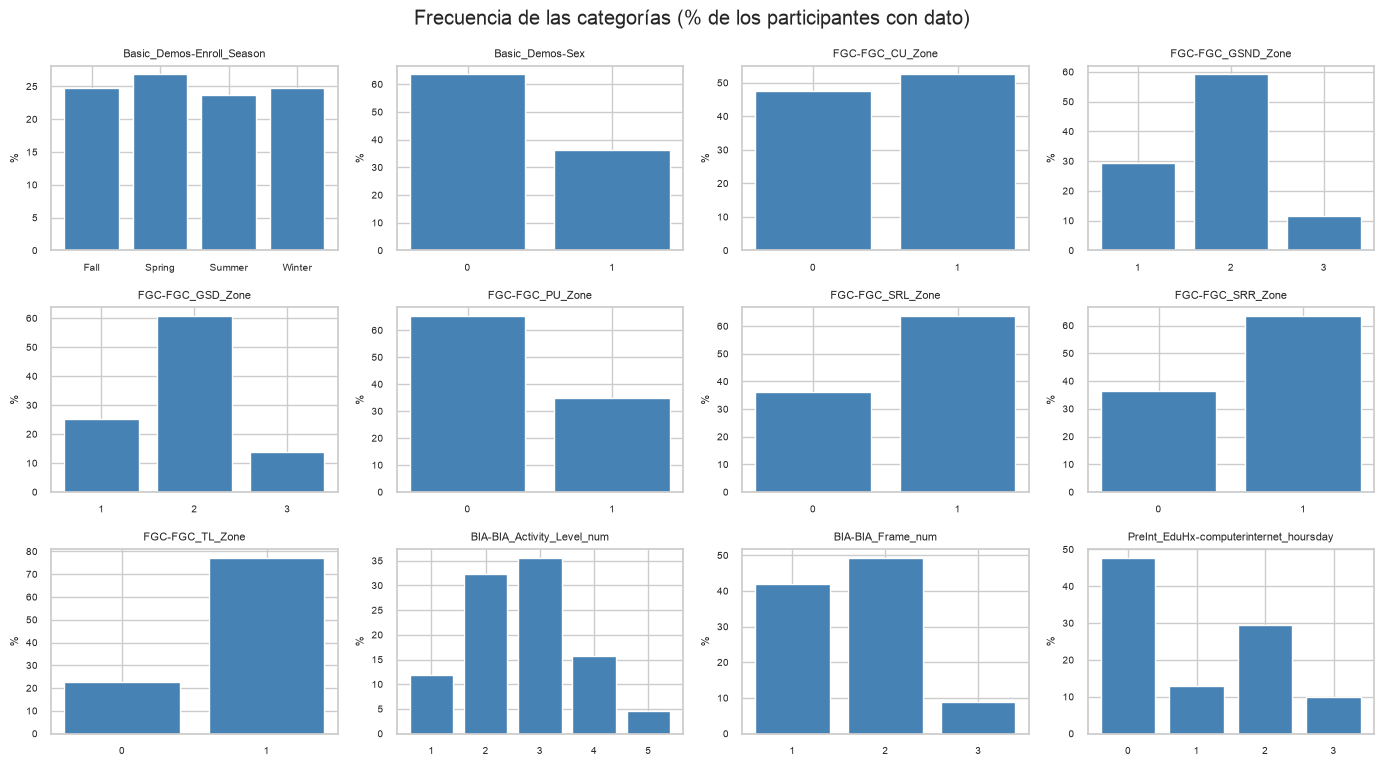

In [47]:
n_columnas_figura = 4
n_filas_figura = -(-len(categoricas) // n_columnas_figura)

fig, axes = plt.subplots(
    n_filas_figura,
    n_columnas_figura,
    figsize=(14, 2.6 * n_filas_figura),
    squeeze=False,
)
for ax, columna in zip(axes.flat, categoricas):
    frecuencias = 100 * analisis[columna].value_counts(normalize=True).sort_index()
    ax.bar([etiqueta_categoria(v) for v in frecuencias.index], frecuencias.to_numpy(), color="steelblue")
    ax.set_title(columna, fontsize=8)
    ax.set_ylabel("%", fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(categoricas) :]:
    ax.set_visible(False)

fig.suptitle("Frecuencia de las categorías (% de los participantes con dato)")
fig.tight_layout()
save_figure(fig, "frecuencias_categoricas", FIGURAS_EDA)
plt.show()

### Conclusión

#### Predictores analizados

| Grupo | Numéricas | Binarias | Ordinales | Nominales | Total |
|---|---|---|---|---|---|
| Demográfico | 1 | 1 | 0 | 1 | 3 |
| Físico | 28 | 5 | 4 | 0 | 37 |
| Complementario | 3 | 0 | 1 | 0 | 4 |
| Total | 32 | 6 | 5 | 1 | 44 |

#### Escalas y asimetría de las variables numéricas

Las escalas son muy heterogéneas: van de 1 a 5 en el PAQ hasta más de 4.000 kcal en el gasto energético diario. Esto confirma la necesidad de estandarizar las variables en los modelos sensibles a la escala.

De las 32 variables numéricas, 19 tienen una asimetría mayor que 1 en valor absoluto, todas con cola hacia la derecha:

- **Conteos de FitnessGram:** flexiones de brazos (1,99) y abdominales (1,90).
- **Composición corporal:** las masas, el agua corporal y los índices de bioimpedancia (entre 1,0 y 1,9), el peso (1,37) y el IMC (1,65).
- **Otras:** la fuerza de agarre (1,4), las presiones arteriales (1,0 a 1,1) y el puntaje bruto del SDS (1,09).

La transformación log(1 + x) reduce a 4 las variables con asimetría mayor que 1, pero no sirve para todas. Corrige las colas derechas, pero empeora las variables con acumulación en el máximo: la flexibilidad izquierda y la derecha pasan de −0,9 a −3,0, y el levantamiento de tronco de −0,7 a −1,9. Por ello, una misma transformación fija no es adecuada para todas las variables.

#### Efectos de piso y de techo

| Variable | En el valor mínimo (%) | En el valor máximo (%) |
|---|---|---|
| Flexiones de brazos | 32,8 (0 repeticiones) | 0,1 |
| Abdominales | 14,9 (0 repeticiones) | 0,5 |
| Flexibilidad izquierda | 3,8 (0 pulgadas) | 18,0 (12 pulgadas) |
| Flexibilidad derecha | 3,6 (0 pulgadas) | 20,7 (12 pulgadas) |
| Levantamiento de tronco | 0,3 (0 pulgadas) | 25,1 (12 pulgadas) |

Un tercio de los participantes no completa ninguna flexión de brazos. En la flexibilidad y el levantamiento de tronco, entre el 18 % y el 25 % de los participantes queda en el máximo del protocolo, en parte por el recorte aplicado en la sección anterior. En ambas pruebas de flexibilidad, los valores iguales a 0 aparecen separados del resto, sin mediciones entre 0 y 3 pulgadas, lo que podría indicar pruebas no completadas; se conservan porque los datos no permiten confirmarlo. Estos efectos limitan la capacidad de esas variables para diferenciar a los participantes en los extremos.

#### Otras características de las distribuciones

- **Edad:** discreta y con cola derecha (0,70); pocos participantes tienen más de 17 años.
- **CGAS:** se concentra en múltiplos de 5 y de 10, como es habitual en una escala que asigna un clínico.
- **Estatura, frecuencia cardiaca, PAQ y CGAS:** son aproximadamente simétricas (asimetría menor que 0,35 en valor absoluto).

#### Variables categóricas

Ninguna categoría es tan escasa como para requerir agruparla con otra. Las menos frecuentes son el nivel de actividad 5 de la bioimpedancia (4,6 %), la contextura grande (8,7 %), el uso de internet de más de tres horas diarias (9,9 %) y la zona de fuerza de agarre más alta (11,5 % en la mano no dominante). El 63,6 % de los participantes son hombres, y la temporada de inscripción está balanceada (entre 23,8 % y 26,8 %). Las variables categóricas de la bioimpedancia tienen ahora un 39,8 % de faltantes, por la anulación de registros de la sección anterior.

#### Decisiones

| Decisión | Motivo |
|---|---|
| En la regresión logística y las máquinas de soporte vectorial, transformar las variables numéricas con Yeo-Johnson y estandarizarlas, ajustando ambas operaciones en cada partición de entrenamiento | Hay asimetría en ambas direcciones y valores iguales a cero; Yeo-Johnson ajusta la transformación a cada variable, a diferencia de un logaritmo fijo |
| No transformar las variables en los modelos de ensamble basados en árboles | Sus particiones no dependen de la escala ni de la forma de la distribución |
| Conservar las variables ordinales como códigos enteros y codificar con variables binarias solo la temporada de inscripción | Ninguna categoría es tan escasa como para requerir agruparla |
| Conservar los valores en el piso y en el techo | Son resultados posibles de las pruebas |

## 7. Redundancia entre predictores

Esta sección identifica los predictores que aportan información casi idéntica. La redundancia afecta de forma distinta a cada familia de modelos: en la regresión logística, la colinealidad vuelve inestables los coeficientes; en los modelos de ensamble, reparte la importancia entre variables equivalentes, lo que dificulta la interpretación con valores SHAP. Como el análisis usa solo la relación entre predictores y no el SII, las decisiones que se tomen aquí no introducen fuga de información.

Se emplean tres medidas de asociación, porque cada una detecta un tipo distinto de dependencia:

- **Correlación de Pearson.** Mide la asociación lineal entre dos variables numéricas, $r = \operatorname{cov}(X, Y) / (\sigma_X \sigma_Y)$. Es la que corresponde a la colinealidad que afecta a los modelos lineales, pero es sensible a la asimetría y a los valores atípicos.
- **Correlación de Spearman.** Es la correlación de Pearson calculada sobre los rangos, por lo que mide asociación monótona y es robusta a la asimetría y a los atípicos. Se usa como medida principal de redundancia y se calcula también para las variables binarias y ordinales.
- **Información mutua.** Mide cualquier dependencia, no solo la monótona: $I(X; Y) = \sum p(x, y) \log \frac{p(x, y)}{p(x)\,p(y)}$, que vale cero solo si las variables son independientes. Se estima con el método de vecinos más cercanos de scikit-learn, sobre las variables numéricas y promediando tres semillas. Como la información mutua no tiene un máximo fijo, se transforma en el coeficiente informacional de correlación $r_I = \sqrt{1 - e^{-2I}}$, que va de 0 a 1 y coincide con el valor absoluto de la correlación de Pearson cuando la relación es lineal y normal. Así se puede comparar directamente con las otras dos medidas.

Las diferencias entre las medidas son informativas: si Spearman supera claramente a Pearson, la relación es monótona pero no lineal o la distorsionan valores extremos; si el coeficiente informacional supera claramente al valor absoluto de Spearman, existe una dependencia que no es monótona.

Cada par se calcula con los participantes que tienen ambos datos, y solo cuando hay al menos 100. Un par se considera redundante cuando el valor absoluto de la correlación de Spearman es al menos 0,9. Para identificar bloques de variables redundantes, los predictores se agrupan con un agrupamiento jerárquico de enlace promedio sobre la distancia $1 - |\rho|$.

Además de las medidas de asociación, se verifican las relaciones aritméticas entre variables de la bioimpedancia, se examinan los pares que miden lo mismo por construcción (el valor de cada prueba de FitnessGram y su zona, los lados izquierdo y derecho, el puntaje bruto y el puntaje T del SDS, y el IMC de las dos fuentes) y se cuantifica la asociación de cada predictor con la edad y el sexo.

In [48]:
UMBRAL_REDUNDANCIA = 0.9
MIN_PARES = 100

ordinales_binarias = [c for c in categoricas if tipo_predictor[c] in ("binaria", "ordinal")]
variables_redundancia = [*numericas, *ordinales_binarias]
datos_redundancia = analisis[variables_redundancia].astype(float)

presentes = datos_redundancia.notna().astype(int)
participantes_par = presentes.T @ presentes

spearman = datos_redundancia.corr(method="spearman", min_periods=MIN_PARES)
pearson = datos_redundancia[numericas].corr(method="pearson", min_periods=MIN_PARES)


def a_pares(matriz: pd.DataFrame, nombre: str) -> pd.Series:
    """Convierte una matriz simétrica en una serie con un valor por par de variables."""
    triangulo = np.triu(np.ones(matriz.shape, dtype=bool), k=1)
    return (
        matriz.where(triangulo)
        .stack()
        .dropna()
        .rename_axis(["variable 1", "variable 2"])
        .rename(nombre)
    )


participantes_por_par = a_pares(participantes_par, "participantes")

pd.Series(
    {
        "variables numéricas": len(numericas),
        "variables binarias y ordinales": len(ordinales_binarias),
        "pares de variables": len(participantes_por_par),
        f"pares con al menos {MIN_PARES} participantes": (participantes_por_par >= MIN_PARES).sum(),
        "mínimo de participantes en un par": int(participantes_por_par.min()),
        "mediana de participantes por par": int(participantes_por_par.median()),
    },
    name="valor",
)

variables numéricas                       32
variables binarias y ordinales            11
pares de variables                       903
pares con al menos 100 participantes     903
mínimo de participantes en un par        602
mediana de participantes por par        1620
Name: valor, dtype: int64

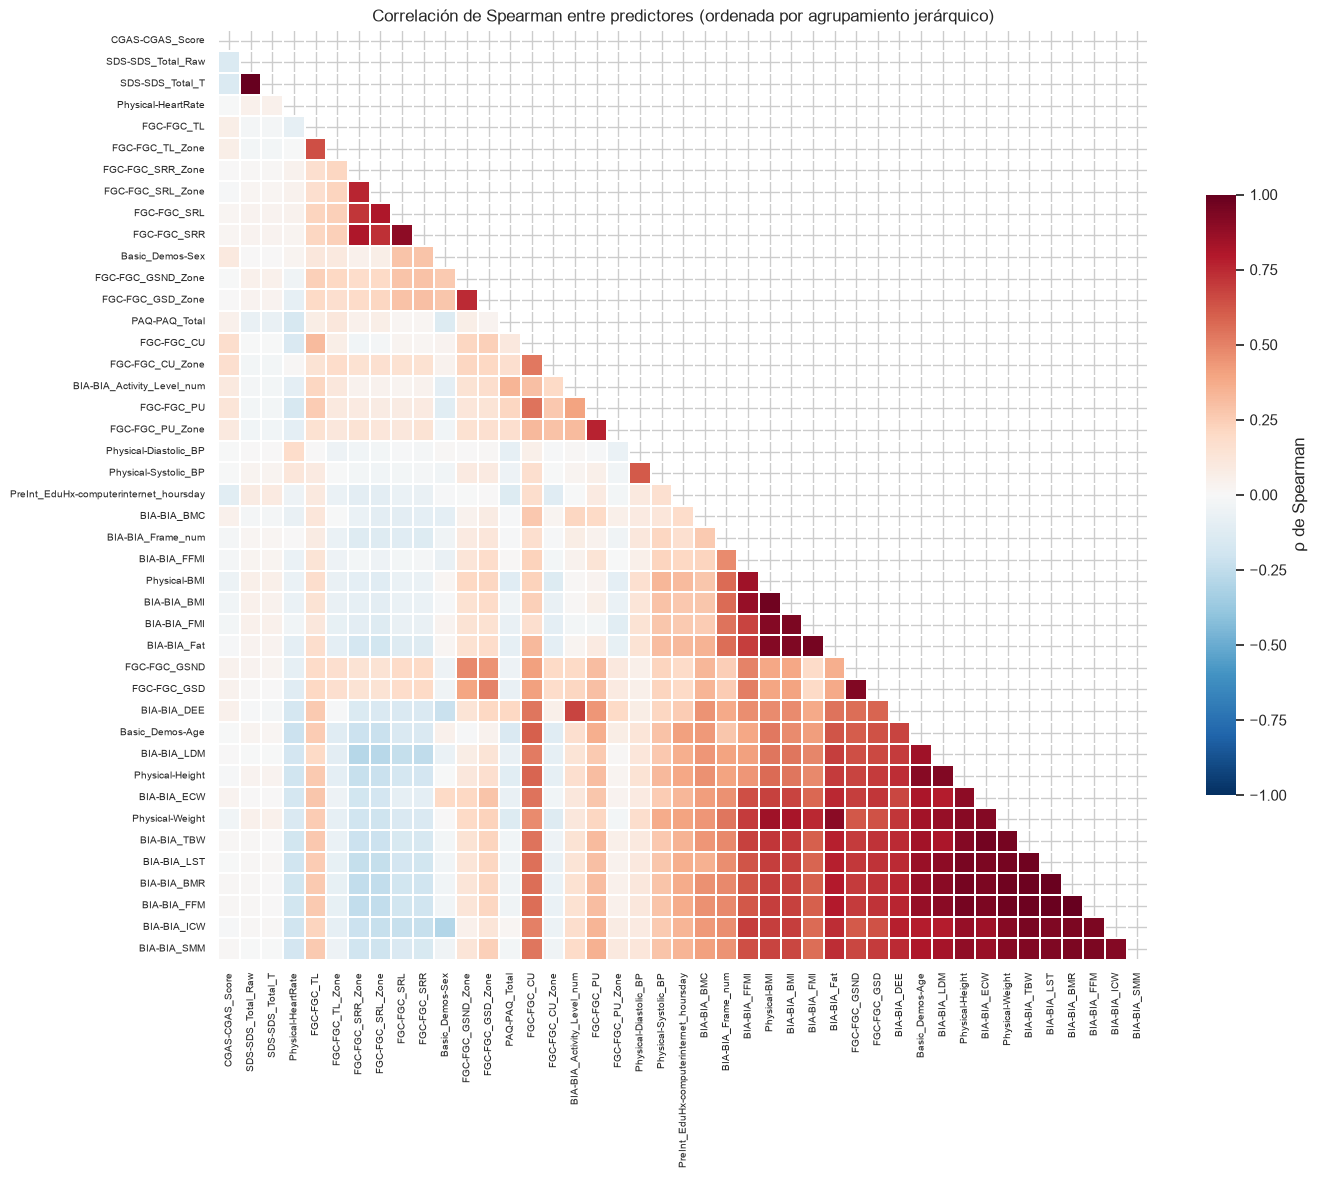

In [49]:
matriz_distancia = (1 - spearman.abs()).fillna(1).clip(lower=0).to_numpy(copy=True)
matriz_distancia = (matriz_distancia + matriz_distancia.T) / 2
np.fill_diagonal(matriz_distancia, 0)

enlace = linkage(squareform(matriz_distancia, checks=False), method="average")
orden = spearman.index[leaves_list(enlace)]

spearman_ordenada = spearman.loc[orden, orden]
triangulo_superior = np.triu(np.ones(spearman_ordenada.shape, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(
    spearman_ordenada,
    mask=triangulo_superior,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "ρ de Spearman", "shrink": 0.6},
    ax=ax,
)
ax.set(
    xlabel="",
    ylabel="",
    title="Correlación de Spearman entre predictores (ordenada por agrupamiento jerárquico)",
)
ax.tick_params(labelsize=7)
save_figure(fig, "correlacion_spearman", FIGURAS_EDA)
plt.show()

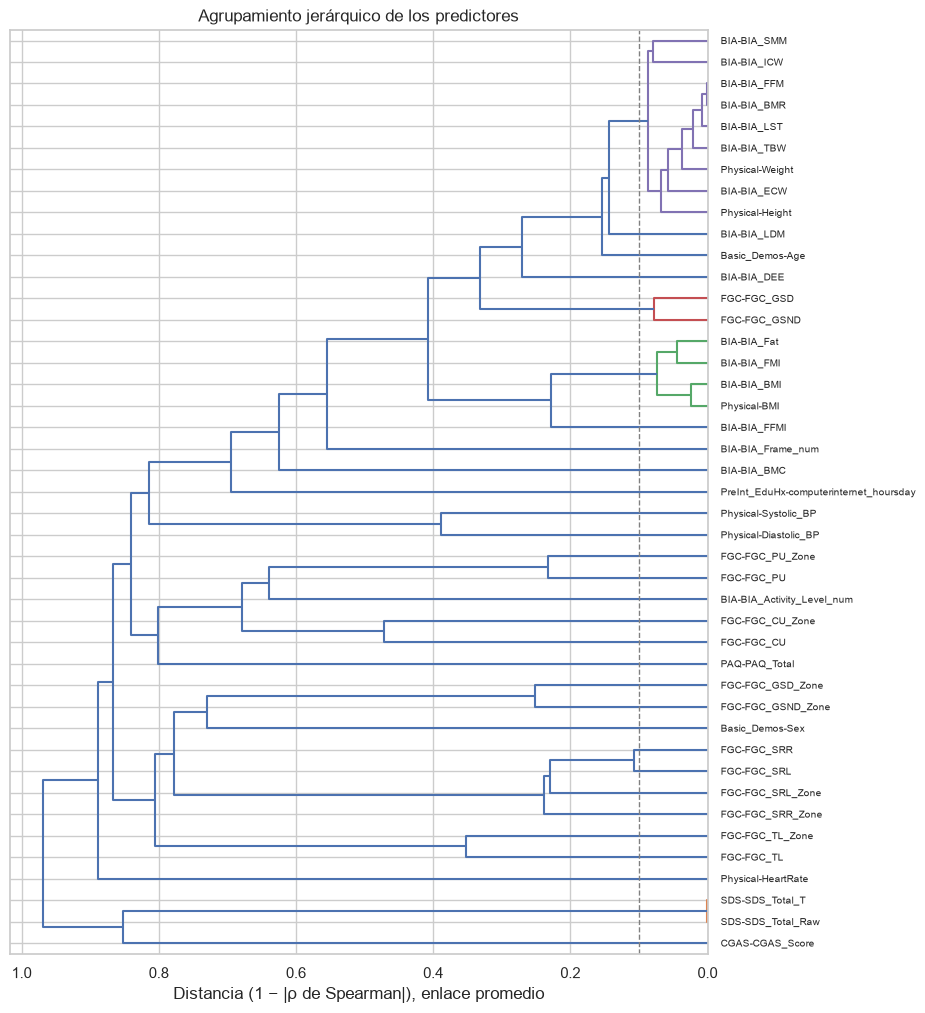

Bloques con al menos dos variables: 4


,variables,|ρ| medio,|ρ| mínimo,miembros
bloque,,,,
1,9,0.939,0.844,"Physical-Height, Physical-Weight, BIA-BIA_BMR, BIA-BIA_ECW, BIA-BIA_FFM, BIA-BIA_ICW, BIA-BIA_LST, BIA-BIA_SMM, BIA-BIA_TBW"
2,4,0.940,0.914,"Physical-BMI, BIA-BIA_BMI, BIA-BIA_FMI, BIA-BIA_Fat"
3,2,1.000,1.000,"SDS-SDS_Total_Raw, SDS-SDS_Total_T"
4,2,0.922,0.922,"FGC-FGC_GSND, FGC-FGC_GSD"


In [50]:
fig, ax = plt.subplots(figsize=(9, 12))
dendrogram(
    enlace,
    labels=list(spearman.index),
    orientation="left",
    color_threshold=1 - UMBRAL_REDUNDANCIA,
    leaf_font_size=7,
    ax=ax,
)
ax.axvline(1 - UMBRAL_REDUNDANCIA, color="gray", linestyle="--", linewidth=1)
ax.set(
    xlabel="Distancia (1 − |ρ de Spearman|), enlace promedio",
    title="Agrupamiento jerárquico de los predictores",
)
save_figure(fig, "dendrograma_predictores", FIGURAS_EDA)
plt.show()

etiquetas_bloque = pd.Series(
    fcluster(enlace, t=1 - UMBRAL_REDUNDANCIA, criterion="distance"), index=spearman.index
)

filas = []
for _, miembros in etiquetas_bloque.groupby(etiquetas_bloque):
    variables = list(miembros.index)
    if len(variables) < 2:
        continue
    bloque = spearman.loc[variables, variables].abs().to_numpy()
    fuera_diagonal = bloque[~np.eye(len(variables), dtype=bool)]
    filas.append(
        {
            "variables": len(variables),
            "|ρ| medio": round(float(np.nanmean(fuera_diagonal)), 3),
            "|ρ| mínimo": round(float(np.nanmin(fuera_diagonal)), 3),
            "miembros": ", ".join(variables),
        }
    )

bloques_redundantes = (
    pd.DataFrame(filas, columns=["variables", "|ρ| medio", "|ρ| mínimo", "miembros"])
    .sort_values("variables", ascending=False)
    .reset_index(drop=True)
)
bloques_redundantes.index = bloques_redundantes.index + 1
bloques_redundantes.index.name = "bloque"

print(f"Bloques con al menos dos variables: {len(bloques_redundantes)}")
with pd.option_context("display.max_colwidth", None):
    display(bloques_redundantes)

In [51]:
pares = pd.concat(
    [
        a_pares(spearman, "Spearman"),
        a_pares(pearson, "Pearson"),
        participantes_por_par,
    ],
    axis="columns",
)

pares_redundantes = pares[pares["Spearman"].abs() >= UMBRAL_REDUNDANCIA].sort_values(
    "Spearman", key=abs, ascending=False
)

print(f"Pares con |ρ de Spearman| ≥ {UMBRAL_REDUNDANCIA}: {len(pares_redundantes)}")
pares_redundantes.round(3).astype({"participantes": int})

Pares con |ρ de Spearman| ≥ 0.9: 44


Spearman  Pearson  participantes
variable 1        variable 2                                       
BIA-BIA_BMR       BIA-BIA_FFM         1.000    1.000           1647
SDS-SDS_Total_Raw SDS-SDS_Total_T     1.000    0.998           2521
BIA-BIA_BMR       BIA-BIA_LST         0.992    0.995           1647
BIA-BIA_FFM       BIA-BIA_LST         0.992    0.995           1647
                  BIA-BIA_TBW         0.981    0.991           1647
BIA-BIA_BMR       BIA-BIA_TBW         0.981    0.991           1647
Physical-BMI      BIA-BIA_BMI         0.976    0.971           1641
BIA-BIA_LST       BIA-BIA_TBW         0.976    0.988           1647
Physical-Weight   BIA-BIA_BMR         0.969    0.954           1642
                  BIA-BIA_FFM         0.969    0.954           1642
BIA-BIA_ECW       BIA-BIA_TBW         0.966    0.971           1647
Physical-Height   BIA-BIA_BMR         0.961    0.927           1642
                  BIA-BIA_FFM         0.961    0.927           1642
Physical-Weight   BIA-BIA_LST         0.959    0.949           1642
BIA-BIA_FMI       BIA-BIA_Fat         0.955    0.928           1647
Physical-Weight   BIA-BIA_TBW         0.954    0.942           1642
BIA-BIA_ICW       BIA-BIA_TBW         0.953    0.969           1647
Physical-Height   BIA-BIA_LST         0.950    0.922           1642
BIA-BIA_ECW       BIA-BIA_FFM         0.945    0.960           1647
BIA-BIA_BMR       BIA-BIA_ECW         0.945    0.960           1647
BIA-BIA_BMI       BIA-BIA_FMI         0.943    0.940           1647
BIA-BIA_FFM       BIA-BIA_SMM         0.940    0.943           1647
BIA-BIA_BMR       BIA-BIA_SMM         0.940    0.943           1647
BIA-BIA_ECW       BIA-BIA_LST         0.939    0.959           1647
BIA-BIA_BMR       BIA-BIA_ICW         0.938    0.961           1647
BIA-BIA_FFM       BIA-BIA_ICW         0.938    0.961           1647
BIA-BIA_LST       BIA-BIA_SMM         0.935    0.940           1647
BIA-BIA_ICW       BIA-BIA_LST         0.934    0.957           1647
BIA-BIA_BMI       BIA-BIA_Fat         0.931    0.916           1647
BIA-BIA_SMM       BIA-BIA_TBW         0.928    0.938           1647
Physical-Height   BIA-BIA_LDM         0.926    0.917           1642
FGC-FGC_GSND      FGC-FGC_GSD         0.922    0.930            867
BIA-BIA_ICW       BIA-BIA_SMM         0.921    0.941           1647
Physical-Weight   BIA-BIA_ECW         0.920    0.930           1642
Physical-Height   BIA-BIA_TBW         0.920    0.898           1642
Physical-BMI      BIA-BIA_FMI         0.920    0.910           1641
                  BIA-BIA_Fat         0.914    0.903           1641
Basic_Demos-Age   Physical-Height     0.913    0.889           2530
Physical-Weight   BIA-BIA_SMM         0.912    0.891           1642
                  BIA-BIA_ICW         0.909    0.897           1642
Physical-Height   Physical-Weight     0.908    0.844           2520
Physical-Weight   BIA-BIA_Fat         0.905    0.881           1642
BIA-BIA_BMR       BIA-BIA_LDM         0.905    0.929           1647
BIA-BIA_FFM       BIA-BIA_LDM         0.905    0.929           1647

Pares de variables numéricas: 496
Pares con diferencia absoluta mayor que 0,1: 36
Pares con diferencia absoluta mayor que 0,2: 1


Spearman  Pearson  participantes  \
variable 1      variable 2                                      
Physical-Height BIA-BIA_BMC     0.457    0.248           1642   
Basic_Demos-Age BIA-BIA_BMC     0.433    0.234           1647   
BIA-BIA_BMC     BIA-BIA_TBW     0.440    0.248           1647   
                BIA-BIA_BMR     0.455    0.268           1647   
                BIA-BIA_FFM     0.455    0.268           1647   
                BIA-BIA_ECW     0.414    0.228           1647   
Physical-Weight BIA-BIA_BMC     0.440    0.256           1642   
BIA-BIA_BMC     BIA-BIA_LST     0.356    0.172           1647   
                BIA-BIA_ICW     0.434    0.253           1647   
                BIA-BIA_SMM     0.411    0.237           1647   
                BIA-BIA_DEE     0.452    0.284           1647   
BIA-BIA_FFMI    BIA-BIA_LDM     0.411    0.576           1647   
BIA-BIA_BMC     BIA-BIA_Fat     0.352    0.193           1647   
BIA-BIA_FMI     BIA-BIA_ICW     0.567    0.415           1647   
BIA-BIA_BMC     BIA-BIA_LDM     0.442    0.296           1647   

                             |Spearman| − |Pearson|  
variable 1      variable 2                           
Physical-Height BIA-BIA_BMC                   0.208  
Basic_Demos-Age BIA-BIA_BMC                   0.200  
BIA-BIA_BMC     BIA-BIA_TBW                   0.192  
                BIA-BIA_BMR                   0.187  
                BIA-BIA_FFM                   0.187  
                BIA-BIA_ECW                   0.186  
Physical-Weight BIA-BIA_BMC                   0.185  
BIA-BIA_BMC     BIA-BIA_LST                   0.185  
                BIA-BIA_ICW                   0.181  
                BIA-BIA_SMM                   0.173  
                BIA-BIA_DEE                   0.168  
BIA-BIA_FFMI    BIA-BIA_LDM                  -0.165  
BIA-BIA_BMC     BIA-BIA_Fat                   0.158  
BIA-BIA_FMI     BIA-BIA_ICW                   0.152  
BIA-BIA_BMC     BIA-BIA_LDM                   0.146

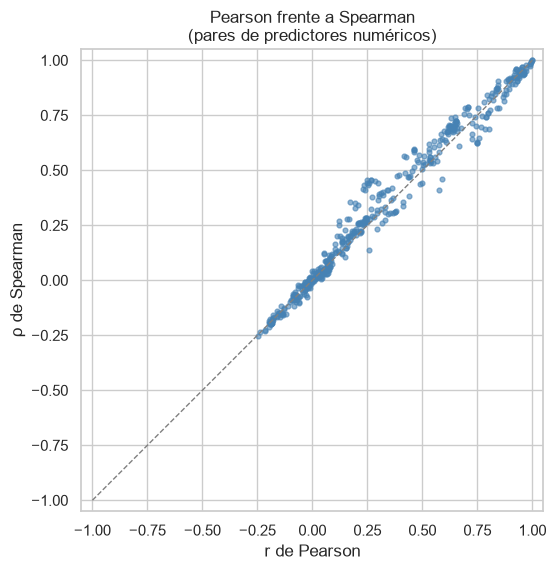

In [52]:
pares_numericos = pares.dropna(subset=["Pearson"]).copy()
pares_numericos["|Spearman| − |Pearson|"] = (
    pares_numericos["Spearman"].abs() - pares_numericos["Pearson"].abs()
)
diferencia = pares_numericos["|Spearman| − |Pearson|"]

print(f"Pares de variables numéricas: {len(pares_numericos)}")
print(f"Pares con diferencia absoluta mayor que 0,1: {(diferencia.abs() > 0.1).sum()}")
print(f"Pares con diferencia absoluta mayor que 0,2: {(diferencia.abs() > 0.2).sum()}")
display(
    pares_numericos.loc[diferencia.abs().nlargest(15).index]
    .round(3)
    .astype({"participantes": int})
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pares_numericos["Pearson"], pares_numericos["Spearman"], s=12, alpha=0.6, color="steelblue")
ax.plot([-1, 1], [-1, 1], color="gray", linestyle="--", linewidth=1)
ax.set(
    xlabel="r de Pearson",
    ylabel="ρ de Spearman",
    title="Pearson frente a Spearman\n(pares de predictores numéricos)",
    xlim=(-1.05, 1.05),
    ylim=(-1.05, 1.05),
)
ax.set_aspect("equal")
save_figure(fig, "pearson_vs_spearman", FIGURAS_EDA)
plt.show()

In [53]:
SEMILLAS_IM = [RANDOM_SEED + i for i in range(3)]


def informacion_mutua(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    """Estima la información mutua en nats con el método de vecinos más cercanos.

    Usa solo los participantes con ambos datos y devuelve la media y la desviación
    estándar de las estimaciones obtenidas con cada semilla.
    """
    completos = pd.concat([x, y], axis="columns").dropna()
    if len(completos) < MIN_PARES:
        return np.nan, np.nan
    estimaciones = [
        mutual_info_regression(
            completos.iloc[:, [0]].to_numpy(),
            completos.iloc[:, 1].to_numpy(),
            n_neighbors=3,
            random_state=semilla,
        )[0]
        for semilla in SEMILLAS_IM
    ]
    return float(np.mean(estimaciones)), float(np.std(estimaciones))


filas = []
for variable_1, variable_2 in itertools.combinations(numericas, 2):
    media, desviacion = informacion_mutua(analisis[variable_1], analisis[variable_2])
    filas.append(
        {
            "variable 1": variable_1,
            "variable 2": variable_2,
            "información mutua (nats)": media,
            "desviación entre semillas": desviacion,
        }
    )

im_pares = pd.DataFrame(filas).set_index(["variable 1", "variable 2"])
im_pares["coeficiente informacional"] = np.sqrt(
    1 - np.exp(-2 * im_pares["información mutua (nats)"].clip(lower=0))
)
im_pares = im_pares.join(pares[["Spearman", "Pearson", "participantes"]])
im_pares["coeficiente − |Spearman|"] = im_pares["coeficiente informacional"] - im_pares["Spearman"].abs()

pd.Series(
    {
        "pares estimados": im_pares["información mutua (nats)"].notna().sum(),
        "desviación media entre semillas (nats)": round(im_pares["desviación entre semillas"].mean(), 4),
        f"pares con coeficiente informacional ≥ {UMBRAL_REDUNDANCIA}": (
            im_pares["coeficiente informacional"] >= UMBRAL_REDUNDANCIA
        ).sum(),
        f"pares con |ρ de Spearman| ≥ {UMBRAL_REDUNDANCIA}": (
            im_pares["Spearman"].abs() >= UMBRAL_REDUNDANCIA
        ).sum(),
        "pares con coeficiente mayor que |Spearman| en más de 0,1": (
            im_pares["coeficiente − |Spearman|"] > 0.1
        ).sum(),
    },
    name="valor",
)

pares estimados                                             496.0000
desviación media entre semillas (nats)                        0.0022
pares con coeficiente informacional ≥ 0.9                    59.0000
pares con |ρ de Spearman| ≥ 0.9                              44.0000
pares con coeficiente mayor que |Spearman| en más de 0,1    104.0000
Name: valor, dtype: float64

coeficiente informacional  Spearman  Pearson  \
variable 1      variable 2                                                      
BIA-BIA_BMC     BIA-BIA_LST                          0.920     0.356    0.172   
                BIA-BIA_BMR                          0.921     0.455    0.268   
                BIA-BIA_FFM                          0.921     0.455    0.268   
                BIA-BIA_ICW                          0.899     0.434    0.253   
                BIA-BIA_TBW                          0.902     0.440    0.248   
Physical-Height BIA-BIA_BMC                          0.900     0.457    0.248   
BIA-BIA_BMC     BIA-BIA_ECW                          0.847     0.414    0.228   
                BIA-BIA_SMM                          0.833     0.411    0.237   
                BIA-BIA_DEE                          0.842     0.452    0.284   
                BIA-BIA_LDM                          0.828     0.442    0.296   
Physical-Weight BIA-BIA_BMC                          0.803     0.440    0.256   
Basic_Demos-Age BIA-BIA_BMC                          0.741     0.433    0.234   
BIA-BIA_LST     SDS-SDS_Total_T                      0.311     0.012    0.008   
FGC-FGC_GSND    BIA-BIA_BMC                          0.614     0.329    0.195   
BIA-BIA_BMC     BIA-BIA_FFMI                         0.503     0.224    0.188   

                                 coeficiente − |Spearman|  participantes  
variable 1      variable 2                                                
BIA-BIA_BMC     BIA-BIA_LST                         0.564           1647  
                BIA-BIA_BMR                         0.466           1647  
                BIA-BIA_FFM                         0.466           1647  
                BIA-BIA_ICW                         0.465           1647  
                BIA-BIA_TBW                         0.462           1647  
Physical-Height BIA-BIA_BMC                         0.443           1642  
BIA-BIA_BMC     BIA-BIA_ECW                         0.433           1647  
                BIA-BIA_SMM                         0.423           1647  
                BIA-BIA_DEE                         0.390           1647  
                BIA-BIA_LDM                         0.386           1647  
Physical-Weight BIA-BIA_BMC                         0.363           1642  
Basic_Demos-Age BIA-BIA_BMC                         0.308           1647  
BIA-BIA_LST     SDS-SDS_Total_T                     0.299           1500  
FGC-FGC_GSND    BIA-BIA_BMC                         0.284            604  
BIA-BIA_BMC     BIA-BIA_FFMI                        0.279           1647

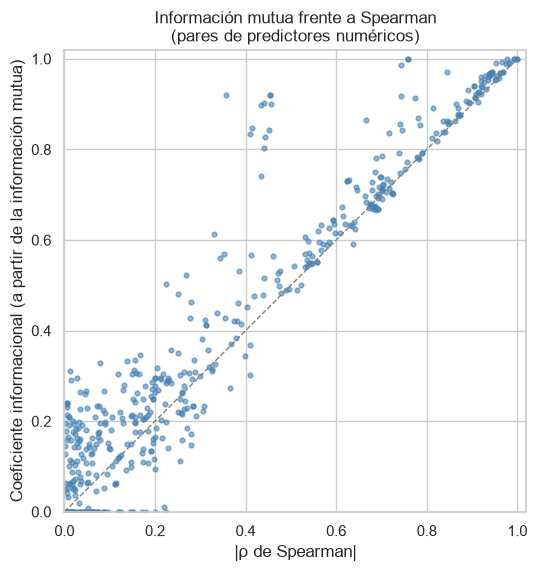

In [54]:
diferencia_im = im_pares["coeficiente − |Spearman|"]
display(
    im_pares.loc[
        diferencia_im.nlargest(15).index,
        ["coeficiente informacional", "Spearman", "Pearson", "coeficiente − |Spearman|", "participantes"],
    ]
    .round(3)
    .astype({"participantes": int})
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    im_pares["Spearman"].abs(),
    im_pares["coeficiente informacional"],
    s=12,
    alpha=0.6,
    color="steelblue",
)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set(
    xlabel="|ρ de Spearman|",
    ylabel="Coeficiente informacional (a partir de la información mutua)",
    title="Información mutua frente a Spearman\n(pares de predictores numéricos)",
    xlim=(0, 1.02),
    ylim=(0, 1.02),
)
ax.set_aspect("equal")
save_figure(fig, "informacion_mutua_vs_spearman", FIGURAS_EDA)
plt.show()

In [55]:
redundantes_tres_medidas = (
    pares_redundantes.join(im_pares[["coeficiente informacional"]], how="left")
    .assign(
        **{
            "redundante según Pearson": lambda d: d["Pearson"].abs() >= UMBRAL_REDUNDANCIA,
            "redundante según información mutua": lambda d: (
                d["coeficiente informacional"] >= UMBRAL_REDUNDANCIA
            ),
        }
    )
)

display(
    pd.Series(
        {
            f"pares con |ρ de Spearman| ≥ {UMBRAL_REDUNDANCIA}": len(redundantes_tres_medidas),
            "de ellos, también con |r de Pearson| ≥ 0,9": int(
                redundantes_tres_medidas["redundante según Pearson"].sum()
            ),
            "de ellos, también con coeficiente informacional ≥ 0,9": int(
                redundantes_tres_medidas["redundante según información mutua"].sum()
            ),
            "pares con coeficiente informacional ≥ 0,9 que no superan el umbral de Spearman": int(
                (
                    (im_pares["coeficiente informacional"] >= UMBRAL_REDUNDANCIA)
                    & (im_pares["Spearman"].abs() < UMBRAL_REDUNDANCIA)
                ).sum()
            ),
        },
        name="pares",
    )
)

redundantes_tres_medidas[
    ["Spearman", "Pearson", "coeficiente informacional", "participantes"]
].round(3).astype({"participantes": int})

pares con |ρ de Spearman| ≥ 0.9                                                   44
de ellos, también con |r de Pearson| ≥ 0,9                                        38
de ellos, también con coeficiente informacional ≥ 0,9                             44
pares con coeficiente informacional ≥ 0,9 que no superan el umbral de Spearman    15
Name: pares, dtype: int64

Spearman  Pearson  \
variable 1        variable 2                           
BIA-BIA_BMR       BIA-BIA_FFM         1.000    1.000   
SDS-SDS_Total_Raw SDS-SDS_Total_T     1.000    0.998   
BIA-BIA_BMR       BIA-BIA_LST         0.992    0.995   
BIA-BIA_FFM       BIA-BIA_LST         0.992    0.995   
                  BIA-BIA_TBW         0.981    0.991   
BIA-BIA_BMR       BIA-BIA_TBW         0.981    0.991   
Physical-BMI      BIA-BIA_BMI         0.976    0.971   
BIA-BIA_LST       BIA-BIA_TBW         0.976    0.988   
Physical-Weight   BIA-BIA_BMR         0.969    0.954   
                  BIA-BIA_FFM         0.969    0.954   
BIA-BIA_ECW       BIA-BIA_TBW         0.966    0.971   
Physical-Height   BIA-BIA_BMR         0.961    0.927   
                  BIA-BIA_FFM         0.961    0.927   
Physical-Weight   BIA-BIA_LST         0.959    0.949   
BIA-BIA_FMI       BIA-BIA_Fat         0.955    0.928   
Physical-Weight   BIA-BIA_TBW         0.954    0.942   
BIA-BIA_ICW       BIA-BIA_TBW         0.953    0.969   
Physical-Height   BIA-BIA_LST         0.950    0.922   
BIA-BIA_ECW       BIA-BIA_FFM         0.945    0.960   
BIA-BIA_BMR       BIA-BIA_ECW         0.945    0.960   
BIA-BIA_BMI       BIA-BIA_FMI         0.943    0.940   
BIA-BIA_FFM       BIA-BIA_SMM         0.940    0.943   
BIA-BIA_BMR       BIA-BIA_SMM         0.940    0.943   
BIA-BIA_ECW       BIA-BIA_LST         0.939    0.959   
BIA-BIA_BMR       BIA-BIA_ICW         0.938    0.961   
BIA-BIA_FFM       BIA-BIA_ICW         0.938    0.961   
BIA-BIA_LST       BIA-BIA_SMM         0.935    0.940   
BIA-BIA_ICW       BIA-BIA_LST         0.934    0.957   
BIA-BIA_BMI       BIA-BIA_Fat         0.931    0.916   
BIA-BIA_SMM       BIA-BIA_TBW         0.928    0.938   
Physical-Height   BIA-BIA_LDM         0.926    0.917   
FGC-FGC_GSND      FGC-FGC_GSD         0.922    0.930   
BIA-BIA_ICW       BIA-BIA_SMM         0.921    0.941   
Physical-Weight   BIA-BIA_ECW         0.920    0.930   
Physical-Height   BIA-BIA_TBW         0.920    0.898   
Physical-BMI      BIA-BIA_FMI         0.920    0.910   
                  BIA-BIA_Fat         0.914    0.903   
Basic_Demos-Age   Physical-Height     0.913    0.889   
Physical-Weight   BIA-BIA_SMM         0.912    0.891   
                  BIA-BIA_ICW         0.909    0.897   
Physical-Height   Physical-Weight     0.908    0.844   
Physical-Weight   BIA-BIA_Fat         0.905    0.881   
BIA-BIA_BMR       BIA-BIA_LDM         0.905    0.929   
BIA-BIA_FFM       BIA-BIA_LDM         0.905    0.929   

                                   coeficiente informacional  participantes  
variable 1        variable 2                                                 
BIA-BIA_BMR       BIA-BIA_FFM                          1.000           1647  
SDS-SDS_Total_Raw SDS-SDS_Total_T                      1.000           2521  
BIA-BIA_BMR       BIA-BIA_LST                          0.999           1647  
BIA-BIA_FFM       BIA-BIA_LST                          0.999           1647  
                  BIA-BIA_TBW                          0.991           1647  
BIA-BIA_BMR       BIA-BIA_TBW                          0.991           1647  
Physical-BMI      BIA-BIA_BMI                          1.000           1641  
BIA-BIA_LST       BIA-BIA_TBW                          0.989           1647  
Physical-Weight   BIA-BIA_BMR                          0.971           1642  
                  BIA-BIA_FFM                          0.971           1642  
BIA-BIA_ECW       BIA-BIA_TBW                          0.992           1647  
Physical-Height   BIA-BIA_BMR                          0.969           1642  
                  BIA-BIA_FFM                          0.969           1642  
Physical-Weight   BIA-BIA_LST                          0.958           1642  
BIA-BIA_FMI       BIA-BIA_Fat                          0.962           1647  
Physical-Weight   BIA-BIA_TBW                          0.954           1642  
BIA-BIA_ICW       BIA-BIA_TBW                         

In [56]:
solo_informacion_mutua = im_pares[
    (im_pares["coeficiente informacional"] >= UMBRAL_REDUNDANCIA)
    & (im_pares["Spearman"].abs() < UMBRAL_REDUNDANCIA)
].sort_values("coeficiente informacional", ascending=False)

print(
    "Pares con coeficiente informacional ≥ 0,9 y |ρ de Spearman| < 0,9: "
    f"{len(solo_informacion_mutua)}"
)
solo_informacion_mutua[
    ["coeficiente informacional", "Spearman", "Pearson", "participantes"]
].round(3).astype({"participantes": int})

Pares con coeficiente informacional ≥ 0,9 y |ρ de Spearman| < 0,9: 15


coeficiente informacional  Spearman  Pearson  \
variable 1      variable 2                                                  
BIA-BIA_BMR     BIA-BIA_DEE                      0.999     0.759    0.798   
BIA-BIA_DEE     BIA-BIA_FFM                      0.999     0.759    0.798   
                BIA-BIA_LST                      0.987     0.744    0.787   
BIA-BIA_ECW     BIA-BIA_ICW                      0.971     0.844    0.881   
BIA-BIA_LDM     BIA-BIA_LST                      0.931     0.891    0.920   
BIA-BIA_BMC     BIA-BIA_BMR                      0.921     0.455    0.268   
                BIA-BIA_FFM                      0.921     0.455    0.268   
                BIA-BIA_LST                      0.920     0.356    0.172   
BIA-BIA_DEE     BIA-BIA_TBW                      0.918     0.743    0.791   
                BIA-BIA_ICW                      0.914     0.774    0.809   
Physical-Height BIA-BIA_SMM                      0.906     0.887    0.844   
FGC-FGC_SRL     FGC-FGC_SRR                      0.906     0.893    0.907   
Physical-Height BIA-BIA_ECW                      0.903     0.894    0.895   
BIA-BIA_BMC     BIA-BIA_TBW                      0.902     0.440    0.248   
BIA-BIA_ECW     BIA-BIA_SMM                      0.900     0.864    0.878   

                             participantes  
variable 1      variable 2                  
BIA-BIA_BMR     BIA-BIA_DEE           1647  
BIA-BIA_DEE     BIA-BIA_FFM           1647  
                BIA-BIA_LST           1647  
BIA-BIA_ECW     BIA-BIA_ICW           1647  
BIA-BIA_LDM     BIA-BIA_LST           1647  
BIA-BIA_BMC     BIA-BIA_BMR           1647  
                BIA-BIA_FFM           1647  
                BIA-BIA_LST           1647  
BIA-BIA_DEE     BIA-BIA_TBW           1647  
                BIA-BIA_ICW           1647  
Physical-Height BIA-BIA_SMM           1642  
FGC-FGC_SRL     FGC-FGC_SRR           1911  
Physical-Height BIA-BIA_ECW           1642  
BIA-BIA_BMC     BIA-BIA_TBW           1647  
BIA-BIA_ECW     BIA-BIA_SMM           1647

In [57]:
def valor_par(tabla: pd.DataFrame, columna: str, variable_1: str, variable_2: str) -> float:
    """Busca el valor de un par en una tabla indexada por pares, en cualquier orden."""
    for clave in ((variable_1, variable_2), (variable_2, variable_1)):
        if clave in tabla.index:
            return tabla.at[clave, columna]
    return np.nan


filas = []
for bloque, miembros in bloques_redundantes["miembros"].items():
    variables = miembros.split(", ")
    combinaciones = list(itertools.combinations(variables, 2))
    medidas = {
        "Spearman": [abs(valor_par(pares, "Spearman", a, b)) for a, b in combinaciones],
        "Pearson": [abs(valor_par(pares, "Pearson", a, b)) for a, b in combinaciones],
        "información mutua": [
            valor_par(im_pares, "coeficiente informacional", a, b) for a, b in combinaciones
        ],
    }
    fila = {"bloque": bloque, "variables": len(variables), "pares": len(combinaciones)}
    for medida, valores in medidas.items():
        fila[f"{medida}: media"] = np.nanmean(valores)
        fila[f"{medida}: mínimo"] = np.nanmin(valores)
    filas.append(fila)

pd.DataFrame(filas).set_index("bloque").round(3)

,variables,pares,Spearman: media,Spearman: mínimo,Pearson: media,Pearson: mínimo,información mutua: media,información mutua: mínimo
bloque,,,,,,,,
1,9,36,0.939,0.844,0.937,0.844,0.958,0.874
2,4,6,0.940,0.914,0.928,0.903,0.958,0.926
3,2,1,1.000,1.000,0.998,0.998,1.000,1.000
4,2,1,0.922,0.922,0.930,0.930,0.937,0.937


In [58]:
IDENTIDADES_BIA = {
    "Agua corporal total = intracelular + extracelular": (
        "BIA-BIA_TBW",
        lambda d: d["BIA-BIA_ICW"] + d["BIA-BIA_ECW"],
    ),
    "IMC = índice de masa libre de grasa + índice de masa grasa": (
        "BIA-BIA_BMI",
        lambda d: d["BIA-BIA_FFMI"] + d["BIA-BIA_FMI"],
    ),
    "Tejido blando magro = masa libre de grasa − contenido mineral óseo": (
        "BIA-BIA_LST",
        lambda d: d["BIA-BIA_FFM"] - d["BIA-BIA_BMC"],
    ),
    "Masa seca magra = masa libre de grasa − agua corporal total": (
        "BIA-BIA_LDM",
        lambda d: d["BIA-BIA_FFM"] - d["BIA-BIA_TBW"],
    ),
    "Grasa corporal (%) = 100 × índice de masa grasa / IMC": (
        "BIA-BIA_Fat",
        lambda d: 100 * d["BIA-BIA_FMI"] / d["BIA-BIA_BMI"],
    ),
}

filas = []
for relacion, (columna, calculo) in IDENTIDADES_BIA.items():
    calculado = calculo(analisis)
    validos = analisis[columna].notna() & calculado.notna()
    diferencia_absoluta = (analisis.loc[validos, columna] - calculado[validos]).abs()
    diferencia_relativa = diferencia_absoluta / analisis.loc[validos, columna].abs()
    filas.append(
        {
            "relación": relacion,
            "participantes": int(validos.sum()),
            "diferencia absoluta mediana": diferencia_absoluta.median(),
            "diferencia absoluta máxima": diferencia_absoluta.max(),
            "% con diferencia menor que 1 % del valor": 100 * (diferencia_relativa < 0.01).mean(),
        }
    )

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(filas).set_index("relación").round(3))

,participantes,diferencia absoluta mediana,diferencia absoluta máxima,% con diferencia menor que 1 % del valor
relación,,,,
Agua corporal total = intracelular + extracelular,1647,0.000,0.001,100.000
IMC = índice de masa libre de grasa + índice de masa grasa,1647,0.000,0.000,100.000
Tejido blando magro = masa libre de grasa − contenido mineral óseo,1647,0.000,0.001,100.000
Masa seca magra = masa libre de grasa − agua corporal total,1647,0.000,0.001,100.000
Grasa corporal (%) = 100 × índice de masa grasa / IMC,1647,5.344,32.342,1.275


In [59]:
bia_valida = analisis.dropna(subset=["BIA-BIA_FFM"])

pendiente, intercepto = np.polyfit(bia_valida["BIA-BIA_FFM"], bia_valida["BIA-BIA_BMR"], deg=1)
residuo_bmr = (
    bia_valida["BIA-BIA_BMR"] - (intercepto + pendiente * bia_valida["BIA-BIA_FFM"])
).abs()

ffmi_calculado = 703 * bia_valida["BIA-BIA_FFM"] / bia_valida["Physical-Height"] ** 2
diferencia_ffmi = (bia_valida["BIA-BIA_FFMI"] - ffmi_calculado).abs().dropna()

sds = analisis[["SDS-SDS_Total_Raw", "SDS-SDS_Total_T"]].dropna()
t_por_bruto = sds.groupby("SDS-SDS_Total_Raw")["SDS-SDS_Total_T"].nunique()

with pd.option_context("display.max_colwidth", None):
    display(
        pd.DataFrame(
            {
                "participantes": [len(bia_valida), len(diferencia_ffmi), len(sds)],
                "resultado": [
                    f"tasa metabólica = {intercepto:.2f} + {pendiente:.4f} × masa libre de grasa; "
                    f"diferencia absoluta máxima = {residuo_bmr.max():.3f} kcal",
                    f"{100 * (diferencia_ffmi < 0.1).mean():.1f} % con diferencia menor que 0,1; "
                    f"diferencia máxima = {diferencia_ffmi.max():.2f}",
                    f"{(t_por_bruto > 1).sum()} de {len(t_por_bruto)} puntajes brutos "
                    "tienen más de un puntaje T",
                ],
            },
            index=pd.Index(
                [
                    "Tasa metabólica basal frente a masa libre de grasa (recta ajustada)",
                    "Índice de masa libre de grasa = 703 × masa libre de grasa / estatura² (medidas físicas)",
                    "SDS: puntaje T frente a puntaje bruto",
                ],
                name="relación",
            ),
        )
    )

,participantes,resultado
relación,,
Tasa metabólica basal frente a masa libre de grasa (recta ajustada),1647,tasa metabólica = 542.06 + 9.3885 × masa libre de grasa; diferencia absoluta máxima = 0.009 kcal
Índice de masa libre de grasa = 703 × masa libre de grasa / estatura² (medidas físicas),1642,"92.8 % con diferencia menor que 0,1; diferencia máxima = 10.46"
SDS: puntaje T frente a puntaje bruto,2521,0 de 57 puntajes brutos tienen más de un puntaje T


In [60]:
factor_actividad = (bia_valida["BIA-BIA_DEE"] / bia_valida["BIA-BIA_BMR"]).round(2)


def moda(serie: pd.Series) -> float:
    """Devuelve el valor más frecuente de una serie."""
    return serie.mode().iloc[0]


resumen_factor = factor_actividad.groupby(
    [
        bia_valida["BIA-BIA_Activity_Level_num"].astype(int).rename("nivel de actividad"),
        bia_valida["Basic_Demos-Sex"].map(SEXO).rename("sexo"),
    ]
).agg(
    participantes="count",
    factores_distintos="nunique",
    factor_mas_frecuente=moda,
)
resumen_factor["% con el factor más frecuente"] = (
    100
    * factor_actividad.groupby(
        [bia_valida["BIA-BIA_Activity_Level_num"].astype(int), bia_valida["Basic_Demos-Sex"].map(SEXO)]
    )
    .apply(lambda serie: (serie == moda(serie)).mean())
    .to_numpy()
).round(1)
resumen_factor.rename(
    columns={"factores_distintos": "factores distintos", "factor_mas_frecuente": "factor más frecuente"}
)

participantes  factores distintos  \
nivel de actividad sexo                                           
1                  femenino              86                   1   
                   masculino            108                   1   
2                  femenino             204                   2   
                   masculino            328                   2   
3                  femenino             203                   2   
                   masculino            384                   1   
4                  femenino              66                   2   
                   masculino            193                   1   
5                  femenino              27                   1   
                   masculino             48                   1   

                              factor más frecuente  \
nivel de actividad sexo                              
1                  femenino                    1.3   
                   masculino                   1.3   
2                  femenino                    1.5   
                   masculino                   1.6   
3                  femenino                    1.6   
                   masculino                   1.7   
4                  femenino                    1.9   
                   masculino                   2.1   
5                  femenino                    2.2   
                   masculino                   2.4   

                              % con el factor más frecuente  
nivel de actividad sexo                                      
1                  femenino                           100.0  
                   masculino                          100.0  
2                  femenino                            98.0  
                   masculino                           99.7  
3                  femenino                            98.5  
                   masculino                          100.0  
4                  femenino                            98.5  
                   masculino                          100.0  
5                  femenino                           100.0  
                   masculino                          100.0

participantes con bioimpedancia válida                          1647.0000
razón mediana (contenido mineral óseo / masa libre de grasa)       0.0607
participantes a más de 30 % de la razón mediana                  359.0000
% a más de 30 % de la razón mediana                               21.8000
Name: valor, dtype: float64

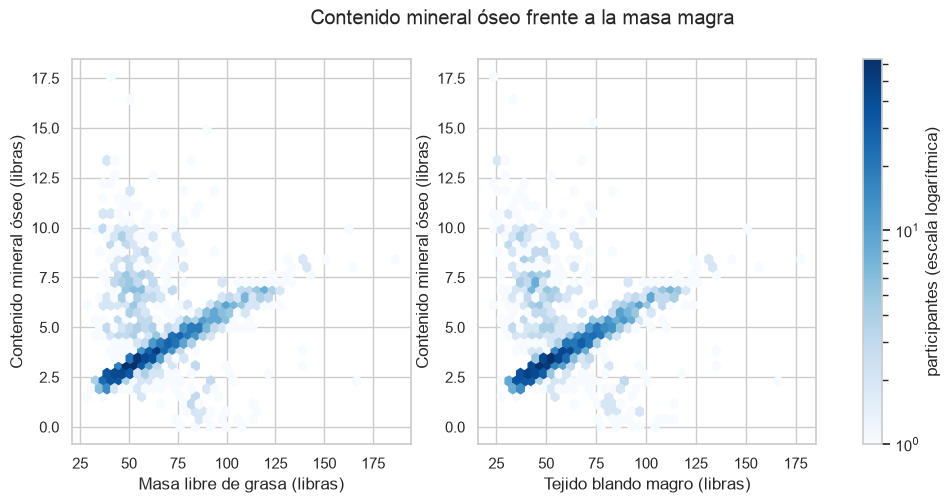

In [61]:
razon_bmc = bia_valida["BIA-BIA_BMC"] / bia_valida["BIA-BIA_FFM"]
razon_mediana = razon_bmc.median()
fuera_de_patron = (razon_bmc - razon_mediana).abs() > 0.3 * razon_mediana

display(
    pd.Series(
        {
            "participantes con bioimpedancia válida": len(razon_bmc),
            "razón mediana (contenido mineral óseo / masa libre de grasa)": round(razon_mediana, 4),
            "participantes a más de 30 % de la razón mediana": int(fuera_de_patron.sum()),
            "% a más de 30 % de la razón mediana": round(100 * fuera_de_patron.mean(), 1),
        },
        name="valor",
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, columna, etiqueta in [
    (axes[0], "BIA-BIA_FFM", "Masa libre de grasa (libras)"),
    (axes[1], "BIA-BIA_LST", "Tejido blando magro (libras)"),
]:
    hb = ax.hexbin(
        bia_valida[columna],
        bia_valida["BIA-BIA_BMC"],
        gridsize=40,
        mincnt=1,
        bins="log",
        cmap="Blues",
    )
    ax.set(xlabel=etiqueta, ylabel="Contenido mineral óseo (libras)")
fig.colorbar(hb, ax=axes, label="participantes (escala logarítmica)")
fig.suptitle("Contenido mineral óseo frente a la masa magra")
save_figure(fig, "contenido_mineral_oseo", FIGURAS_EDA)
plt.show()

In [62]:
PARES_CONSTRUCCION = [
    ("FGC-FGC_CU", "FGC-FGC_CU_Zone", "Abdominales: valor y zona"),
    ("FGC-FGC_PU", "FGC-FGC_PU_Zone", "Flexiones de brazos: valor y zona"),
    ("FGC-FGC_SRL", "FGC-FGC_SRL_Zone", "Flexibilidad izquierda: valor y zona"),
    ("FGC-FGC_SRR", "FGC-FGC_SRR_Zone", "Flexibilidad derecha: valor y zona"),
    ("FGC-FGC_TL", "FGC-FGC_TL_Zone", "Levantamiento de tronco: valor y zona"),
    ("FGC-FGC_GSD", "FGC-FGC_GSD_Zone", "Fuerza de agarre dominante: valor y zona"),
    ("FGC-FGC_GSND", "FGC-FGC_GSND_Zone", "Fuerza de agarre no dominante: valor y zona"),
    ("FGC-FGC_SRL", "FGC-FGC_SRR", "Flexibilidad: izquierda y derecha"),
    ("FGC-FGC_GSD", "FGC-FGC_GSND", "Fuerza de agarre: dominante y no dominante"),
    ("SDS-SDS_Total_Raw", "SDS-SDS_Total_T", "SDS: puntaje bruto y puntaje T"),
    ("Physical-BMI", "BIA-BIA_BMI", "IMC: medidas físicas y bioimpedancia"),
]

pd.DataFrame(
    [
        {
            "par": descripcion,
            "participantes": int(participantes_par.at[a, b]),
            "Spearman": spearman.at[a, b],
            "Pearson": pearson.at[a, b] if a in pearson.index and b in pearson.index else np.nan,
        }
        for a, b, descripcion in PARES_CONSTRUCCION
    ]
).set_index("par").round(3)

,participantes,Spearman,Pearson
par,,,
Abdominales: valor y zona,1884,0.529,NaN
Flexiones de brazos: valor y zona,1874,0.768,NaN
Flexibilidad izquierda: valor y zona,1877,0.809,NaN
Flexibilidad derecha: valor y zona,1879,0.805,NaN
Levantamiento de tronco: valor y zona,1885,0.648,NaN
Fuerza de agarre dominante: valor y zona,862,0.495,NaN
Fuerza de agarre no dominante: valor y zona,860,0.484,NaN
Flexibilidad: izquierda y derecha,1911,0.893,0.907
Fuerza de agarre: dominante y no dominante,867,0.922,0.930


Predictores con |ρ con la edad| ≥ 0,7: 10 de 41


,grupo,ρ con la edad,ρ con el sexo
variable,,,
Physical-Height,físico,0.913,-0.002
BIA-BIA_FFM,físico,0.874,-0.038
BIA-BIA_BMR,físico,0.874,-0.038
BIA-BIA_LST,físico,0.861,-0.037
BIA-BIA_LDM,físico,0.848,-0.068
Physical-Weight,físico,0.841,0.007
BIA-BIA_TBW,físico,0.836,-0.026
BIA-BIA_ECW,físico,0.820,0.197
BIA-BIA_SMM,físico,0.812,-0.041


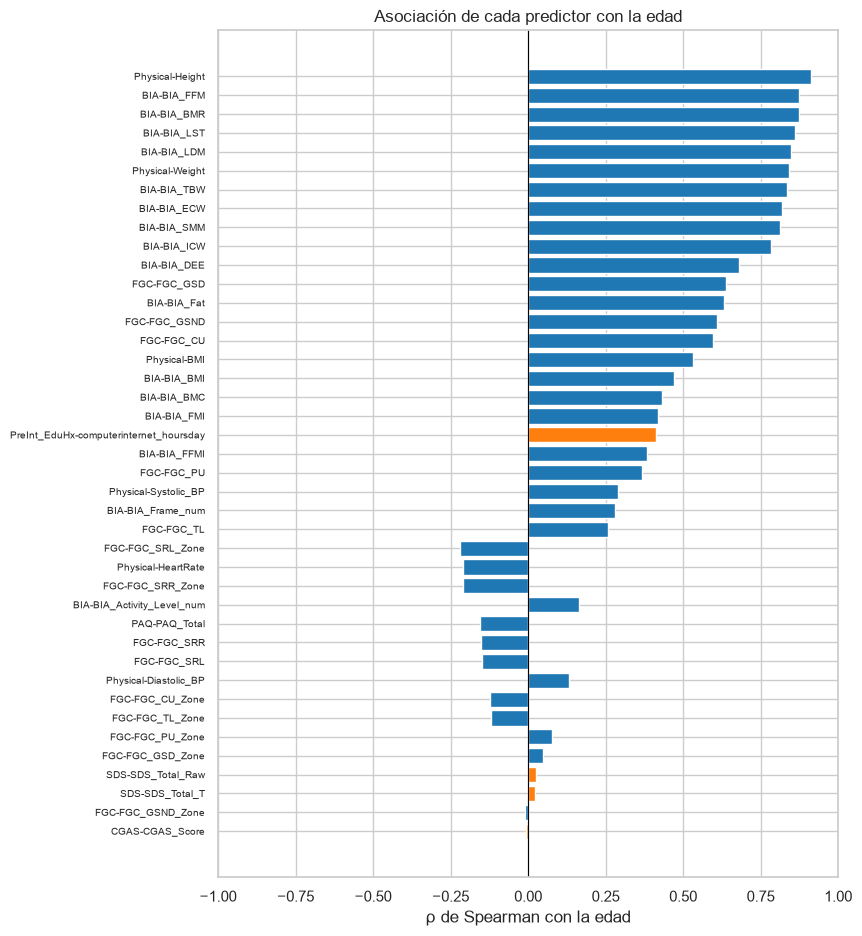

In [63]:
asociacion_demografica = pd.DataFrame(
    {
        "grupo": [grupo_predictor[c] for c in spearman.index],
        "ρ con la edad": spearman["Basic_Demos-Age"],
        "ρ con el sexo": spearman["Basic_Demos-Sex"],
    },
    index=spearman.index,
).drop(index=["Basic_Demos-Age", "Basic_Demos-Sex"])
asociacion_demografica.index.name = "variable"
asociacion_demografica = asociacion_demografica.sort_values("ρ con la edad", key=abs, ascending=False)

print(
    "Predictores con |ρ con la edad| ≥ 0,7: "
    f"{(asociacion_demografica['ρ con la edad'].abs() >= 0.7).sum()} de {len(asociacion_demografica)}"
)
display(asociacion_demografica.round(3))

fig, ax = plt.subplots(figsize=(8, 11))
colores_grupo = {"físico": "tab:blue", "complementario": "tab:orange", "demográfico": "tab:gray"}
ax.barh(
    asociacion_demografica.index[::-1],
    asociacion_demografica["ρ con la edad"][::-1],
    color=[colores_grupo[g] for g in asociacion_demografica["grupo"][::-1]],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    xlabel="ρ de Spearman con la edad",
    ylabel="",
    title="Asociación de cada predictor con la edad",
    xlim=(-1, 1),
)
ax.tick_params(axis="y", labelsize=7)
save_figure(fig, "correlacion_con_edad", FIGURAS_EDA)
plt.show()

### Conclusión

#### Bloques de variables redundantes

Las 43 variables analizadas (32 numéricas y 11 binarias u ordinales) se pueden comparar en todos sus pares, con un mínimo de 602 participantes por par. El agrupamiento jerárquico identifica cuatro bloques de variables redundantes, y las tres medidas de asociación coinciden en todos ellos:

| Bloque | Variables | Contenido | Spearman (media) | Pearson (media) | Coeficiente informacional (media) |
|---|---|---|---|---|---|
| Tamaño corporal | 9 | Estatura, peso, masa libre de grasa, tejido blando magro, agua corporal total, intracelular y extracelular, masa muscular esquelética y tasa metabólica basal | 0,94 | 0,94 | 0,96 |
| Adiposidad | 4 | IMC de las medidas físicas y de la bioimpedancia, índice de masa grasa y porcentaje de grasa corporal | 0,94 | 0,93 | 0,96 |
| SDS | 2 | Puntaje bruto y puntaje T | 1,00 | 1,00 | 1,00 |
| Fuerza de agarre | 2 | Mano dominante y no dominante | 0,92 | 0,93 | 0,94 |

Las correlaciones se reportan en valor absoluto. Incluso los pares menos relacionados de cada bloque mantienen valores altos: en el bloque de tamaño corporal, el mínimo es 0,84 tanto en Spearman como en Pearson y 0,87 en el coeficiente informacional, y en el de adiposidad, 0,91, 0,90 y 0,93, respectivamente.

#### Qué aporta cada medida

| Criterio | Pares |
|---|---|
| Spearman de al menos 0,9 en valor absoluto | 44 |
| De ellos, también con Pearson de al menos 0,9 en valor absoluto | 38 |
| De ellos, también con coeficiente informacional de al menos 0,9 | 44 |
| Coeficiente informacional de al menos 0,9 sin alcanzar el umbral de Spearman | 15 |

- **Spearman** identifica 44 pares redundantes, la mayoría del bloque de tamaño corporal. Es la única de las tres medidas que se calcula también para las variables binarias y ordinales, por lo que se usa para el agrupamiento.
- **Pearson** confirma 38 de esos 44 pares. Los 6 restantes involucran el peso o la estatura y tienen correlaciones de Pearson entre 0,84 y 0,90: como el peso es asimétrico, la relación es monótona pero no del todo lineal. En el resto de los pares, Pearson y Spearman casi coinciden: solo 36 de 496 pares numéricos difieren en más de 0,1 y uno en más de 0,2, la mayoría de ellos con el contenido mineral óseo. La colinealidad lineal, que es la que afecta a la regresión logística, es por tanto casi tan fuerte como la asociación monótona, y la asimetría y los atípicos no cambian las conclusiones de esta sección.
- **La información mutua** confirma los 44 pares y agrega 15 en los que la dependencia es mayor que la que mide la correlación:
  - **Gasto energético diario:** su coeficiente informacional con la masa libre de grasa, la tasa metabólica basal y el tejido blando magro está entre 0,99 y 0,999, aunque su correlación de Spearman con esas variables es de apenas 0,74 a 0,76. La relación es casi determinista, pero no monótona en conjunto, porque se divide en una rama distinta para cada combinación de nivel de actividad y sexo.
  - **Contenido mineral óseo:** su coeficiente informacional con cuatro masas magras está entre 0,90 y 0,92, frente a una correlación de Spearman de 0,36 a 0,46 (ver el apartado sobre esta variable).
  - **Pares cercanos al umbral:** el agua extracelular y la intracelular (0,97 de coeficiente informacional frente a 0,84 de Spearman), la masa seca magra y el tejido blando magro, el agua extracelular y la masa muscular, la estatura con el agua extracelular y con la masa muscular, y la flexibilidad izquierda y derecha.

La información mutua tiene una limitación en el otro extremo: en 104 pares, el coeficiente informacional supera a la correlación de Spearman en valor absoluto en más de 0,1, pero la mayoría de esos pares tiene correlaciones menores que 0,3. En ese rango, el estimador de vecinos más cercanos tiende a sobrestimar la dependencia, sobre todo en variables con muchos valores repetidos. La variación entre semillas es pequeña (0,0022 nats en promedio), de modo que esta sobrestimación proviene del estimador y no del azar, y los valores bajos de la información mutua deben leerse con cautela.

#### Variables derivadas de otras

Varias variables no son solo muy parecidas a otras, sino que se calculan a partir de ellas:

| Variable | Relación con otras variables | Participantes en que se cumple |
|---|---|---|
| Agua corporal total | Intracelular + extracelular | 100 % |
| IMC de la bioimpedancia | Índice de masa libre de grasa + índice de masa grasa | 100 % |
| Tejido blando magro | Masa libre de grasa − contenido mineral óseo | 100 % |
| Masa seca magra | Masa libre de grasa − agua corporal total | 100 % |
| Tasa metabólica basal | 542,06 + 9,3885 × masa libre de grasa | 100 % (diferencia máxima de 0,009 kcal) |
| Gasto energético diario | Tasa metabólica basal × un factor fijo para cada nivel de actividad y sexo | Entre 98,0 % y 100 % según la combinación |
| Índice de masa libre de grasa | 703 × masa libre de grasa / estatura² | 92,8 % |
| IMC de las medidas físicas | 703 × peso / estatura² (sección 5) | 100 % |
| Puntaje T del SDS | Un único valor para cada puntaje bruto | 57 de 57 puntajes brutos |

El porcentaje de grasa corporal, en cambio, no coincide con 100 × índice de masa grasa / IMC (diferencia mediana de 5,3 puntos porcentuales), por lo que no se calcula a partir de esas dos variables, aunque está muy correlacionado con ellas.

#### Contenido mineral óseo

En la mayoría de los registros, el contenido mineral óseo es aproximadamente el 6 % de la masa libre de grasa (razón mediana de 0,0607) y ambas variables forman una franja estrecha. Sin embargo, el 21,8 % de los registros (359 participantes) se aleja más de un 30 % de esa razón y se dispersa por encima y por debajo de la franja. Esto explica por qué las tres medidas discrepan en esta variable: la información mutua es alta porque capta la franja, Spearman es moderada porque la nube dispersa la diluye, y Pearson es todavía menor (entre 0,17 y 0,30 con las masas magras) porque los valores alejados de la franja pesan más en ella. La variable no aporta información propia donde sigue el patrón y es dudosa donde no lo sigue.

#### Zonas de FitnessGram

Como las zonas son variables binarias u ordinales, su relación con el valor de cada prueba se mide solo con Spearman. Las zonas no son redundantes con su prueba (correlaciones entre 0,48 y 0,81), porque los puntos de corte de cada zona dependen de la edad y el sexo. Lo confirma la fuerza de agarre: su zona se asocia con el sexo (0,28 en la mano dominante), mientras que su valor no (−0,04). Las zonas aportan una medida de la aptitud ajustada por edad y sexo, que el valor de la prueba por sí solo no contiene.

#### Asociación con la edad y el sexo

Diez predictores tienen una correlación de Spearman con la edad de al menos 0,7 en valor absoluto, todos del bloque de tamaño corporal o de la masa seca magra; la estatura llega a 0,91. Gran parte de lo que miden estas variables es, por tanto, el crecimiento. Como el SII también aumenta de la infancia a la adolescencia (sección 3), cualquier asociación entre estas variables y el SII debe examinarse controlando por la edad. Con el sexo, las asociaciones son débiles, como máximo de 0,29 en valor absoluto; las mayores corresponden al agua intracelular (−0,29), la flexibilidad (0,28 y 0,29) y las zonas de fuerza de agarre (0,26 y 0,28).

#### Decisiones

Las decisiones de esta sección usan solo las relaciones entre predictores, sin el SII. El criterio es eliminar lo que no aporta información nueva y conservar lo que, aunque correlacionado, mide algo distinto:

| Decisión | Variables | Motivo |
|---|---|---|
| Excluir | Tasa metabólica basal, agua corporal total, tejido blando magro, masa seca magra e IMC de la bioimpedancia | Son combinaciones lineales exactas de otras variables; producen colinealidad perfecta en la regresión logística y no aportan información a ningún modelo |
| Excluir | Gasto energético diario | Se obtiene de la masa libre de grasa, el nivel de actividad y el sexo, que ya están entre los predictores; la información mutua lo confirma |
| Excluir | Puntaje bruto del SDS | El puntaje T es una transformación uno a uno del bruto y tiene dos registros más tras la depuración |
| Excluir | Contenido mineral óseo | Donde sigue el patrón es casi un múltiplo de la masa libre de grasa, y el 21,8 % de los registros se aparta de él sin explicación |
| Conservar | Estatura, peso, masa libre de grasa, agua intracelular y extracelular, masa muscular esquelética | Muy correlacionadas según las tres medidas, pero son mediciones distintas y no se derivan linealmente unas de otras |
| Conservar | IMC de las medidas físicas, índice de masa libre de grasa, índice de masa grasa y porcentaje de grasa | Son cocientes que normalizan por la estatura o el peso; los modelos de árboles no pueden construirlos por sí mismos |
| Conservar | Zonas de FitnessGram, fuerza de agarre de ambas manos y flexibilidad de ambos lados | Las zonas aportan información ajustada por edad y sexo, y los pares de lados, aunque muy dependientes, no son idénticos |

Para la colinealidad que permanece, la regresión logística se ajusta con regularización, cuya intensidad se selecciona en la validación interna. En el análisis con valores SHAP, la importancia de las variables de un mismo bloque se interpreta en conjunto, porque el modelo puede repartirla entre ellas de forma arbitraria.

Con estas exclusiones, el conjunto principal queda en 33 columnas (3 demográficas y 30 físicas) y el complementario en 36.

## 8. Relación de los predictores con el SII

Esta sección describe la asociación de cada predictor con el SII en los participantes etiquetados, usando las variables que se conservan tras las secciones anteriores. El análisis es exclusivamente descriptivo: sus resultados orientan las hipótesis de los experimentos, pero no se usan para seleccionar variables, porque una selección basada en el SII fuera de la validación cruzada sobrestimaría el desempeño de los modelos.

Como el SII es una variable ordinal con cuatro niveles, la correlación de Pearson no es adecuada, porque supone una escala de intervalo. Se emplean tres medidas:

- **τ-b de Kendall.** Compara todos los pares de participantes y cuenta cuántos están ordenados en el mismo sentido en el predictor y en el SII (concordantes, $C$) y cuántos en sentido contrario (discordantes, $D$): $\tau_b = (C - D) / \sqrt{(n_0 - n_1)(n_0 - n_2)}$, donde $n_0$ es el total de pares y $n_1$ y $n_2$ son los pares empatados en cada variable. La corrección por empates es necesaria porque, con cuatro niveles de SII, la mayoría de los pares están empatados en la variable objetivo. Es la medida principal de asociación marginal.
- **Correlación de Spearman, marginal y parcial.** La correlación parcial controla por la edad y el sexo: se calculan los rangos de las variables, se elimina de los rangos del predictor y del SII la parte que explican linealmente los rangos de la edad y el sexo, y se correlacionan los residuos. Como la edad se asocia tanto con el SII (sección 3) como con muchas variables físicas (sección 7), la comparación entre la correlación marginal y la parcial muestra qué parte de cada asociación se explica por la edad y el sexo.
- **Información mutua.** Mide cualquier tipo de dependencia con el SII, incluidas las no monótonas. Las variables numéricas se agrupan en deciles y las binarias y ordinales se usan con sus propios valores; la información mutua se calcula sobre la tabla de contingencia con el SII. Se prefiere este procedimiento al estimador de vecinos más cercanos de la sección anterior porque varias variables tienen una gran proporción de valores repetidos, lo que vuelve inestable ese estimador. Como la información mutua es positiva incluso sin dependencia, cada estimación se compara con su valor medio en 50 permutaciones del SII, que rompen cualquier relación con el predictor. La diferencia se expresa como porcentaje de la entropía del SII, es decir, de la incertidumbre total sobre el nivel de severidad.

Con 35 predictores evaluados, algunos resultados serían significativos por azar, por lo que los valores p de Kendall se ajustan con el procedimiento de Benjamini-Hochberg, que controla la proporción esperada de falsos descubrimientos. Cada asociación se calcula con los participantes que tienen el predictor registrado, de modo que el tamaño de muestra varía entre variables.

Como control adicional por la edad, que no supone una relación lineal, se calcula la asociación de Kendall dentro de cada grupo de edad y dentro de cada año de edad. Además, se muestran las distribuciones de las variables físicas con mayor asociación por nivel de SII y grupo de edad, y se examina la temporada de inscripción, que por ser nominal se analiza con una tabla de contingencia.

In [64]:
EXCLUIDAS_REDUNDANCIA = [
    "BIA-BIA_BMR",
    "BIA-BIA_TBW",
    "BIA-BIA_LST",
    "BIA-BIA_LDM",
    "BIA-BIA_BMI",
    "BIA-BIA_DEE",
    "BIA-BIA_BMC",
    "SDS-SDS_Total_Raw",
]
CONTROLES = ["Basic_Demos-Age", "Basic_Demos-Sex"]
NIVEL_SIGNIFICANCIA = 0.05

predictores_sii = [
    c
    for c in predictores
    if c not in EXCLUIDAS_REDUNDANCIA and tipo_predictor[c] != "nominal"
]
sii_numerico = etiquetados_df["sii"].astype(int).rename("sii")


def spearman_parcial(x: pd.Series, y: pd.Series, controles: pd.DataFrame) -> float:
    """Correlación de Spearman entre x e y tras eliminar el efecto lineal de los rangos de los controles."""
    datos = pd.concat([x, y, controles], axis="columns").dropna()
    rangos = datos.rank()
    matriz_controles = np.column_stack([np.ones(len(rangos)), rangos.iloc[:, 2:].to_numpy()])
    residuos = []
    for posicion in (0, 1):
        objetivo = rangos.iloc[:, posicion].to_numpy()
        coeficientes, *_ = np.linalg.lstsq(matriz_controles, objetivo, rcond=None)
        residuos.append(objetivo - matriz_controles @ coeficientes)
    return float(np.corrcoef(residuos[0], residuos[1])[0, 1])


filas = []
for variable in predictores_sii:
    datos = pd.concat([analisis[variable], sii_numerico], axis="columns").dropna()
    tau, valor_p = kendalltau(datos[variable], datos["sii"])
    controles = [c for c in CONTROLES if c != variable]
    filas.append(
        {
            "variable": variable,
            "grupo": grupo_predictor[variable],
            "tipo": tipo_predictor[variable],
            "participantes": len(datos),
            "τ de Kendall": tau,
            "valor p": valor_p,
            "ρ de Spearman": datos[variable].corr(datos["sii"], method="spearman"),
            "ρ parcial (edad y sexo)": spearman_parcial(
                analisis[variable], sii_numerico, analisis[controles]
            ),
        }
    )

asociacion_sii = pd.DataFrame(filas).set_index("variable")
asociacion_sii["valor p ajustado"] = false_discovery_control(asociacion_sii["valor p"])
asociacion_sii = asociacion_sii.sort_values("τ de Kendall", key=abs, ascending=False)

print(f"Predictores evaluados: {len(asociacion_sii)}")
print(
    "Con valor p de Kendall menor que 0,05 sin ajustar: "
    f"{(asociacion_sii['valor p'] < NIVEL_SIGNIFICANCIA).sum()}"
)
print(
    "Con valor p de Kendall menor que 0,05 tras el ajuste: "
    f"{(asociacion_sii['valor p ajustado'] < NIVEL_SIGNIFICANCIA).sum()}"
)

tabla_asociacion = asociacion_sii[
    [
        "grupo",
        "participantes",
        "τ de Kendall",
        "ρ de Spearman",
        "ρ parcial (edad y sexo)",
    ]
].round(3)
tabla_asociacion["valor p ajustado"] = asociacion_sii["valor p ajustado"].map("{:.2e}".format)
tabla_asociacion

Predictores evaluados: 35
Con valor p de Kendall menor que 0,05 sin ajustar: 30
Con valor p de Kendall menor que 0,05 tras el ajuste: 30


,grupo,participantes,τ de Kendall,ρ de Spearman,ρ parcial (edad y sexo),valor p ajustado
variable,,,,,,
Basic_Demos-Age,demográfico,2736,0.312,0.379,0.386,9.51e-88
PreInt_EduHx-computerinternet_hoursday,complementario,2654,0.301,0.335,0.209,9.97e-67
Physical-Height,físico,2530,0.299,0.377,0.072,1.71e-80
BIA-BIA_FFM,físico,1647,0.288,0.365,0.057,1.05e-49
Physical-Weight,físico,2520,0.282,0.358,0.071,2.08e-72
BIA-BIA_ICW,físico,1647,0.282,0.357,0.045,1.35e-47
BIA-BIA_SMM,físico,1647,0.279,0.354,0.070,7.07e-47
BIA-BIA_ECW,físico,1647,0.243,0.309,0.035,9.10e-36
FGC-FGC_CU,físico,1919,0.227,0.283,0.075,7.96e-35


In [65]:
N_INTERVALOS = 10
N_PERMUTACIONES = 50


def discretizar(x: pd.Series) -> pd.Series:
    """Agrupa una variable en deciles; si tiene pocos valores distintos, la deja como está."""
    if x.nunique() <= N_INTERVALOS:
        return x
    return pd.qcut(x, N_INTERVALOS, labels=False, duplicates="drop")


def informacion_mutua_sii(x: pd.Series, y: pd.Series) -> dict[str, float]:
    """Estima la información mutua con el SII sobre la tabla de contingencia y la compara con permutaciones.

    Todas las cantidades se expresan en nats y se calculan con los participantes que tienen el
    predictor registrado.
    """
    datos = pd.concat([x, y], axis="columns").dropna()
    categorias = discretizar(datos.iloc[:, 0]).to_numpy()
    objetivo = datos.iloc[:, 1].to_numpy()

    observada = mutual_info_score(categorias, objetivo)
    generador = np.random.default_rng(RANDOM_SEED)
    nulas = np.array(
        [mutual_info_score(categorias, generador.permutation(objetivo)) for _ in range(N_PERMUTACIONES)]
    )
    proporciones = datos.iloc[:, 1].value_counts(normalize=True).to_numpy()
    entropia = float(-(proporciones * np.log(proporciones)).sum())
    return {
        "observada": float(observada),
        "nula": float(nulas.mean()),
        "valor p por permutación": float(((nulas >= observada).sum() + 1) / (N_PERMUTACIONES + 1)),
        "entropía": entropia,
        "categorías": int(len(np.unique(categorias))),
    }


filas = []
for variable in asociacion_sii.index:
    resultado = informacion_mutua_sii(analisis[variable], sii_numerico)
    filas.append(
        {
            "variable": variable,
            "categorías usadas": resultado["categorías"],
            "información mutua (nats)": resultado["observada"],
            "información mutua con el SII permutado (nats)": resultado["nula"],
            "información mutua neta (% de la entropía del SII)": 100
            * (resultado["observada"] - resultado["nula"])
            / resultado["entropía"],
            "valor p por permutación": resultado["valor p por permutación"],
        }
    )

columnas_im = [
    "categorías usadas",
    "información mutua (nats)",
    "información mutua con el SII permutado (nats)",
    "información mutua neta (% de la entropía del SII)",
    "valor p por permutación",
]
asociacion_sii = asociacion_sii.drop(columns=columnas_im, errors="ignore").join(
    pd.DataFrame(filas).set_index("variable")
)

print(
    "Predictores con valor p por permutación menor que 0,05: "
    f"{(asociacion_sii['valor p por permutación'] < NIVEL_SIGNIFICANCIA).sum()} de {len(asociacion_sii)}"
)
asociacion_sii[["grupo", "τ de Kendall", *columnas_im]].sort_values(
    "información mutua neta (% de la entropía del SII)", ascending=False
).round(4)

Predictores con valor p por permutación menor que 0,05: 26 de 35


,grupo,τ de Kendall,categorías usadas,información mutua (nats),información mutua con el SII permutado (nats),información mutua neta (% de la entropía del SII),valor p por permutación
variable,,,,,,,
Basic_Demos-Age,demográfico,0.3117,9,0.0832,0.0044,7.9230,0.0196
Physical-Height,físico,0.2991,10,0.0832,0.0053,7.8039,0.0196
BIA-BIA_FFM,físico,0.2883,10,0.0823,0.0088,7.6172,0.0196
BIA-BIA_SMM,físico,0.2794,10,0.0795,0.0092,7.2840,0.0196
Physical-Weight,físico,0.2820,10,0.0767,0.0055,7.1200,0.0196
BIA-BIA_ICW,físico,0.2818,10,0.0761,0.0087,6.9771,0.0196
PreInt_EduHx-computerinternet_hoursday,complementario,0.3012,4,0.0629,0.0019,6.1234,0.0196
BIA-BIA_ECW,físico,0.2430,10,0.0620,0.0089,5.5015,0.0196
FGC-FGC_CU,físico,0.2272,9,0.0483,0.0066,4.2808,0.0196


In [66]:
resumen_grupos_sii = (
    asociacion_sii.groupby("grupo")
    .agg(
        variables=("τ de Kendall", "size"),
        significativas=("valor p ajustado", lambda p: int((p < NIVEL_SIGNIFICANCIA).sum())),
        **{
            "máximo τ en valor absoluto": ("τ de Kendall", lambda t: t.abs().max()),
            "máximo ρ marginal en valor absoluto": ("ρ de Spearman", lambda r: r.abs().max()),
            "máximo ρ parcial en valor absoluto": (
                "ρ parcial (edad y sexo)",
                lambda r: r.abs().max(),
            ),
            "máxima información mutua neta (%)": (
                "información mutua neta (% de la entropía del SII)",
                "max",
            ),
        },
    )
    .reindex(["demográfico", "físico", "complementario"])
)
resumen_grupos_sii.round(3)

,variables,significativas,máximo τ en valor absoluto,máximo ρ marginal en valor absoluto,máximo ρ parcial en valor absoluto,máxima información mutua neta (%)
grupo,,,,,,
demográfico,2,2,0.312,0.379,0.386,7.923
físico,30,25,0.299,0.377,0.075,7.804
complementario,3,3,0.301,0.335,0.240,6.123


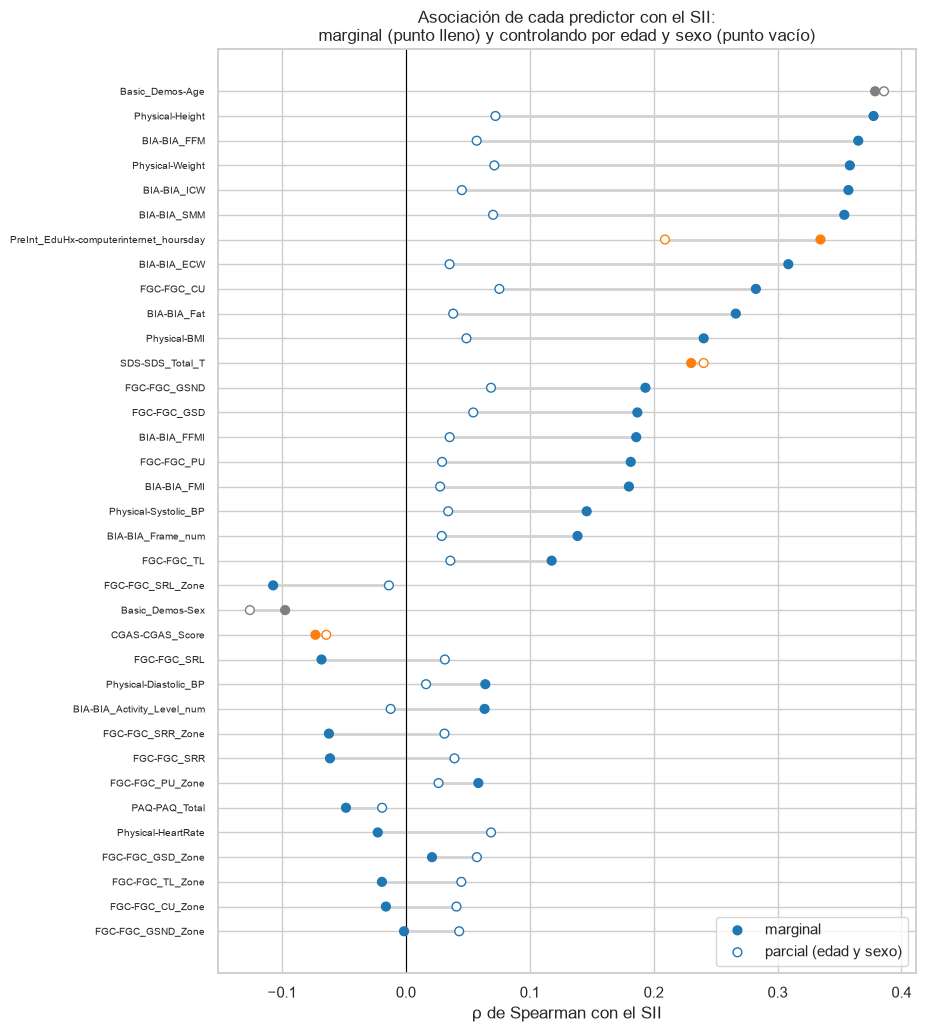

In [67]:
orden_figura = asociacion_sii.sort_values("ρ de Spearman", key=abs).index
posiciones = np.arange(len(orden_figura))
colores_grupo = {"físico": "tab:blue", "complementario": "tab:orange", "demográfico": "tab:gray"}

fig, ax = plt.subplots(figsize=(9, 12))
ax.hlines(
    posiciones,
    asociacion_sii.loc[orden_figura, "ρ parcial (edad y sexo)"],
    asociacion_sii.loc[orden_figura, "ρ de Spearman"],
    color="lightgray",
    linewidth=2,
)
ax.scatter(
    asociacion_sii.loc[orden_figura, "ρ de Spearman"],
    posiciones,
    color=[colores_grupo[g] for g in asociacion_sii.loc[orden_figura, "grupo"]],
    s=40,
    label="marginal",
    zorder=3,
)
ax.scatter(
    asociacion_sii.loc[orden_figura, "ρ parcial (edad y sexo)"],
    posiciones,
    facecolors="white",
    edgecolors=[colores_grupo[g] for g in asociacion_sii.loc[orden_figura, "grupo"]],
    s=40,
    label="parcial (edad y sexo)",
    zorder=3,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(posiciones)
ax.set_yticklabels(orden_figura, fontsize=7)
ax.set(
    xlabel="ρ de Spearman con el SII",
    title="Asociación de cada predictor con el SII:\nmarginal (punto lleno) y controlando por edad y sexo (punto vacío)",
)
ax.legend(loc="lower right")
save_figure(fig, "asociacion_sii_marginal_parcial", FIGURAS_EDA)
plt.show()

In [68]:
MIN_ESTRATO = 30

filas = []
for variable in asociacion_sii.index.drop("Basic_Demos-Age"):
    fila = {"variable": variable, "grupo": grupo_predictor[variable]}
    for grupo in GRUPOS_EDAD:
        mascara = grupo_edad == grupo
        datos = pd.concat(
            [analisis.loc[mascara, variable], sii_numerico[mascara]], axis="columns"
        ).dropna()
        suficiente = len(datos) >= MIN_ESTRATO and datos[variable].nunique() > 1
        fila[f"τ ({grupo})"] = (
            kendalltau(datos[variable], datos["sii"])[0] if suficiente else np.nan
        )
        fila[f"participantes ({grupo})"] = len(datos)
    filas.append(fila)

asociacion_por_edad = pd.DataFrame(filas).set_index("variable")
asociacion_por_edad.insert(
    1, "τ (todas las edades)", asociacion_sii.loc[asociacion_por_edad.index, "τ de Kendall"]
)
asociacion_por_edad.round(3)

,grupo,τ (todas las edades),τ (5–12),participantes (5–12),τ (13–17),participantes (13–17),τ (18–22),participantes (18–22)
variable,,,,,,,,
PreInt_EduHx-computerinternet_hoursday,complementario,0.301,0.259,2021,0.160,557,0.238,76
Physical-Height,físico,0.299,0.236,1911,0.048,545,-0.097,74
BIA-BIA_FFM,físico,0.288,0.207,1318,0.134,300,NaN,29
Physical-Weight,físico,0.282,0.215,1907,0.056,539,-0.033,74
BIA-BIA_ICW,físico,0.282,0.203,1318,0.131,300,NaN,29
BIA-BIA_SMM,físico,0.279,0.198,1318,0.123,300,NaN,29
BIA-BIA_ECW,físico,0.243,0.139,1318,0.106,300,NaN,29
FGC-FGC_CU,físico,0.227,0.140,1463,0.089,437,NaN,19
BIA-BIA_Fat,físico,0.210,0.139,1318,0.036,300,NaN,29


In [69]:
MIN_POR_EDAD = 30

indices_por_edad = analisis.groupby("Basic_Demos-Age").groups

filas = []
for variable in asociacion_sii.index.drop("Basic_Demos-Age"):
    taus, pesos = [], []
    for indices in indices_por_edad.values():
        datos = pd.concat(
            [analisis.loc[indices, variable], sii_numerico.loc[indices]], axis="columns"
        ).dropna()
        if len(datos) < MIN_POR_EDAD or datos[variable].nunique() < 2 or datos["sii"].nunique() < 2:
            continue
        taus.append(kendalltau(datos[variable], datos["sii"])[0])
        pesos.append(len(datos))
    filas.append(
        {
            "variable": variable,
            "grupo": grupo_predictor[variable],
            "τ marginal": asociacion_sii.at[variable, "τ de Kendall"],
            "τ dentro de cada año de edad (promedio ponderado)": (
                np.average(taus, weights=pesos) if taus else np.nan
            ),
            "años de edad incluidos": len(taus),
            "participantes incluidos": int(sum(pesos)),
        }
    )

asociacion_por_anio = pd.DataFrame(filas).set_index("variable")
tau_dentro = asociacion_por_anio["τ dentro de cada año de edad (promedio ponderado)"]

print(f"Predictores con τ marginal de al menos 0,1 en valor absoluto: {(asociacion_por_anio['τ marginal'].abs() >= 0.1).sum()}")
print(f"Predictores con τ dentro de cada año de al menos 0,1 en valor absoluto: {(tau_dentro.abs() >= 0.1).sum()}")
asociacion_por_anio.round(3)

Predictores con τ marginal de al menos 0,1 en valor absoluto: 19
Predictores con τ dentro de cada año de al menos 0,1 en valor absoluto: 3


,grupo,τ marginal,τ dentro de cada año de edad (promedio ponderado),años de edad incluidos,participantes incluidos
variable,,,,,
PreInt_EduHx-computerinternet_hoursday,complementario,0.301,0.194,14,2623
Physical-Height,físico,0.299,0.056,14,2501
BIA-BIA_FFM,físico,0.288,0.056,13,1618
Physical-Weight,físico,0.282,0.061,14,2491
BIA-BIA_ICW,físico,0.282,0.080,13,1618
BIA-BIA_SMM,físico,0.279,0.067,13,1618
BIA-BIA_ECW,físico,0.243,-0.004,13,1618
FGC-FGC_CU,físico,0.227,0.042,13,1900
BIA-BIA_Fat,físico,0.210,0.034,13,1618


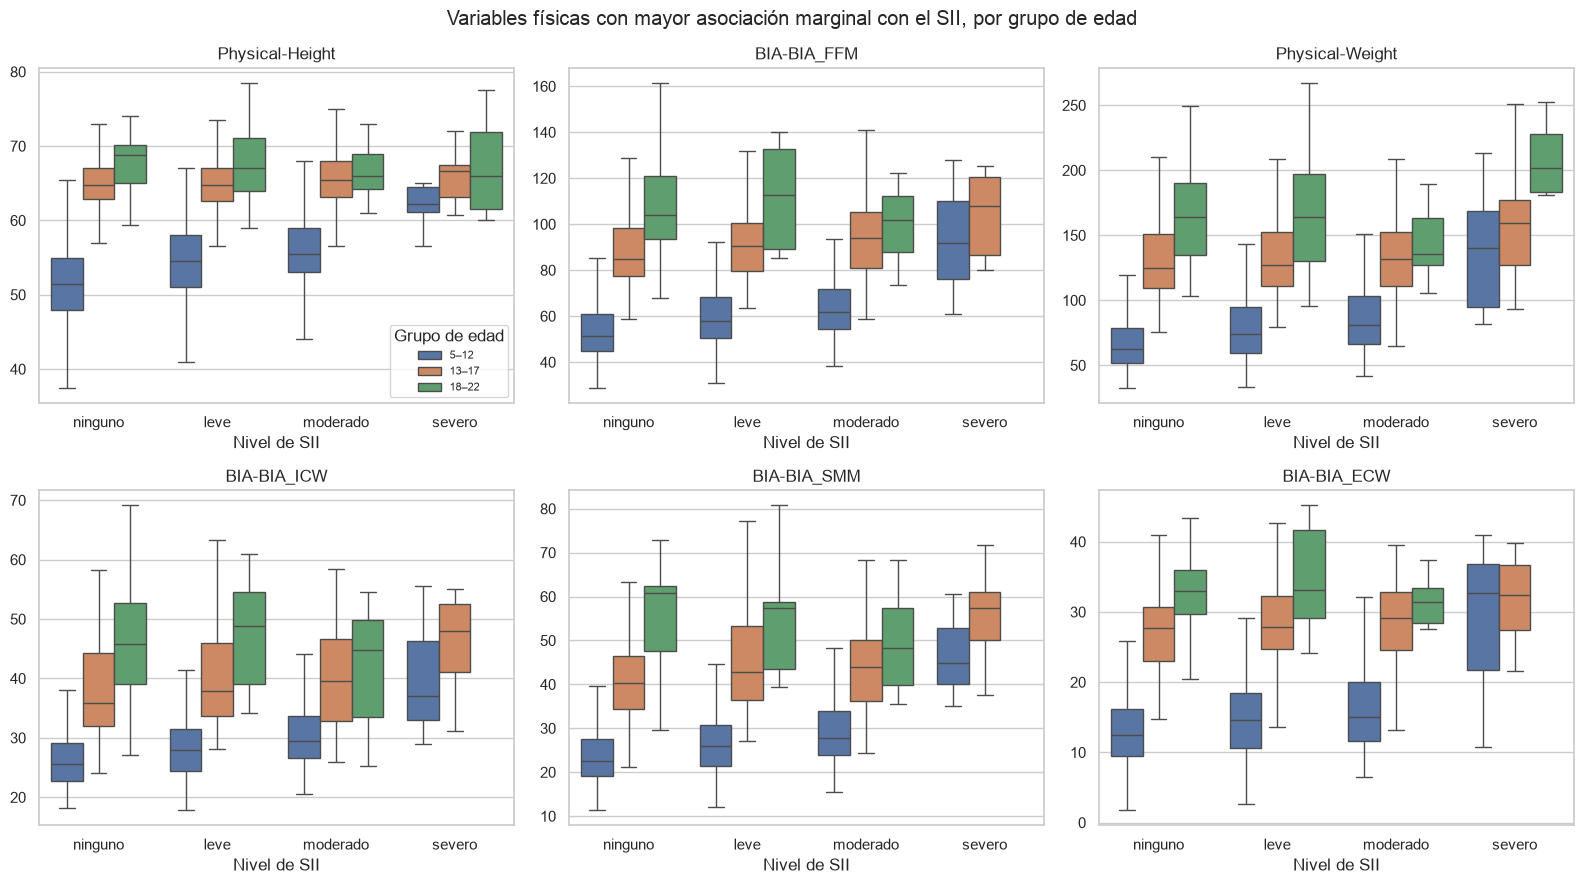

sii,ninguno,leve,moderado,severo
Basic_Demos-Age,,,,
5–12,1363,498,203,6
13–17,199,202,157,24
18–22,32,30,18,4


In [70]:
fisicas_numericas = asociacion_sii[
    (asociacion_sii["grupo"] == "físico") & (asociacion_sii["tipo"] == "numérica")
]
destacadas = list(fisicas_numericas["τ de Kendall"].abs().nlargest(6).index)

datos_grafico = analisis[destacadas].assign(
    **{"SII": sii_etiquetados, "grupo de edad": grupo_edad}
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for posicion, (ax, variable) in enumerate(zip(axes.flat, destacadas)):
    sns.boxplot(
        data=datos_grafico,
        x="SII",
        y=variable,
        hue="grupo de edad",
        order=list(NIVELES_SII.values()),
        showfliers=False,
        ax=ax,
    )
    ax.set(xlabel="Nivel de SII", ylabel="", title=variable)
    if posicion > 0:
        ax.get_legend().remove()
axes.flat[0].legend(title="Grupo de edad", fontsize=8)
fig.suptitle("Variables físicas con mayor asociación marginal con el SII, por grupo de edad")
fig.tight_layout()
save_figure(fig, "fisicas_por_sii_y_edad", FIGURAS_EDA)
plt.show()

pd.crosstab(grupo_edad, sii_etiquetados).reindex(columns=list(NIVELES_SII.values()))

In [71]:
tabla_temporada = pd.crosstab(analisis["Basic_Demos-Enroll_Season"], sii_etiquetados).reindex(
    columns=list(NIVELES_SII.values())
)
chi2, valor_p_temporada, grados_libertad, _ = chi2_contingency(tabla_temporada)
v_cramer = np.sqrt(chi2 / (tabla_temporada.to_numpy().sum() * (min(tabla_temporada.shape) - 1)))

display(
    (100 * tabla_temporada.div(tabla_temporada.sum(axis="columns"), axis="index"))
    .round(1)
    .assign(participantes=tabla_temporada.sum(axis="columns"))
    .rename_axis(index="temporada de inscripción", columns="SII (%)")
)

pd.Series(
    {
        "chi cuadrado": round(chi2, 2),
        "grados de libertad": grados_libertad,
        "valor p": round(valor_p_temporada, 4),
        "V de Cramér": round(v_cramer, 3),
    },
    name="temporada de inscripción frente al SII",
)

SII (%),ninguno,leve,moderado,severo,participantes
temporada de inscripción,,,,,
Fall,59.2,24.6,14.5,1.8,676
Spring,60.2,27.4,11.4,1.0,734
Summer,58.0,26.5,14.3,1.2,650
Winter,55.5,28.3,15.2,1.0,676


chi cuadrado          9.990
grados de libertad    9.000
valor p               0.351
V de Cramér           0.035
Name: temporada de inscripción frente al SII, dtype: float64

### Conclusión

#### Asociación marginal

De los 35 predictores evaluados, 30 tienen una asociación de Kendall con el SII que se mantiene significativa tras el ajuste por comparaciones múltiples, y 26 superan la prueba de permutación de la información mutua. Las asociaciones son, sin embargo, débiles a moderadas: el τ máximo es 0,31 (edad), y la variable con mayor información mutua reduce apenas el 7,9 % de la incertidumbre sobre el SII. Las variables con mayor asociación marginal son:

| Variable | Grupo | τ de Kendall | Información mutua neta (% de la entropía del SII) |
|---|---|---|---|
| Edad | Demográfico | 0,31 | 7,9 |
| Horas de uso de computador e internet | Complementario | 0,30 | 6,1 |
| Estatura | Físico | 0,30 | 7,8 |
| Masa libre de grasa | Físico | 0,29 | 7,6 |
| Peso | Físico | 0,28 | 7,1 |
| Agua intracelular | Físico | 0,28 | 7,0 |
| Masa muscular esquelética | Físico | 0,28 | 7,3 |
| Abdominales | Físico | 0,23 | 4,3 |
| Porcentaje de grasa corporal | Físico | 0,21 | 3,6 |
| SDS (puntaje T) | Complementario | 0,18 | 2,8 |

La información mutua ordena las variables casi igual que Kendall, por lo que no se observan asociaciones no monótonas relevantes. Las zonas de FitnessGram, la frecuencia cardiaca, la presión diastólica, el nivel de actividad de la bioimpedancia y la actividad física autorreportada (PAQ) tienen asociaciones marginales prácticamente nulas (τ de 0,06 o menos en valor absoluto, salvo la zona de flexibilidad izquierda, con −0,10).

#### Efecto de la edad y el sexo

La asociación de las variables físicas con el SII desaparece casi por completo al controlar por la edad y el sexo. Los dos procedimientos de control, la correlación parcial y el τ calculado dentro de cada año de edad, coinciden:

| Grupo | Variable | ρ de Spearman marginal | ρ parcial (edad y sexo) | τ marginal | τ dentro de cada año de edad |
|---|---|---|---|---|---|
| Físico | Estatura | 0,38 | 0,07 | 0,30 | 0,06 |
| Físico | Masa libre de grasa | 0,37 | 0,06 | 0,29 | 0,06 |
| Físico | Peso | 0,36 | 0,07 | 0,28 | 0,06 |
| Físico | Abdominales | 0,28 | 0,08 | 0,23 | 0,04 |
| Físico | IMC | 0,24 | 0,05 | 0,19 | 0,04 |
| Complementario | Horas de internet | 0,34 | 0,21 | 0,30 | 0,19 |
| Complementario | SDS (puntaje T) | 0,23 | 0,24 | 0,18 | 0,19 |
| Complementario | CGAS | −0,07 | −0,06 | −0,06 | −0,06 |
| Demográfico | Sexo | −0,10 | −0,13 | −0,09 | −0,12 |

- **Grupo físico:** ninguna variable física supera 0,08 en valor absoluto en la correlación parcial ni en el τ dentro de cada año de edad. De los 19 predictores con un τ marginal de al menos 0,1 en valor absoluto, solo 3 conservan ese nivel dentro de cada año de edad, y ninguno es físico. La asociación marginal de las variables físicas refleja, por tanto, que tanto ellas como el SII aumentan con la edad, como se anticipaba en la sección 7. Este resultado coincide con el antecedente de la misma población, en el que la actividad física y el IMC no se asociaron con el PIU una vez ajustados los factores de confusión.
- **Grupo complementario:** las horas de uso de internet y el SDS conservan una asociación de alrededor de 0,2 después del control; la asociación del SDS incluso aumenta ligeramente. Su relación con el SII no depende de la edad.
- **Grupo demográfico:** la asociación del sexo se fortalece ligeramente al controlar por la edad (de −0,09 a −0,12 en τ): los hombres presentan niveles de SII más altos dentro de una misma edad.

El control por grupos de edad amplios no basta para eliminar el efecto de la edad. Dentro del grupo de 5 a 12 años, la estatura mantiene un τ de 0,24, porque ese grupo abarca ocho años de crecimiento en los que la estatura y el SII siguen aumentando juntos; dentro de cada año de edad, el τ baja a 0,06. La figura de distribuciones por nivel de SII y grupo de edad muestra el mismo patrón: las diferencias entre grupos de edad son mucho mayores que las diferencias entre niveles de SII dentro de un mismo grupo. En el nivel severo, las cajas se basan en pocos participantes (6, 24 y 4 en cada grupo de edad), por lo que no permiten conclusiones.

#### Temporada de inscripción

La distribución del SII es similar en las cuatro temporadas de inscripción (V de Cramér de 0,035; p = 0,35), por lo que la temporada no se asocia con la severidad.

#### Implicaciones para los experimentos

Estos resultados son descriptivos y no se usan para seleccionar variables: los tres conjuntos conservan todas las variables definidas en las secciones anteriores. Sí permiten formular las hipótesis que ponen a prueba el modelo de referencia y los experimentos iniciales:

| Hipótesis | Fundamento |
|---|---|
| El modelo de referencia, con edad, sexo y temporada de inscripción, alcanza un QWK mayor que cero | La edad y el sexo se asocian con el SII, también al controlar uno por el otro |
| El conjunto principal mejora poco o nada el QWK frente al modelo de referencia | La asociación de las variables físicas con el SII se explica casi por completo por la edad y el sexo; una mejora solo podría provenir de combinaciones o interacciones entre variables que el análisis marginal no capta |
| El conjunto complementario mejora el QWK frente al conjunto principal | Las horas de uso de internet y el SDS conservan su asociación con el SII después de controlar por la edad y el sexo |

Estos resultados también condicionan la interpretación de los modelos. Si una variable física aparece entre las más importantes según los valores SHAP, su contribución puede reflejar la edad del participante más que una relación propia con el PIU, por lo que el análisis de interpretabilidad debe considerar la edad como posible variable de confusión.

## 9. Series de actigrafía

Además de los datos tabulares, la competencia incluye series de actigrafía, registradas con un acelerómetro de pulsera, para un subconjunto de los participantes. Según la formulación del proyecto, su incorporación se decide en esta etapa según su cobertura. Esta sección examina:

- cuántos participantes etiquetados tienen una serie y si difieren de los demás en edad, sexo, nivel de SII y cobertura de los otros instrumentos;
- la duración y la calidad de las series: días registrados, tiempo de uso de la pulsera e intervalo entre la actigrafía y la aplicación del PCIAT;
- qué participantes tienen una serie utilizable, con el criterio habitual en estudios de acelerometría de al menos cuatro días con diez o más horas de uso;
- la asociación descriptiva de algunas variables resumen de la actividad con el SII, con el mismo control por edad y sexo de la sección anterior.

Las series no se analizan registro por registro. Cada serie se resume en variables por participante: la intensidad media del movimiento durante el uso, medida con la norma euclidiana del vector de aceleración menos uno (ENMO), la intensidad nocturna, el tiempo de uso y la longitud del registro. Los resúmenes se calculan con el paquete del proyecto, de modo que el cuaderno de modelado pueda reutilizarlos si la actigrafía se incorpora.

In [72]:
ids_actigrafia = list_actigraphy_ids()

columnas_ejemplo = load_actigraphy(ids_actigrafia[0]).dtypes.rename("tipo").to_frame()
columnas_ejemplo.index.name = "columna"
display(columnas_ejemplo)

con_serie = etiquetados_df["id"].isin(ids_actigrafia)

pd.Series(
    {
        "participantes con serie": len(ids_actigrafia),
        "de ellos, en el conjunto de entrenamiento": int(train["id"].isin(ids_actigrafia).sum()),
        "de ellos, con SII": int(con_serie.sum()),
        "% de los etiquetados con serie": round(100 * con_serie.mean(), 1),
    },
    name="conteo",
)

,tipo
columna,
step,uint32
X,float32
Y,float32
Z,float32
enmo,float32
anglez,float32
non-wear_flag,float32
light,float32
battery_voltage,float32


participantes con serie                      996.0
de ellos, en el conjunto de entrenamiento    996.0
de ellos, con SII                            996.0
% de los etiquetados con serie                36.4
Name: conteo, dtype: float64

In [73]:
def perfil(mascara: pd.Series) -> pd.Series:
    """Resume la edad, el sexo y la distribución del SII de un subconjunto de etiquetados."""
    subconjunto = etiquetados_df[mascara]
    distribucion = (
        100
        * subconjunto["sii"].astype(int).map(NIVELES_SII).value_counts(normalize=True)
    ).reindex(list(NIVELES_SII.values()), fill_value=0)
    return pd.concat(
        [
            pd.Series(
                {
                    "participantes": len(subconjunto),
                    "edad media": subconjunto["Basic_Demos-Age"].mean(),
                    "% mujeres": 100 * subconjunto["Basic_Demos-Sex"].mean(),
                    "casos severos": int((subconjunto["sii"] == 3).sum()),
                }
            ),
            distribucion.add_prefix("% SII "),
        ]
    )


display(
    pd.DataFrame({"con serie": perfil(con_serie), "sin serie": perfil(~con_serie)}).round(1)
)

display(
    (100 * presencia[instrumentos_patron].groupby(con_serie.rename("serie")).mean())
    .T.rename(columns={True: "% con serie", False: "% sin serie"})
    .rename_axis("instrumento")
    .round(1)
)
(100 * pd.crosstab(grupo_edad, con_serie.rename("serie"), normalize="index")).rename(
    columns={True: "% con serie", False: "% sin serie"}
).round(1).assign(participantes=grupo_edad.value_counts()).rename_axis(
    index="grupo de edad", columns=None
)

,con serie,sin serie
participantes,996.0,1740.0
edad media,10.3,10.2
% mujeres,34.6,37.5
casos severos,10.0,24.0
% SII ninguno,58.5,58.1
% SII leve,26.7,26.7
% SII moderado,13.8,13.9
% SII severo,1.0,1.4


serie,% sin serie,% con serie
instrumento,,
Medidas físicas,91.2,99.5
FitnessGram,70.2,70.2
Resistencia,24.8,30.0
Bioimpedancia,61.8,74.0
PAQ-A o PAQ-C,64.9,67.6
SDS,93.7,90.0
CGAS,79.8,95.8
Horas de internet,95.9,98.9


,% sin serie,% con serie,participantes
grupo de edad,,,
5–12,63.7,36.3,2070
13–17,63.7,36.3,582
18–22,59.5,40.5,84


In [74]:
RUTA_RESUMEN_ACTIGRAFIA = INTERIM_DATA_DIR / "actigrafia_resumen.parquet"

NOMBRES_ACTIGRAFIA = {
    "sampling_interval_s": "intervalo de muestreo (s)",
    "recorded_days": "días registrados",
    "recorded_hours": "horas registradas",
    "nonwear_fraction": "proporción sin uso",
    "valid_days": f"días con al menos {MIN_WEAR_HOURS_PER_DAY} h de uso",
    "wear_hours_per_day": "horas de uso por día",
    "enmo_wear_mean": "ENMO medio en uso",
    "enmo_day_wear_mean": "ENMO diurno en uso (8:00 a 21:00)",
    "enmo_night_wear_mean": "ENMO nocturno en uso (0:00 a 6:00)",
    "median_days_from_pciat": "días entre la actigrafía y el PCIAT (mediana)",
}

ids_etiquetados_con_serie = sorted(set(etiquetados_df.loc[con_serie, "id"]))


def resumen_guardado_vigente(ruta, ids_esperados, columnas_esperadas) -> bool:
    """Indica si el resumen guardado tiene los participantes y las columnas esperadas."""
    if not ruta.is_file():
        return False
    guardado = pd.read_parquet(ruta)
    return set(guardado.index) == set(ids_esperados) and set(columnas_esperadas) <= set(
        guardado.columns
    )


if resumen_guardado_vigente(RUTA_RESUMEN_ACTIGRAFIA, ids_etiquetados_con_serie, NOMBRES_ACTIGRAFIA):
    resumen_actigrafia = pd.read_parquet(RUTA_RESUMEN_ACTIGRAFIA)
else:
    resumen_actigrafia = pd.DataFrame(
        [
            {"id": participante, **summarize_actigraphy(load_actigraphy(participante, ACTIGRAPHY_COLUMNS))}
            for participante in ids_etiquetados_con_serie
        ]
    ).set_index("id")
    INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
    resumen_actigrafia.to_parquet(RUTA_RESUMEN_ACTIGRAFIA)

faltantes_en_resumen = set(NOMBRES_ACTIGRAFIA) - set(resumen_actigrafia.columns)
assert not faltantes_en_resumen, (
    f"El resumen no tiene las columnas {sorted(faltantes_en_resumen)}; "
    "reinicia el kernel para cargar la versión actual de summarize_actigraphy."
)

print(f"Series resumidas: {len(resumen_actigrafia)} de {len(ids_etiquetados_con_serie)}")
resumen_actigrafia.rename(columns=NOMBRES_ACTIGRAFIA).describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).T.round(3)

Series resumidas: 996 de 996


,count,mean,std,min,5%,25%,50%,75%,95%,max
intervalo de muestreo (s),996.0,5.000,0.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
días registrados,996.0,26.806,9.392,1.000,15.000,23.000,24.000,29.250,43.000,81.000
horas registradas,996.0,438.656,184.738,1.288,33.364,352.212,532.700,559.162,588.096,1050.294
proporción sin uso,996.0,0.230,0.306,0.000,0.000,0.000,0.056,0.407,0.874,0.989
días con al menos 10 h de uso,996.0,15.133,9.460,0.000,0.000,6.000,18.000,22.000,29.000,41.000
horas de uso por día,996.0,12.507,7.417,0.052,1.158,5.905,12.485,20.027,22.624,23.444
ENMO medio en uso,996.0,0.044,0.022,0.000,0.011,0.028,0.040,0.056,0.086,0.157
ENMO diurno en uso (8:00 a 21:00),996.0,0.055,0.027,0.000,0.013,0.036,0.055,0.073,0.101,0.176
ENMO nocturno en uso (0:00 a 6:00),958.0,0.012,0.010,0.000,0.003,0.005,0.008,0.017,0.033,0.070
días entre la actigrafía y el PCIAT (mediana),996.0,65.013,84.283,0.000,10.000,18.000,34.000,72.250,260.250,736.000


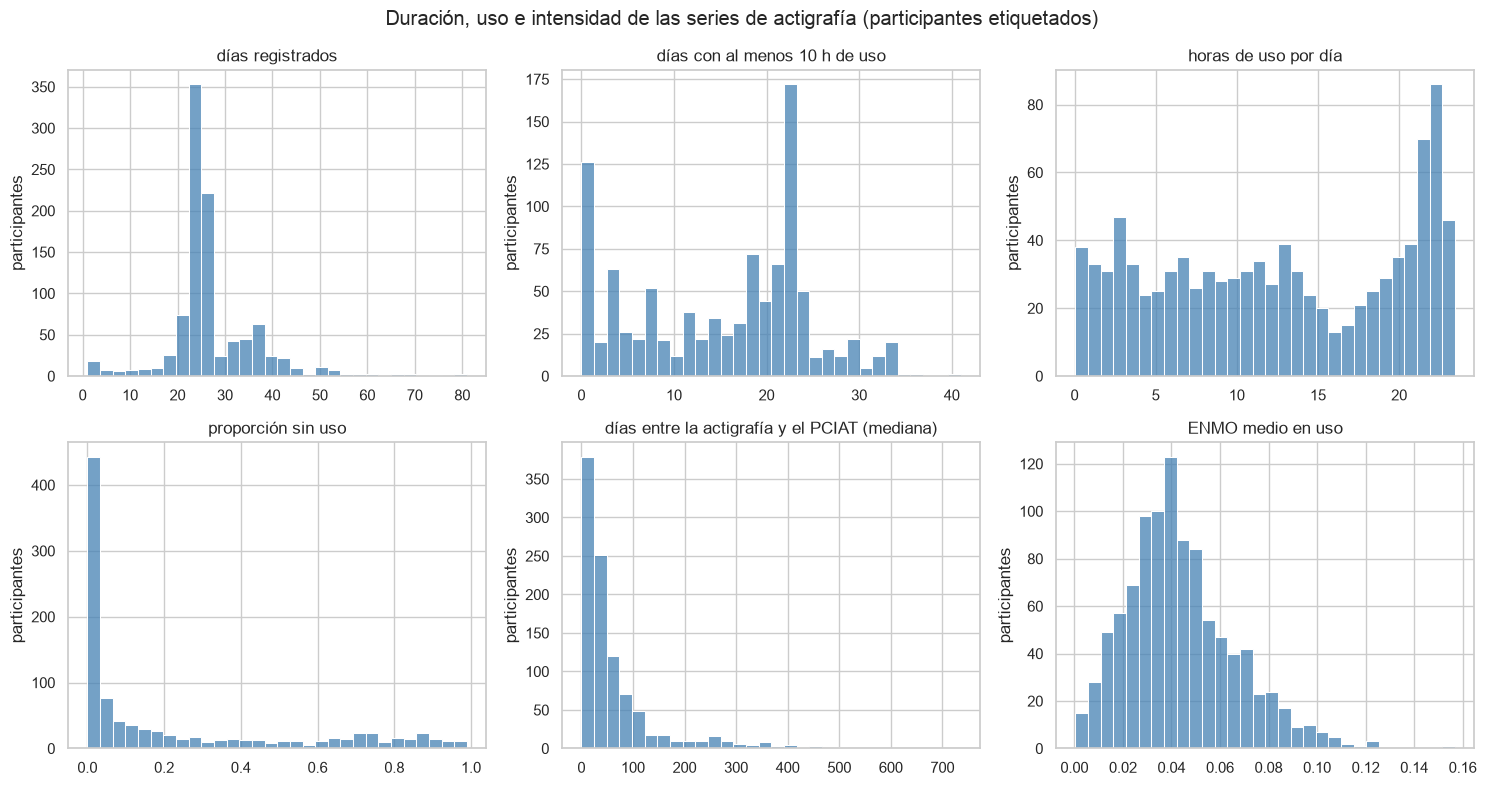

In [75]:
variables_calidad = [
    "recorded_days",
    "valid_days",
    "wear_hours_per_day",
    "nonwear_fraction",
    "median_days_from_pciat",
    "enmo_wear_mean",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, variable in zip(axes.flat, variables_calidad):
    sns.histplot(resumen_actigrafia[variable].dropna(), bins=30, color="steelblue", ax=ax)
    ax.set(xlabel="", ylabel="participantes", title=NOMBRES_ACTIGRAFIA[variable])
fig.suptitle("Duración, uso e intensidad de las series de actigrafía (participantes etiquetados)")
fig.tight_layout()
save_figure(fig, "actigrafia_calidad", FIGURAS_EDA)
plt.show()

In [76]:
MIN_DIAS_VALIDOS = 4

utilizable_por_id = resumen_actigrafia["valid_days"] >= MIN_DIAS_VALIDOS
serie_utilizable = etiquetados_df["id"].map(utilizable_por_id).fillna(False).astype(bool)

display(
    pd.Series(
        {
            "etiquetados con serie": int(con_serie.sum()),
            f"con al menos {MIN_DIAS_VALIDOS} días de {MIN_WEAR_HOURS_PER_DAY} h o más de uso": int(
                serie_utilizable.sum()
            ),
            "% de los etiquetados con serie utilizable": round(100 * serie_utilizable.mean(), 1),
        },
        name="conteo",
    )
)

pd.DataFrame(
    {
        "etiquetados": sii_etiquetados.value_counts(),
        "con serie": sii_etiquetados[con_serie].value_counts(),
        "con serie utilizable": sii_etiquetados[serie_utilizable].value_counts(),
    }
).reindex(list(NIVELES_SII.values())).fillna(0).astype(int).assign(
    **{
        "% con serie utilizable": lambda d: (100 * d["con serie utilizable"] / d["etiquetados"]).round(1)
    }
).rename_axis("SII")

etiquetados con serie                        996.0
con al menos 4 días de 10 h o más de uso     823.0
% de los etiquetados con serie utilizable     30.1
Name: conteo, dtype: float64

,etiquetados,con serie,con serie utilizable,% con serie utilizable
SII,,,,
ninguno,1594,583,491,30.8
leve,730,266,221,30.3
moderado,378,137,105,27.8
severo,34,10,6,17.6


In [77]:
variables_actividad = [
    "enmo_wear_mean",
    "enmo_night_wear_mean",
    "wear_hours_per_day",
    "nonwear_fraction",
]

actigrafia_etiquetados = resumen_actigrafia[utilizable_por_id].join(
    etiquetados_df.set_index("id")[["sii", "Basic_Demos-Age", "Basic_Demos-Sex"]]
)
actigrafia_etiquetados["sii"] = actigrafia_etiquetados["sii"].astype(int)

filas = []
for variable in variables_actividad:
    datos = actigrafia_etiquetados[[variable, "sii"]].dropna()
    tau, valor_p = kendalltau(datos[variable], datos["sii"])
    filas.append(
        {
            "variable": NOMBRES_ACTIGRAFIA[variable],
            "participantes": len(datos),
            "τ de Kendall": tau,
            "valor p": valor_p,
            "ρ de Spearman": datos[variable].corr(datos["sii"], method="spearman"),
            "ρ parcial (edad y sexo)": spearman_parcial(
                actigrafia_etiquetados[variable],
                actigrafia_etiquetados["sii"],
                actigrafia_etiquetados[CONTROLES],
            ),
            "ρ con la edad": actigrafia_etiquetados[variable].corr(
                actigrafia_etiquetados["Basic_Demos-Age"], method="spearman"
            ),
        }
    )

asociacion_actigrafia = pd.DataFrame(filas).set_index("variable")
asociacion_actigrafia["valor p ajustado"] = false_discovery_control(asociacion_actigrafia["valor p"])
tabla_actigrafia = asociacion_actigrafia.drop(columns=["valor p", "valor p ajustado"]).round(3)
tabla_actigrafia["valor p ajustado"] = asociacion_actigrafia["valor p ajustado"].map("{:.2e}".format)
tabla_actigrafia

,participantes,τ de Kendall,ρ de Spearman,ρ parcial (edad y sexo),ρ con la edad,valor p ajustado
variable,,,,,,
ENMO medio en uso,823,-0.223,-0.283,-0.153,-0.481,1.39e-15
ENMO nocturno en uso (0:00 a 6:00),812,-0.021,-0.026,-0.024,-0.011,4.50e-01
horas de uso por día,823,-0.025,-0.032,-0.047,0.024,4.50e-01
proporción sin uso,823,0.094,0.115,0.087,0.100,1.77e-03


In [78]:
variables_intensidad = ["enmo_wear_mean", "enmo_day_wear_mean", "enmo_night_wear_mean"]
controles_con_uso = [*CONTROLES, "wear_hours_per_day"]

filas = []
for variable in variables_intensidad:
    taus, pesos = [], []
    for _, grupo_anio in actigrafia_etiquetados.groupby("Basic_Demos-Age"):
        datos = grupo_anio[[variable, "sii"]].dropna()
        if len(datos) < MIN_POR_EDAD or datos[variable].nunique() < 2 or datos["sii"].nunique() < 2:
            continue
        taus.append(kendalltau(datos[variable], datos["sii"])[0])
        pesos.append(len(datos))
    filas.append(
        {
            "variable": NOMBRES_ACTIGRAFIA[variable],
            "ρ de Spearman": actigrafia_etiquetados[variable].corr(
                actigrafia_etiquetados["sii"], method="spearman"
            ),
            "ρ parcial (edad y sexo)": spearman_parcial(
                actigrafia_etiquetados[variable],
                actigrafia_etiquetados["sii"],
                actigrafia_etiquetados[CONTROLES],
            ),
            "ρ parcial (edad, sexo y horas de uso)": spearman_parcial(
                actigrafia_etiquetados[variable],
                actigrafia_etiquetados["sii"],
                actigrafia_etiquetados[controles_con_uso],
            ),
            "ρ con las horas de uso": actigrafia_etiquetados[variable].corr(
                actigrafia_etiquetados["wear_hours_per_day"], method="spearman"
            ),
            "τ dentro de cada año de edad": np.average(taus, weights=pesos) if taus else np.nan,
            "años de edad incluidos": len(taus),
        }
    )

pd.DataFrame(filas).set_index("variable").round(3)

,ρ de Spearman,ρ parcial (edad y sexo),"ρ parcial (edad, sexo y horas de uso)",ρ con las horas de uso,τ dentro de cada año de edad,años de edad incluidos
variable,,,,,,
ENMO medio en uso,-0.283,-0.153,-0.164,-0.158,-0.100,10
ENMO diurno en uso (8:00 a 21:00),-0.310,-0.173,-0.169,0.085,-0.119,10
ENMO nocturno en uso (0:00 a 6:00),-0.026,-0.024,-0.043,-0.334,-0.008,10


### Conclusión

#### Cobertura

De los 2.736 participantes etiquetados, 996 (36,4 %) tienen una serie de actigrafía. Su perfil es prácticamente igual al de los demás: edad media de 10,3 frente a 10,2 años, 34,6 % frente a 37,5 % de mujeres y la misma distribución del SII. La proporción con serie es similar en los tres grupos de edad (entre 36,3 % y 40,5 %), y los participantes con serie tienen una cobertura igual o mayor de los demás instrumentos. La disponibilidad de la actigrafía no introduce, por tanto, un sesgo de selección evidente.

#### Duración y calidad de las series

| Característica | Mediana | Percentil 5 | Percentil 95 |
|---|---|---|---|
| Días registrados | 24 | 15 | 43 |
| Días con al menos 10 h de uso | 18 | 0 | 29 |
| Horas de uso por día | 12,5 | 1,2 | 22,6 |
| Proporción del tiempo sin uso | 0,06 | 0,00 | 0,87 |
| Días entre la actigrafía y el PCIAT | 34 | 10 | 260 |

Todas las series tienen un registro cada 5 segundos. El uso de la pulsera es muy desigual: la distribución de las horas de uso por día es bimodal, con un grupo que la usa casi las 24 horas y otro que la usa pocas horas, y 126 participantes no tienen ningún día con 10 horas de uso. Con el criterio de al menos cuatro días con diez o más horas de uso, quedan 823 series utilizables, que corresponden al 30,1 % de los participantes etiquetados:

| SII | Etiquetados | Con serie | Con serie utilizable | % con serie utilizable |
|---|---|---|---|---|
| Ninguno | 1.594 | 583 | 491 | 30,8 |
| Leve | 730 | 266 | 221 | 30,3 |
| Moderado | 378 | 137 | 105 | 27,8 |
| Severo | 34 | 10 | 6 | 17,6 |

Solo 6 de los 34 casos severos tienen una serie utilizable. Además, la actigrafía no se registró al mismo tiempo que el PCIAT: la distancia mediana es de 34 días, y en el 5 % de los participantes supera los 260 días, de modo que la actividad medida no siempre corresponde al momento en que se evaluó el SII.

#### Asociación descriptiva con el SII

| Variable | ρ de Spearman | ρ parcial (edad y sexo) | ρ parcial (edad, sexo y horas de uso) | τ dentro de cada año de edad |
|---|---|---|---|---|
| ENMO diurno en uso (8:00 a 21:00) | −0,31 | −0,17 | −0,17 | −0,12 |
| ENMO medio en uso | −0,28 | −0,15 | −0,16 | −0,10 |
| ENMO nocturno en uso (0:00 a 6:00) | −0,03 | −0,02 | −0,04 | −0,01 |
| Horas de uso por día | −0,03 | −0,05 | — | — |

La intensidad del movimiento durante el día se asocia negativamente con el SII: los participantes con mayor severidad se mueven menos. A diferencia de las variables físicas tabulares de la sección 8, cuya asociación desaparecía al controlar por la edad (como máximo 0,08 en valor absoluto), esta asociación se mantiene con los tres controles. Tampoco se explica por el hábito de uso de la pulsera: el ENMO diurno apenas se correlaciona con las horas de uso (0,085), y su correlación parcial no cambia al controlar también por ellas. El movimiento nocturno y las horas de uso no se asocian con el SII.

La actigrafía es, por tanto, la única medida física cuya relación con el SII no se explica por la edad. Contrasta con la actividad física autorreportada del PAQ, que no mostró asociación en la sección 8, y es coherente con la premisa de la competencia de que el uso excesivo de tecnología se acompaña de menor actividad física.

#### Decisiones

Las variables de actigrafía que se incorporan se eligen con criterios de medición, no según su asociación con el SII, para no introducir una selección basada en la variable objetivo:

| Decisión | Motivo |
|---|---|
| Incorporar la actigrafía al grupo físico, como un instrumento más | Es la medida objetiva de la actividad física, que es el objeto de la pregunta de investigación, y su cobertura (30,1 %) es comparable a la de otros instrumentos que se conservan, como la fuerza de agarre |
| Tratar como faltante la actigrafía de los participantes sin serie utilizable | Con menos de cuatro días de diez horas de uso, los resúmenes no representan la actividad habitual |
| Incorporar el ENMO diurno en uso | Compara la intensidad del movimiento de todos los participantes en las mismas horas, sin depender de cuándo usan la pulsera |
| Incorporar el ENMO nocturno en uso | Describe el movimiento durante el sueño, un aspecto distinto de la actividad diurna |
| Incorporar las horas de uso por día | Describen el cumplimiento del protocolo y permiten al modelo distinguir los patrones de uso |
| No incorporar el ENMO medio en uso | Mezcla horas de actividad y de sueño en proporciones que dependen de cuándo se usa la pulsera |
| No incorporar los días registrados ni la distancia al PCIAT | Describen el registro, no al participante |
| Usar un indicador de ausencia para la actigrafía | Igual que en los demás instrumentos, la ausencia se presenta en bloque |

Las tres variables se calculan con el paquete del proyecto a partir de las series, de modo que el cuaderno de modelado obtiene exactamente los mismos resúmenes. Con esta incorporación, el grupo físico pasa de 30 a 33 variables, el conjunto principal de 33 a 36 columnas y el complementario de 36 a 39.

Este resultado precisa la hipótesis sobre el conjunto principal formulada en la sección 8: si el conjunto principal mejora el desempeño frente al modelo de referencia, la mejora proviene probablemente de la actigrafía y no de las demás variables físicas, y se limitaría al 30 % de los participantes que tienen una serie utilizable.